# Forward simulation of synthetic TeV-halo populations with an HESS J1837−069 Naima benchmark (MCMC initialization fix)

This notebook generates an analysis-ready sample of energy-dependent TeV-halo count maps from broad, physically motivated priors.

The generative hierarchy is

$$
\theta_s \sim p(\theta), \qquad
\mu_{s,e,y,x}=\mu^{\rm halo}_{s,e,y,x}(\theta_s)+\mu^{\rm bkg}_{s,e,y,x}, \qquad
N_{s,e,y,x}\sim\mathrm{Poisson}(\mu_{s,e,y,x}).
$$

Here, the **physical parameters are continuous random variables** and therefore are not themselves drawn from a Poisson distribution. Poisson sampling is applied where it is physically appropriate: to photon/event counts in each energy and sky bin. An optional switch also allows the *number of systems* in a mock population to be drawn from a Poisson distribution.

## Model scope

The forward model is intentionally lightweight and instrument-agnostic. It captures:

- pulsar-age and spin-down evolution;
- energy-dependent inhibited diffusion;
- radiative cooling of TeV electrons;
- inverse-Compton mapping between electron and gamma-ray energies;
- a proper-motion trail built from a mixture of injection epochs;
- an energy-dependent Gaussian PSF;
- a smooth nuisance background;
- Poisson event-count realizations.

It is suitable for prototyping simulation-based inference, morphology classifiers, and data-pipeline tests. It is **not yet a replacement for a full transport solver plus CTA/SWGO/HAWC/Fermi-LAT IRFs**.

## Literature anchors

The prior ranges are deliberately broad and are anchored to the TeV-halo literature rather than presented as precise population posteriors. Useful references include:

1. Abeysekara et al. (2017), *Extended gamma-ray sources around pulsars constrain the origin of the positron flux at Earth*, Science 358, 911.
2. Di Mauro, Manconi & Donato (2019), *Evidences of low-diffusion bubbles around Galactic pulsars*, arXiv:1908.03216.
3. Zhang et al. (2021), *Morphology of Gamma-Ray Halos around Middle-aged Pulsars: Influence of the Pulsar Proper Motion*, ApJ 922, 130.
4. Martin et al. (2022), *Population synthesis of pulsar wind nebulae and pulsar halos in the Milky Way*, A&A 665, A132.
5. Fang (2022), *Gamma-ray pulsar halos in the Galaxy*, Frontiers in Astronomy and Space Sciences 9, 1022100.


This revision also contains a **HESS J1837−069 spectral benchmark**. It can
(1) read an existing Naima results-summary ECSV and rank the synthetic systems,
and (2) run new Naima inverse-Compton and pion-decay fits once a spectral-point
ECSV containing energy, flux, and uncertainty columns is supplied.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibility
MASTER_SEED = 20260724
rng = np.random.default_rng(MASTER_SEED)

# Output location, relative to the notebook working directory
OUTPUT_DIR = Path("tev_halo_synthetic_demo_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"NumPy version: {np.__version__}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


NumPy version: 2.1.3
Output directory: /project/ls-gruen/users/asu.uenver/tev_halo_synthetic_demo_output


## 1. Configuration

The defaults create a small demonstration sample quickly. Increase `N_SYSTEMS_FIXED`, `NPIX`, or the number of energy bins for production runs.

Two distinct Poisson uses are available:

1. `USE_POISSON_POPULATION_SIZE=True`: draw the number of halos as \(N_{\rm halo}\sim\mathrm{Poisson}(\Lambda_{\rm pop})\).
2. Count maps are always generated as \(N_{e,y,x}\sim\mathrm{Poisson}(\mu_{e,y,x})\).


In [ ]:
@dataclass(frozen=True)
class PriorConfig:
    # Middle-aged-pulsar regime, kyr
    age_kyr: Tuple[float, float] = (30.0, 400.0)

    # Distance, kpc. A truncated Gamma(shape=3) distribution approximates
    # a volume term times an exponential Galactic selection function.
    distance_kpc: Tuple[float, float] = (0.2, 8.0)
    distance_scale_kpc: float = 3.3

    # Current spin-down power, erg/s
    log10_edot: Tuple[float, float] = (33.0, 37.0)

    # Fraction of spin-down power placed into escaping e+/e-
    log10_efficiency: Tuple[float, float] = (np.log10(0.01), np.log10(0.30))

    # Diffusion coefficient at 100 TeV, cm^2/s
    log10_D100: Tuple[float, float] = (26.5, 28.5)
    diffusion_index: Tuple[float, float] = (0.25, 0.60)

    # Injection spectrum dN/dE ~ E^-p exp(-E/Ecut)
    injection_index: Tuple[float, float] = (1.8, 3.5)
    log10_cutoff_TeV: Tuple[float, float] = (np.log10(30.0), np.log10(300.0))

    # Initial spin-down timescale, kyr, for braking index n=3
    log10_tau0_kyr: Tuple[float, float] = (np.log10(0.5), np.log10(30.0))

    # One-dimensional natal-kick dispersion, km/s
    kick_sigma_kms: float = 265.0
    max_speed_kms: float = 1500.0

    # Energy density controlling radiative losses, eV/cm^3
    u_total_eV_cm3: Tuple[float, float] = (0.5, 2.0)

    # Smooth-background nuisance parameters
    background_scale: Tuple[float, float] = (0.5, 2.0)
    background_gradient: Tuple[float, float] = (-0.35, 0.35)



@dataclass(frozen=True)
class InstrumentConfig:
    # A generic TeV survey setup; replace with real IRFs later.
    energy_edges_TeV: Tuple[float, ...] = (0.3, 1.0, 3.0, 10.0, 30.0, 100.0)
    fov_deg: float = 12.0
    npix: int = 64

    # Approximate 68% containment radius at 1 TeV and energy scaling
    psf68_ref_deg: float = 0.35
    psf_energy_index: float = -0.35
    psf68_floor_deg: float = 0.06

    # Generic relative effective-area scaling
    aeff_energy_index: float = 0.50
    aeff_turnover_TeV: float = 50.0

    # Expected source counts for a Geminga-like reference source in this mock setup
    source_counts_reference: float = 5000.0
    reference_edot_erg_s: float = 3.2e34
    reference_distance_kpc: float = 0.25
    reference_efficiency: float = 0.10
    min_source_counts: float = 20.0
    max_source_counts: float = 100000.0

    # Total background expectation over the full cube before nuisance scaling
    background_counts_reference: float = 25000.0
    background_index: float = 2.70

    # Number of lookback-time slices in the proper-motion mixture
    n_time_slices: int = 48


PRIORS = PriorConfig()
INSTRUMENT = InstrumentConfig()

# Population-size controls
USE_POISSON_POPULATION_SIZE = False
POISSON_POPULATION_MEAN = 32.0
N_SYSTEMS_FIXED = 32

if USE_POISSON_POPULATION_SIZE:
    n_systems = max(1, int(rng.poisson(POISSON_POPULATION_MEAN)))
else:
    n_systems = N_SYSTEMS_FIXED

print(f"Generating {n_systems} synthetic systems")
print(asdict(PRIORS))
print(asdict(INSTRUMENT))


Generating 32 synthetic systems
{'age_kyr': (30.0, 500.0), 'distance_kpc': (0.2, 5.0), 'distance_scale_kpc': 1.3, 'log10_edot': (33.0, 36.0), 'log10_efficiency': (np.float64(-2.0), np.float64(-0.5228787452803376)), 'log10_D100': (26.5, 28.5), 'diffusion_index': (0.25, 0.6), 'injection_index': (1.5, 2.5), 'log10_cutoff_TeV': (np.float64(1.4771212547196624), np.float64(2.4771212547196626)), 'log10_tau0_kyr': (np.float64(-0.3010299956639812), np.float64(1.4771212547196624)), 'kick_sigma_kms': 265.0, 'max_speed_kms': 1500.0, 'u_total_eV_cm3': (0.5, 2.0), 'background_scale': (0.5, 2.0), 'background_gradient': (-0.35, 0.35)}
{'energy_edges_TeV': (0.3, 1.0, 3.0, 10.0, 30.0, 100.0), 'fov_deg': 12.0, 'npix': 64, 'psf68_ref_deg': 0.35, 'psf_energy_index': -0.35, 'psf68_floor_deg': 0.06, 'aeff_energy_index': 0.5, 'aeff_turnover_TeV': 50.0, 'source_counts_reference': 5000.0, 'reference_edot_erg_s': 3.2e+34, 'reference_distance_kpc': 0.25, 'reference_efficiency': 0.1, 'min_source_counts': 20.0, 'ma

## 2. Prior sampler

Important modeling choices:

- `age_kyr`, `edot`, `efficiency`, `D100`, `cutoff`, and `tau0` use logarithmic sampling where orders of magnitude are plausible.
- Distance is sampled from a truncated Gamma distribution with shape 3, corresponding schematically to a volume factor \(d^2\) and an exponential selection/scale term.
- Transverse velocities are obtained from two Gaussian components, producing a Rayleigh distribution in speed.
- Background normalization and gradients are nuisance parameters and should eventually be conditioned on survey location and IRFs.


In [4]:
def loguniform(rng: np.random.Generator, low: float, high: float, size=None):
    '''Sample a positive quantity uniformly in log10 space.'''
    return 10.0 ** rng.uniform(np.log10(low), np.log10(high), size=size)


def sample_truncated_distance(
    rng: np.random.Generator,
    n: int,
    dmin: float,
    dmax: float,
    scale: float,
) -> np.ndarray:
    '''Sample p(d) proportional to d^2 exp(-d/scale), truncated to [dmin, dmax].'''
    accepted = []
    while sum(len(x) for x in accepted) < n:
        draw = rng.gamma(shape=3.0, scale=scale, size=max(4 * n, 64))
        draw = draw[(draw >= dmin) & (draw <= dmax)]
        accepted.append(draw)
    return np.concatenate(accepted)[:n]


def sample_prior_table(
    rng: np.random.Generator,
    n: int,
    priors: PriorConfig,
) -> pd.DataFrame:
    distance = sample_truncated_distance(
        rng,
        n,
        priors.distance_kpc[0],
        priors.distance_kpc[1],
        priors.distance_scale_kpc,
    )

    vx = rng.normal(0.0, priors.kick_sigma_kms, size=n)
    vy = rng.normal(0.0, priors.kick_sigma_kms, size=n)
    speed = np.minimum(np.hypot(vx, vy), priors.max_speed_kms)
    phi = np.arctan2(vy, vx)

    table = pd.DataFrame({
        "system_id": np.arange(n, dtype=int),
        "age_kyr": loguniform(rng, *priors.age_kyr, size=n),
        "distance_kpc": distance,
        "edot_erg_s": 10.0 ** rng.uniform(*priors.log10_edot, size=n),
        "efficiency": 10.0 ** rng.uniform(*priors.log10_efficiency, size=n),
        "D100_cm2_s": 10.0 ** rng.uniform(*priors.log10_D100, size=n),
        "diffusion_index": rng.uniform(*priors.diffusion_index, size=n),
        "injection_index": rng.uniform(*priors.injection_index, size=n),
        "cutoff_TeV": 10.0 ** rng.uniform(*priors.log10_cutoff_TeV, size=n),
        "tau0_kyr": 10.0 ** rng.uniform(*priors.log10_tau0_kyr, size=n),
        "v_transverse_kms": speed,
        "motion_angle_rad": phi,
        "u_total_eV_cm3": rng.uniform(*priors.u_total_eV_cm3, size=n),
        "background_scale": rng.uniform(*priors.background_scale, size=n),
        "background_grad_x": rng.uniform(*priors.background_gradient, size=n),
        "background_grad_y": rng.uniform(*priors.background_gradient, size=n),
    })
    return table


prior_table = sample_prior_table(rng, n_systems, PRIORS)
prior_table.head()


,system_id,age_kyr,distance_kpc,edot_erg_s,efficiency,D100_cm2_s,diffusion_index,injection_index,cutoff_TeV,tau0_kyr,v_transverse_kms,motion_angle_rad,u_total_eV_cm3,background_scale,background_grad_x,background_grad_y
0,0,140.795055,2.180348,1.234159e+33,0.071542,1.028005e+28,0.477165,2.277639,236.525611,3.238456,303.446728,-1.099726,1.745460,1.160404,-0.069219,-0.195657
1,1,481.184631,3.308116,7.052799e+33,0.023242,2.926134e+27,0.295958,1.934797,175.673515,5.250926,289.709952,0.864122,1.484187,1.762447,-0.146100,0.294479
2,2,214.702045,3.633457,2.582204e+35,0.010477,1.158732e+28,0.587935,2.152076,128.326939,1.367701,260.202288,-1.340797,0.628722,0.552742,-0.096042,0.218318
3,3,59.415985,2.282799,7.633416e+33,0.061900,1.298047e+28,0.272632,2.408025,48.473958,6.811115,160.875364,-2.582588,1.500768,0.738114,0.126376,0.079416
4,4,33.143428,0.501007,3.290921e+35,0.047972,4.529085e+26,0.355952,2.049604,106.960270,23.940477,536.365809,2.387751,1.597457,1.968271,-0.169306,-0.091035


## 3. Physical and instrumental helper functions

### Electron-to-gamma mapping

For inverse-Compton scattering on the CMB in the Thomson approximation,

$$
E_\gamma \simeq \frac{4}{3}\gamma_e^2\epsilon_{\rm CMB},
$$

which gives approximately

$$
E_e \simeq 17.6\,\mathrm{TeV}\sqrt{E_\gamma/\mathrm{TeV}}.
$$

### Cooling and diffusion

The notebook uses

$$
t_{\rm cool}\simeq 300\,\mathrm{kyr}\,
\left(\frac{E_e}{1\,\mathrm{TeV}}\right)^{-1}
\left(\frac{U_{\rm tot}}{1\,\mathrm{eV\,cm^{-3}}}\right)^{-1},
$$

and

$$
D(E_e)=D_{100}\left(\frac{E_e}{100\,\mathrm{TeV}}\right)^\delta.
$$

Each energy-bin morphology is a weighted mixture of Gaussian diffusion kernels released at different lookback times along the pulsar's proper-motion track. This is a reduced forward model, not a full inverse-Compton emissivity calculation.


In [5]:
KPC_TO_CM = 3.085677581e21
PC_TO_CM = 3.085677581e18
KYR_TO_S = 1.0e3 * 365.25 * 24.0 * 3600.0
KM_S_KYR_TO_PC = 1.022712e-3
RAD_TO_DEG = 180.0 / np.pi


def energy_geometry(inst: InstrumentConfig):
    edges = np.asarray(inst.energy_edges_TeV, dtype=float)
    centers = np.sqrt(edges[:-1] * edges[1:])
    widths = edges[1:] - edges[:-1]
    return edges, centers, widths


def sky_geometry(inst: InstrumentConfig):
    pixel_size = inst.fov_deg / inst.npix
    axis = (np.arange(inst.npix) + 0.5) * pixel_size - inst.fov_deg / 2.0
    xx, yy = np.meshgrid(axis, axis, indexing="xy")
    return axis, xx, yy, pixel_size


def electron_energy_from_gamma(Egamma_TeV: np.ndarray) -> np.ndarray:
    return 17.6 * np.sqrt(np.asarray(Egamma_TeV, dtype=float))


def cooling_time_kyr(Eelectron_TeV: np.ndarray, u_total_eV_cm3: float) -> np.ndarray:
    return 300.0 / (np.asarray(Eelectron_TeV, dtype=float) * u_total_eV_cm3)


def diffusion_coefficient(Eelectron_TeV, D100_cm2_s, delta):
    return D100_cm2_s * (np.asarray(Eelectron_TeV) / 100.0) ** delta


def psf_sigma_deg(Egamma_TeV: np.ndarray, inst: InstrumentConfig) -> np.ndarray:
    r68 = inst.psf68_ref_deg * (Egamma_TeV / 1.0) ** inst.psf_energy_index
    r68 = np.maximum(r68, inst.psf68_floor_deg)
    # For a circular 2D Gaussian, r68 ~ 1.51 sigma.
    return r68 / 1.51


def relative_effective_area(Egamma_TeV: np.ndarray, inst: InstrumentConfig) -> np.ndarray:
    x = np.asarray(Egamma_TeV, dtype=float)
    return x ** inst.aeff_energy_index / (1.0 + (x / inst.aeff_turnover_TeV) ** 0.8)


def source_spectral_weights(row: pd.Series, inst: InstrumentConfig) -> np.ndarray:
    edges, E, widths = energy_geometry(inst)
    gamma_index = 0.5 * (row.injection_index + 2.0)
    Ecut_gamma = max((row.cutoff_TeV / 17.6) ** 2, 0.05)
    differential = E ** (-gamma_index) * np.exp(-np.sqrt(E / Ecut_gamma))
    weights = differential * widths * relative_effective_area(E, inst)
    return weights / weights.sum()


def expected_source_counts(row: pd.Series, inst: InstrumentConfig) -> float:
    counts = inst.source_counts_reference
    counts *= row.efficiency / inst.reference_efficiency
    counts *= row.edot_erg_s / inst.reference_edot_erg_s
    counts *= (inst.reference_distance_kpc / row.distance_kpc) ** 2
    return float(np.clip(counts, inst.min_source_counts, inst.max_source_counts))


energy_edges, energy_centers, energy_widths = energy_geometry(INSTRUMENT)
sky_axis, sky_xx, sky_yy, pixel_size_deg = sky_geometry(INSTRUMENT)

print("Energy centers [TeV]:", energy_centers)
print("Pixel size [deg]:", pixel_size_deg)
print("Electron energies [TeV]:", np.round(electron_energy_from_gamma(energy_centers), 2))


Energy centers [TeV]: [ 0.54772256  1.73205081  5.47722558 17.32050808 54.77225575]
Pixel size [deg]: 0.1875
Electron energies [TeV]: [ 13.03  23.16  41.19  73.25 130.25]


## 4. Forward map for one halo

For every gamma-ray energy bin:

1. infer a representative electron energy;
2. restrict the lookback interval by the pulsar age and electron cooling time;
3. evolve the earlier injection position backward along the proper-motion vector;
4. compute the diffusion width for each injection epoch;
5. weight epochs by spin-down evolution, injection spectrum, and cooling Jacobian;
6. sum the Gaussian kernels;
7. convolve approximately with the energy-dependent PSF by adding Gaussian variances.

The resulting morphology is normalized within the finite field of view. Thus, `source_counts_expected` should be interpreted as expected source counts **inside the simulated cutout**.


In [6]:
def halo_spatial_template(
    row: pd.Series,
    Egamma_TeV: float,
    xx_deg: np.ndarray,
    yy_deg: np.ndarray,
    inst: InstrumentConfig,
) -> np.ndarray:
    '''Return a normalized 2D source template for one gamma-ray energy bin.'''
    Ee = float(electron_energy_from_gamma(Egamma_TeV))
    tcool = float(cooling_time_kyr(Ee, row.u_total_eV_cm3))

    # Avoid the exact cooling singularity.
    tmax = min(float(row.age_kyr), 0.98 * tcool)
    tmax = max(tmax, 1.0e-3)

    # Quadratic spacing resolves recent injection more finely.
    u = np.linspace(0.0, 1.0, inst.n_time_slices)
    lookback_kyr = tmax * u**2
    dt = np.gradient(lookback_kyr)

    cooling_fraction = np.clip(1.0 - lookback_kyr / tcool, 0.02, None)
    Einj = Ee / cooling_fraction

    # n=3 magnetic-dipole spin-down: L(t) proportional to (1+t/tau0)^-2.
    source_age_at_injection = np.maximum(row.age_kyr - lookback_kyr, 0.0)
    spin_down_ratio = (
        (1.0 + row.age_kyr / row.tau0_kyr)
        / (1.0 + source_age_at_injection / row.tau0_kyr)
    ) ** 2

    # Q(Einj) dEinj/dE, at fixed observed E.
    injection_weight = (
        spin_down_ratio
        * (Einj / Ee) ** (-row.injection_index)
        * np.exp(-Einj / row.cutoff_TeV)
        / cooling_fraction**2
        * dt
    )
    injection_weight = np.nan_to_num(injection_weight, nan=0.0, posinf=0.0, neginf=0.0)
    if injection_weight.sum() <= 0.0:
        injection_weight = np.ones_like(injection_weight)
    injection_weight /= injection_weight.sum()

    D = diffusion_coefficient(Einj, row.D100_cm2_s, row.diffusion_index)
    sigma_diff_pc = np.sqrt(2.0 * D * lookback_kyr * KYR_TO_S) / PC_TO_CM
    sigma_diff_deg = sigma_diff_pc / (1000.0 * row.distance_kpc) * RAD_TO_DEG

    sigma_psf = float(psf_sigma_deg(np.array([Egamma_TeV]), inst)[0])
    sigma_total_deg = np.sqrt(sigma_diff_deg**2 + sigma_psf**2)
    sigma_total_deg = np.maximum(sigma_total_deg, 0.25 * inst.fov_deg / inst.npix)

    displacement_pc = row.v_transverse_kms * lookback_kyr * KM_S_KYR_TO_PC
    center_x_deg = (
        -displacement_pc * np.cos(row.motion_angle_rad)
        / (1000.0 * row.distance_kpc)
        * RAD_TO_DEG
    )
    center_y_deg = (
        -displacement_pc * np.sin(row.motion_angle_rad)
        / (1000.0 * row.distance_kpc)
        * RAD_TO_DEG
    )

    template = np.zeros_like(xx_deg, dtype=float)
    for weight, cx, cy, sigma in zip(
        injection_weight, center_x_deg, center_y_deg, sigma_total_deg
    ):
        r2 = (xx_deg - cx) ** 2 + (yy_deg - cy) ** 2
        template += weight * np.exp(-0.5 * r2 / sigma**2) / (2.0 * np.pi * sigma**2)

    template = np.clip(template, 0.0, None)
    norm = template.sum()
    if not np.isfinite(norm) or norm <= 0.0:
        raise RuntimeError("Spatial template normalization failed")
    return template / norm


def background_cube(row: pd.Series, inst: InstrumentConfig) -> np.ndarray:
    '''Create a smooth, positive nuisance-background expectation cube.'''
    _, E, widths = energy_geometry(inst)
    _, xx, yy, _ = sky_geometry(inst)

    spatial = (
        1.0
        + row.background_grad_x * xx / (inst.fov_deg / 2.0)
        + row.background_grad_y * yy / (inst.fov_deg / 2.0)
    )
    spatial = np.clip(spatial, 0.15, None)
    spatial /= spatial.sum()

    spectral = E ** (-inst.background_index) * widths * relative_effective_area(E, inst)
    spectral /= spectral.sum()

    total_background = inst.background_counts_reference * row.background_scale
    return total_background * spectral[:, None, None] * spatial[None, :, :]


def expected_cubes_for_one(row: pd.Series, inst: InstrumentConfig):
    _, E, _ = energy_geometry(inst)
    _, xx, yy, _ = sky_geometry(inst)

    source_total = expected_source_counts(row, inst)
    source_energy_weights = source_spectral_weights(row, inst)

    source_cube = np.empty((len(E), inst.npix, inst.npix), dtype=np.float32)
    for ie, Egamma in enumerate(E):
        morphology = halo_spatial_template(row, Egamma, xx, yy, inst)
        source_cube[ie] = source_total * source_energy_weights[ie] * morphology

    bkg_cube = background_cube(row, inst).astype(np.float32)
    return source_cube, bkg_cube


# Preview one noiseless system.
preview_source, preview_bkg = expected_cubes_for_one(prior_table.iloc[0], INSTRUMENT)
print("Preview source expectation:", preview_source.shape, preview_source.sum())
print("Preview background expectation:", preview_bkg.shape, preview_bkg.sum())


Preview source expectation: (5, 64, 64) 20.0
Preview background expectation: (5, 64, 64) 29010.104


## 5. Generate the synthetic sample

The stored arrays are:

- `source_mu`: expected source counts;
- `background_mu`: expected background counts;
- `total_mu`: expected total counts;
- `counts`: one Poisson realization of `total_mu`;
- `labels.csv`: physical and nuisance parameters, plus summary quantities.

Array ordering is `(system, energy, y, x)`.


In [7]:
n_energy = len(energy_centers)
shape = (n_systems, n_energy, INSTRUMENT.npix, INSTRUMENT.npix)

source_mu = np.empty(shape, dtype=np.float32)
background_mu = np.empty(shape, dtype=np.float32)
counts = np.empty(shape, dtype=np.int32)

summary_rows = []

for i, row in prior_table.iterrows():
    src, bkg = expected_cubes_for_one(row, INSTRUMENT)
    total = src + bkg
    obs = rng.poisson(total).astype(np.int32)

    source_mu[i] = src
    background_mu[i] = bkg
    counts[i] = obs

    record = row.to_dict()
    record.update({
        "source_counts_expected": float(src.sum()),
        "background_counts_expected": float(bkg.sum()),
        "total_counts_expected": float(total.sum()),
        "observed_counts": int(obs.sum()),
        "source_fraction_expected": float(src.sum() / total.sum()),
    })
    summary_rows.append(record)

labels = pd.DataFrame(summary_rows)
total_mu = source_mu + background_mu

print("source_mu shape:", source_mu.shape)
print("counts dtype:", counts.dtype)
labels.head()


source_mu shape: (32, 5, 64, 64)
counts dtype: int32


,system_id,age_kyr,distance_kpc,edot_erg_s,efficiency,D100_cm2_s,diffusion_index,injection_index,cutoff_TeV,tau0_kyr,...,motion_angle_rad,u_total_eV_cm3,background_scale,background_grad_x,background_grad_y,source_counts_expected,background_counts_expected,total_counts_expected,observed_counts,source_fraction_expected
0,0.0,140.795055,2.180348,1.234159e+33,0.071542,1.028005e+28,0.477165,2.277639,236.525611,3.238456,...,-1.099726,1.745460,1.160404,-0.069219,-0.195657,20.000000,29010.103516,29030.103516,28901,0.000689
1,1.0,481.184631,3.308116,7.052799e+33,0.023242,2.926134e+27,0.295958,1.934797,175.673515,5.250926,...,0.864122,1.484187,1.762447,-0.146100,0.294479,20.000000,44061.175781,44081.175781,44492,0.000454
2,2.0,214.702045,3.633457,2.582204e+35,0.010477,1.158732e+28,0.587935,2.152076,128.326939,1.367701,...,-1.340797,0.628722,0.552742,-0.096042,0.218318,20.012421,13818.558594,13838.572266,13735,0.001446
3,3.0,59.415985,2.282799,7.633416e+33,0.061900,1.298047e+28,0.272632,2.408025,48.473958,6.811115,...,-2.582588,1.500768,0.738114,0.126376,0.079416,20.000000,18452.863281,18472.861328,18293,0.001083
4,4.0,33.143428,0.501007,3.290921e+35,0.047972,4.529085e+26,0.355952,2.049604,106.960270,23.940477,...,2.387751,1.597457,1.968271,-0.169306,-0.091035,6142.115723,49206.769531,55348.886719,55177,0.110971


## 6. Validation

Across many bins, the Poisson-standardized residual

$$
z=(N-\mu)/\sqrt{\mu}
$$

should have a mean near zero and a standard deviation near one, provided bins with very small $\mu$ are excluded.


In [8]:
assert source_mu.shape == background_mu.shape == total_mu.shape == counts.shape
assert np.all(np.isfinite(source_mu))
assert np.all(np.isfinite(background_mu))
assert np.all(source_mu >= 0.0)
assert np.all(background_mu >= 0.0)
assert np.all(counts >= 0)

mask = total_mu > 1.0
z = (counts[mask] - total_mu[mask]) / np.sqrt(total_mu[mask])

print(f"Number of validated bins: {z.size:,}")
print(f"Mean standardized residual: {z.mean():.3f}")
print(f"Std. standardized residual: {z.std(ddof=1):.3f}")
print("All structural checks passed.")


Number of validated bins: 214,947
Mean standardized residual: -0.001
Std. standardized residual: 1.000
All structural checks passed.


## 7. Diagnostics

The first diagnostic compares source expectation, total expectation, and one Poisson realization in a selected energy bin. The second shows how the morphology changes with energy for one system.


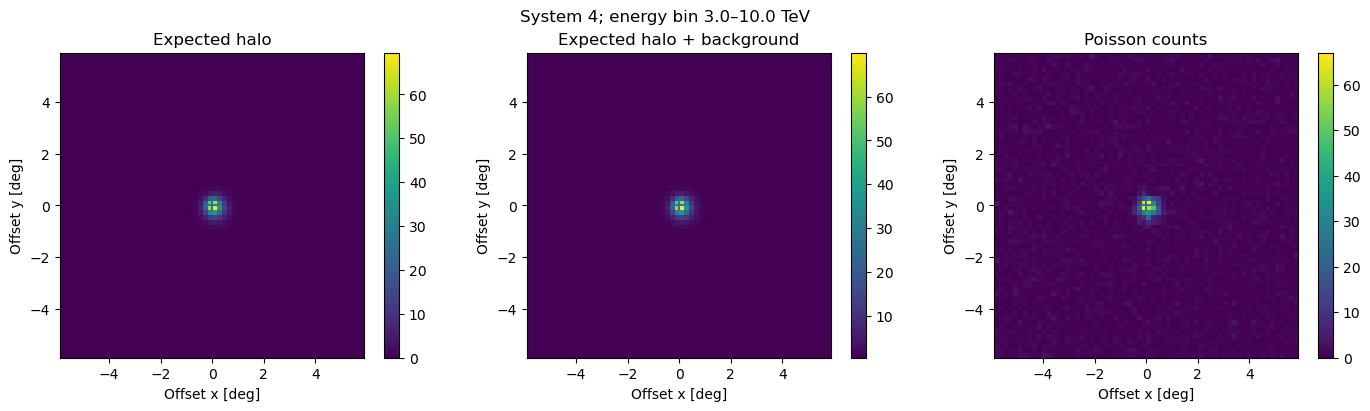

,4
system_id,4.000000e+00
age_kyr,3.314343e+01
distance_kpc,5.010069e-01
edot_erg_s,3.290921e+35
efficiency,4.797202e-02
D100_cm2_s,4.529085e+26
diffusion_index,3.559516e-01
injection_index,2.049604e+00
cutoff_TeV,1.069603e+02
tau0_kyr,2.394048e+01


In [9]:
sample_id = int(labels.source_fraction_expected.idxmax())
energy_id = 2  # roughly the 3-10 TeV bin with the default energy edges
extent = [sky_axis.min(), sky_axis.max(), sky_axis.min(), sky_axis.max()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
images = [
    source_mu[sample_id, energy_id],
    total_mu[sample_id, energy_id],
    counts[sample_id, energy_id],
]
titles = ["Expected halo", "Expected halo + background", "Poisson counts"]

for ax, image, title in zip(axes, images, titles):
    im = ax.imshow(image, origin="lower", extent=extent)
    ax.scatter([0.0], [0.0], marker="+", s=80, label="Current pulsar")
    ax.set_title(title)
    ax.set_xlabel("Offset x [deg]")
    ax.set_ylabel("Offset y [deg]")
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    f"System {sample_id}; energy bin {energy_edges[energy_id]:.1f}–"
    f"{energy_edges[energy_id+1]:.1f} TeV"
)
plt.show()

labels.loc[[sample_id]].T


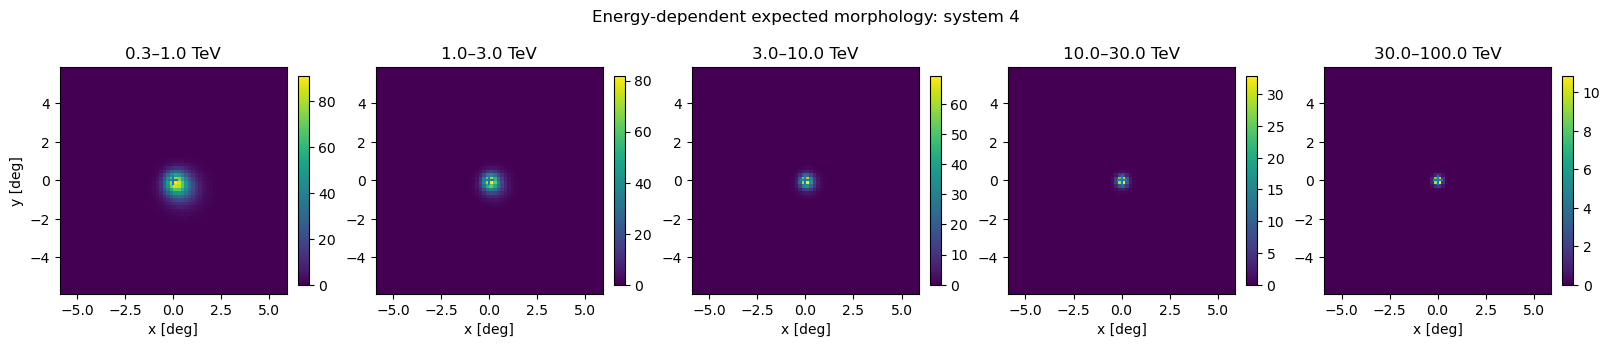

In [10]:
fig, axes = plt.subplots(1, n_energy, figsize=(3.2 * n_energy, 3.4), constrained_layout=True)
for ie, ax in enumerate(np.atleast_1d(axes)):
    im = ax.imshow(source_mu[sample_id, ie], origin="lower", extent=extent)
    ax.scatter([0.0], [0.0], marker="+", s=60)
    ax.set_title(f"{energy_edges[ie]:.1f}–{energy_edges[ie+1]:.1f} TeV")
    ax.set_xlabel("x [deg]")
    if ie == 0:
        ax.set_ylabel("y [deg]")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Energy-dependent expected morphology: system {sample_id}")
plt.show()


## 8. Classic Naima fit to the HESS J1837−069 gamma-ray SED

This section performs the benchmark study requested here:

1. combine the Fermi-LAT and H.E.S.S. spectral-energy-distribution points;
2. fit physically motivated radiative models with **Naima**;
3. save the fitted particle parameters;
4. pass those fitted parameters to the synthetic-population ranking in Section 9.

### Provenance and precision

- The H.E.S.S. collaboration provides the exact numerical spectrum behind the supplied H.E.S.S. plot. Those tabulated differential-flux values are converted here to
  \(E^2\,dN/dE\) in \(\mathrm{erg\,cm^{-2}\,s^{-1}}\).
- The Fermi-LAT points are digitized from the supplied FL16Y screenshot. The x-axis is in GeV, and the corrected table uses the visible bands 0.05–0.1, 0.1–0.3, 0.3–1, 1–3, 3–10, 10–30, 30–100, and 100–1000 GeV. These values remain suitable for a **benchmark/prototyping fit**, but should later be replaced by the exact row from the FL16Y FITS catalog.
- The first three visible Fermi-LAT bins are treated as upper limits; the five higher-energy points are detections.

The fit defaults to gamma rays only. The X-ray information is kept as a separate consistency constraint because the Chandra point source and compact nebula do not necessarily match the much larger gamma-ray extraction region.

> **Correction in this version:** the previous digitization accidentally shifted the Fermi-LAT energy bands upward and introduced a non-existent point at 0.5477 TeV. The corrected highest Fermi-LAT point is near 0.316 TeV.

In [2]:
# ── SED data: your own Fermi-LAT SED (.npy) + the built-in HESS table ───────
# Loads your own Fermi-LAT SED points (Fermipy-style .npy dict, E^2 dN/dE in
# MeV cm^-2 s^-1) in place of the notebook's digitized/CSV Fermi points.
# The built-in HESS J1837-069 numerical table below is unchanged, and the
# combined result is written into `classic_sed` with the exact same schema
# the rest of the notebook (Sections 8-9) already expects, so nothing
# downstream needs to change.

FERMI_SED_FILE = Path("/project/ls-gruen/users/asu.uenver/fermi/output_hess1837_1/roi_analysis/hess1837_sed.npy")  # <-- set this to your file

MEV_TO_TEV = 1e-6
tev_to_erg = 1.602176634  # 1 TeV = 1.602176634 erg

if not FERMI_SED_FILE.exists():
    raise FileNotFoundError(
        f"Fermi SED not found: {FERMI_SED_FILE}. "
        "Set FERMI_SED_FILE above to your own .npy path before running this cell."
    )

raw = np.load(FERMI_SED_FILE, allow_pickle=True).flat[0]
fermi_sed = dict(
    e_ctr         = np.array(raw['e_ctr'])         * MEV_TO_TEV,  # TeV
    e_min         = np.array(raw['e_min'])         * MEV_TO_TEV,
    e_max         = np.array(raw['e_max'])         * MEV_TO_TEV,
    e2dnde        = np.array(raw['e2dnde'])        * MEV_TO_TEV,  # TeV cm-2 s-1
    e2dnde_err_hi = np.array(raw['e2dnde_err_hi']) * MEV_TO_TEV,
    e2dnde_err_lo = np.array(raw['e2dnde_err_lo']) * MEV_TO_TEV,
    ts            = np.array(raw['ts']),
    ul            = np.array(raw.get('e2dnde_ul',
                                     raw['e2dnde'] * 2)) * MEV_TO_TEV,
)
fermi_sed['is_ul'] = fermi_sed['ts'] < 4.0
print(f"✓ Fermi SED: {len(fermi_sed['e_ctr'])} bins, "
      f"{(~fermi_sed['is_ul']).sum()} detections (TS>4)")

# Plot at the upper-limit value for non-detections (TS<4), at the measured
# e2dnde otherwise -- matches how cell below (Section 8's plot) draws ULs
# with a downward arrow at `flux_erg_cm2_s`.
is_ul = fermi_sed['is_ul']
flux_tev = np.where(is_ul, fermi_sed['ul'], fermi_sed['e2dnde'])

fermi_df = pd.DataFrame({
    "instrument": "Fermi-LAT",
    "energy_TeV": fermi_sed['e_ctr'],
    "energy_lo_TeV": fermi_sed['e_min'],
    "energy_hi_TeV": fermi_sed['e_max'],
    "flux_erg_cm2_s": flux_tev * tev_to_erg,
    "flux_error_lo_erg_cm2_s": fermi_sed['e2dnde_err_lo'] * tev_to_erg,
    "flux_error_hi_erg_cm2_s": fermi_sed['e2dnde_err_hi'] * tev_to_erg,
    "ul": is_ul,
    "provenance": "user_fermi_lat_sed_npy",
})

# Built-in HESS J1837-069 numerical table (H.E.S.S. published values, unchanged).
hess_energy = np.array([
    0.222308, 0.288461, 0.422034, 0.610243,
    0.884837, 1.29498, 1.88953, 2.74707,
    4.19217, 5.99275, 8.54779, 16.4452,
])
hess_dnde = np.array([
    2.82024e-10, 3.93396e-11, 3.21142e-11, 2.07182e-11,
    6.57914e-12, 3.28387e-12, 1.08900e-12, 4.72377e-13,
    2.81362e-13, 8.35974e-14, 3.40375e-14, 5.42638e-15,
])
hess_dnde_lo = np.array([
    1.44221e-10, 2.05788e-11, 6.44578e-12, 2.93353e-12,
    1.12113e-12, 5.30865e-13, 2.41590e-13, 1.34714e-13,
    6.63316e-14, 2.83258e-14, 1.25690e-14, 2.47605e-15,
])
hess_dnde_hi = np.array([
    1.54296e-10, 2.13974e-11, 6.67094e-12, 3.04057e-12,
    1.17069e-12, 5.58275e-13, 2.56409e-13, 1.44667e-13,
    7.24583e-14, 3.21689e-14, 1.49668e-14, 3.52043e-15,
])
hess_sed = hess_energy**2 * hess_dnde * tev_to_erg

hess_df = pd.DataFrame({
    "instrument": "HESS",
    "energy_TeV": hess_energy,
    "energy_lo_TeV": np.nan,
    "energy_hi_TeV": np.nan,
    "flux_erg_cm2_s": hess_sed,
    "flux_error_lo_erg_cm2_s": hess_energy**2 * hess_dnde_lo * tev_to_erg,
    "flux_error_hi_erg_cm2_s": hess_energy**2 * hess_dnde_hi * tev_to_erg,
    "ul": False,
    "provenance": "exact_HESS_published_numerical_table",
})

classic_sed = pd.concat([fermi_df, hess_df], ignore_index=True)
SED_DATA_PATH = FERMI_SED_FILE
print("Loaded Fermi SED from:", FERMI_SED_FILE)

COMBINED_SED_PATH = OUTPUT_DIR / "hessj1837_combined_sed.csv"
classic_sed.to_csv(COMBINED_SED_PATH, index=False)
print(f"Saved combined Fermi-LAT + HESS SED table: {COMBINED_SED_PATH.resolve()}")

classic_sed


✓ Fermi SED: 11 bins, 11 detections (TS>4)
Loaded Fermi SED from: /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_1/roi_analysis/hess1837_sed.npy
Saved combined Fermi-LAT + HESS SED table: /project/ls-gruen/users/asu.uenver/tev_halo_synthetic_demo_output/hessj1837_combined_sed.csv


,instrument,energy_TeV,energy_lo_TeV,energy_hi_TeV,flux_erg_cm2_s,flux_error_lo_erg_cm2_s,flux_error_hi_erg_cm2_s,ul,provenance
0,Fermi-LAT,0.001326,0.001000,0.001759,3.171580e-11,1.396010e-12,1.405232e-12,False,user_fermi_lat_sed_npy
1,Fermi-LAT,0.002334,0.001759,0.003095,3.162199e-11,1.410737e-12,1.423146e-12,False,user_fermi_lat_sed_npy
2,Fermi-LAT,0.004106,0.003095,0.005446,2.729544e-11,1.506973e-12,1.521544e-12,False,user_fermi_lat_sed_npy
3,Fermi-LAT,0.007224,0.005446,0.009582,2.912656e-11,1.721287e-12,1.737021e-12,False,user_fermi_lat_sed_npy
4,Fermi-LAT,0.012709,0.009582,0.016858,2.839467e-11,1.985911e-12,2.025662e-12,False,user_fermi_lat_sed_npy
5,Fermi-LAT,0.022361,0.016858,0.029660,2.858013e-11,2.394822e-12,2.484649e-12,False,user_fermi_lat_sed_npy
6,Fermi-LAT,0.039341,0.029660,0.052183,3.240007e-11,3.085056e-12,3.217453e-12,False,user_fermi_lat_sed_npy
7,Fermi-LAT,0.069217,0.052183,0.091810,2.907256e-11,3.794245e-12,4.044527e-12,False,user_fermi_lat_sed_npy
8,Fermi-LAT,0.121778,0.091810,0.161529,3.219436e-11,4.921308e-12,5.369376e-12,False,user_fermi_lat_sed_npy
9,Fermi-LAT,0.214255,0.161529,0.284191,1.451309e-11,5.069753e-12,5.718656e-12,False,user_fermi_lat_sed_npy


In [3]:
from pathlib import Path
Path("hessj1837_naima_outputs").mkdir(parents=True, exist_ok=True)
classic_sed.to_csv("hessj1837_naima_outputs/joint_classic_sed_points.csv", index=False)

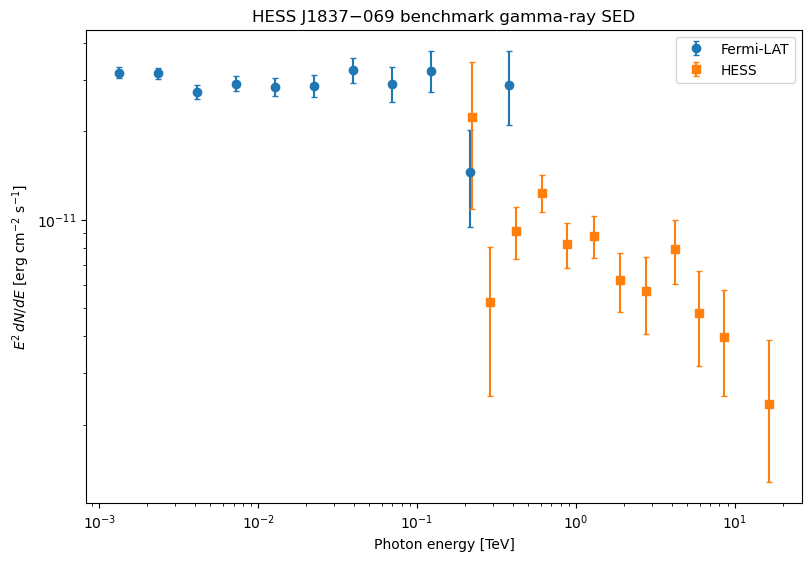

In [12]:
# Visual inspection of the extracted points before fitting.
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

for instrument, marker in [("Fermi-LAT", "o"), ("HESS", "s")]:
    subset = classic_sed[classic_sed["instrument"] == instrument]
    detections = subset[~subset["ul"].astype(bool)]
    limits = subset[subset["ul"].astype(bool)]

    if not detections.empty:
        ax.errorbar(
            detections["energy_TeV"],
            detections["flux_erg_cm2_s"],
            yerr=np.vstack([
                detections["flux_error_lo_erg_cm2_s"],
                detections["flux_error_hi_erg_cm2_s"],
            ]),
            fmt=marker,
            capsize=2,
            linestyle="none",
            label=instrument,
        )

    if not limits.empty:
        ax.errorbar(
            limits["energy_TeV"],
            limits["flux_erg_cm2_s"],
            yerr=0.35 * limits["flux_erg_cm2_s"],
            uplims=True,
            fmt=marker,
            capsize=2,
            linestyle="none",
            label=f"{instrument} upper limits",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [TeV]")
ax.set_ylabel(r"$E^2\,dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
ax.set_title("HESS J1837−069 benchmark gamma-ray SED")
ax.legend()
plt.show()

### 8.1 Optional X-ray consistency constraint

Gotthelf & Halpern (2008) resolved AX J1838.0−0655 into a pulsar and a compact nebula. For the nebula they reported approximately

$$
\Gamma_{\rm PWN}=1.6\;(1.1\text{–}2.0),\qquad
L_{2-10\,\mathrm{keV}}=5.2\times10^{33}\,d_{6.6}^{\,2}\ \mathrm{erg\,s^{-1}}.
$$

At 6.6 kpc this corresponds to an integrated nebular flux near
$$1.0\times10^{-12}\ \mathrm{erg\,cm^{-2}\,s^{-1}}$$.

This is **not included in the default likelihood** because:

- it is an integrated-band measurement rather than the original spectral points;
- it refers to a compact Chandra nebula, while the GeV/TeV regions are much larger;
- the pulsar and PWN spectra must not be mixed.

The cell below records the constraint for posterior checking. Once the original X-ray spectral table is available, the same electron population can be fit jointly with Naima `Synchrotron + InverseCompton`, with the magnetic field added as a free parameter.

In [13]:
HESSJ1837_DISTANCE_KPC = 6.6

distance_cm = HESSJ1837_DISTANCE_KPC * KPC_TO_CM
xray_pwn_luminosity_2_10_erg_s = 5.2e33
xray_pwn_flux_2_10_erg_cm2_s = (
    xray_pwn_luminosity_2_10_erg_s
    / (4.0 * np.pi * distance_cm**2)
)
xray_pwn_photon_index = 1.6

xray_constraint = pd.Series({
    "energy_band_keV": "2–10",
    "integrated_flux_erg_cm2_s": xray_pwn_flux_2_10_erg_cm2_s,
    "photon_index": xray_pwn_photon_index,
    "included_in_default_fit": False,
})
xray_constraint.to_frame("AX J1838.0−0655 compact PWN")

,AX J1838.0−0655 compact PWN
energy_band_keV,2–10
integrated_flux_erg_cm2_s,0.0
photon_index,1.6
included_in_default_fit,False


### 8.2 Build the Naima data table

Naima accepts detections and upper limits in an Astropy table. The following switches make the uncertainty treatment explicit:

- H.E.S.S. published statistical errors are used, with an optional 30% flux-scale systematic added in quadrature.
- A configurable fractional digitization uncertainty is added to the detected Fermi-LAT points.
- Catalog upper limits are kept as upper limits rather than converted into Gaussian detections.

In [14]:
%pip install astropy
%pip install naima

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Run this once in the active environment if Naima is unavailable:
# %pip install "naima>=0.10" "astropy>=6" "emcee>=3" "corner>=2"

try:
    import astropy.units as u
    from astropy.table import QTable, Table
    import naima
    from naima.models import (
        ExponentialCutoffPowerLaw,
        InverseCompton,
        PionDecay,
        Synchrotron,
    )
    from naima.utils import validate_data_table
    NAIMA_AVAILABLE = True
    print("Naima version:", naima.__version__)
except ImportError as exc:
    NAIMA_AVAILABLE = False
    print(
        "Naima/Astropy are not installed in this kernel. "
        "The extracted SED and forward model remain usable; "
        "install the packages and rerun this section for fitting."
    )
    print("Import error:", exc)

INCLUDE_HESS_30PCT_SYSTEMATIC = True
FERMI_DIGITIZATION_SYSTEMATIC_FRACTION = 0.10
UPPER_LIMIT_CONFIDENCE = 0.95

gamma_fit_table = None

if NAIMA_AVAILABLE:
    fit_df = (
        classic_sed.copy()
        .sort_values("energy_TeV")
        .reset_index(drop=True)
    )

    hess_mask = fit_df["instrument"].eq("HESS")
    fermi_detection_mask = (
        fit_df["instrument"].eq("Fermi-LAT")
        & ~fit_df["ul"].astype(bool)
    )

    if INCLUDE_HESS_30PCT_SYSTEMATIC:
        systematic = 0.30 * fit_df.loc[
            hess_mask, "flux_erg_cm2_s"
        ]
        fit_df.loc[
            hess_mask, "flux_error_lo_erg_cm2_s"
        ] = np.hypot(
            fit_df.loc[
                hess_mask, "flux_error_lo_erg_cm2_s"
            ],
            systematic,
        )
        fit_df.loc[
            hess_mask, "flux_error_hi_erg_cm2_s"
        ] = np.hypot(
            fit_df.loc[
                hess_mask, "flux_error_hi_erg_cm2_s"
            ],
            systematic,
        )

    fermi_systematic = (
        FERMI_DIGITIZATION_SYSTEMATIC_FRACTION
        * fit_df.loc[
            fermi_detection_mask, "flux_erg_cm2_s"
        ]
    )
    fit_df.loc[
        fermi_detection_mask, "flux_error_lo_erg_cm2_s"
    ] = np.hypot(
        fit_df.loc[
            fermi_detection_mask,
            "flux_error_lo_erg_cm2_s",
        ],
        fermi_systematic,
    )
    fit_df.loc[
        fermi_detection_mask, "flux_error_hi_erg_cm2_s"
    ] = np.hypot(
        fit_df.loc[
            fermi_detection_mask,
            "flux_error_hi_erg_cm2_s",
        ],
        fermi_systematic,
    )

    # Naima does not use Gaussian errors for rows flagged as upper limits,
    # but finite positive placeholders avoid zero-error warnings in validation
    # and plotting utilities.
    ul_mask = fit_df["ul"].astype(bool)
    ul_placeholder_error = 0.25 * fit_df.loc[
        ul_mask, "flux_erg_cm2_s"
    ]
    fit_df.loc[
        ul_mask, "flux_error_lo_erg_cm2_s"
    ] = ul_placeholder_error
    fit_df.loc[
        ul_mask, "flux_error_hi_erg_cm2_s"
    ] = ul_placeholder_error

    gamma_fit_table = QTable()
    gamma_fit_table["instrument"] = fit_df[
        "instrument"
    ].astype(str).to_numpy()
    gamma_fit_table["energy"] = (
        fit_df["energy_TeV"].to_numpy() * u.TeV
    )
    gamma_fit_table["flux"] = (
        fit_df["flux_erg_cm2_s"].to_numpy()
        * u.erg / (u.cm**2 * u.s)
    )
    gamma_fit_table["flux_error_lo"] = (
        fit_df["flux_error_lo_erg_cm2_s"].to_numpy()
        * u.erg / (u.cm**2 * u.s)
    )
    gamma_fit_table["flux_error_hi"] = (
        fit_df["flux_error_hi_erg_cm2_s"].to_numpy()
        * u.erg / (u.cm**2 * u.s)
    )
    gamma_fit_table["ul"] = fit_df[
        "ul"
    ].astype(bool).to_numpy()

    gamma_fit_table.meta["keywords"] = {
        "cl": {"value": UPPER_LIMIT_CONFIDENCE}
    }

    display(gamma_fit_table)

Naima version: 0.10.2


instrument,energy,flux,flux_error_lo,flux_error_hi,ul
,TeV,erg / (s cm2),erg / (s cm2),erg / (s cm2),
object,float64,float64,float64,float64,bool
Fermi-LAT,0.0013264167575909303,3.171580061538483e-11,3.4652219242382353e-12,3.468947500078807e-12,False
Fermi-LAT,0.002333672991608684,3.162199389947431e-11,3.4626121739965273e-12,3.467686431837749e-12,False
Fermi-LAT,0.004105820889699131,2.7295437612862272e-11,3.1179123265199077e-12,3.1249807696896264e-12,False
Fermi-LAT,0.007223704965908314,2.912655704342267e-11,3.3832515714940837e-12,3.3912838529914303e-12,False
Fermi-LAT,0.012709252263147848,2.8394667720935387e-11,3.4650270745559467e-12,3.4879617621901746e-12,False
Fermi-LAT,0.022360679663372778,2.858013175530179e-11,3.728728179714342e-12,3.7870465778924e-12,False
Fermi-LAT,0.03934141715463386,3.240006714987297e-11,4.47383684215083e-12,4.566141313441165e-12,False
Fermi-LAT,0.06921655817446629,2.9072561427603484e-11,4.780003117952983e-12,4.9809975763311534e-12,False


### 8.3 Radiative models

Two gamma-ray hypotheses are provided.

**Leptonic model**

$$
N_e(E)=A_e
\left(\frac{E}{10\ \mathrm{TeV}}\right)^{-p_e}
\exp\!\left(-\frac{E}{E_{\rm cut,e}}\right),
$$

with inverse-Compton emission on the CMB and configurable infrared fields. The normalization is parameterized by the total electron energy $W_e$ above 1 TeV.

**Hadronic model**

$$
N_p(E)=A_p
\left(\frac{E}{10\ \mathrm{TeV}}\right)^{-p_p}
\exp\!\left(-\frac{E}{E_{\rm cut,p}}\right),
$$

with gamma rays from neutral-pion decay. Its normalization is parameterized by $W_p$ above 1 GeV for a fixed gas density.

The seed-field densities and gas density are nuisance assumptions, not measurements from these gamma-ray points. They should later be promoted to priors or tied to environmental data.

In [16]:
DISTANCE = None
IC_SEED_FIELDS = None
TARGET_GAS_DENSITY = None
IC_INTERPOLATION_FALLBACK = True

if NAIMA_AVAILABLE:
    DISTANCE = HESSJ1837_DISTANCE_KPC * u.kpc

    # Use Naima's built-in thermal fields for numerical robustness.
    # Their default energy densities are CMB=0.261, FIR=0.5,
    # and NIR=1.0 eV cm^-3.
    IC_SEED_FIELDS = ["CMB", "FIR", "NIR"]
    TARGET_GAS_DENSITY = 1.0 / u.cm**3

    def _safe_ic_sed(ic_model, photon_energy, distance):
        """Evaluate IC SED and repair only isolated numerical NaNs.

        Naima's thermal IC kernel performs a log-log quadrature. In
        some package/version combinations an isolated photon energy can
        return NaN even though adjacent energies are finite. The direct
        result is used whenever it is finite. Otherwise, only the bad
        entries are replaced by log-log interpolation from a dense,
        finite model grid.
        """
        photon_energy = u.Quantity(photon_energy).to(u.TeV)
        direct = ic_model.sed(photon_energy, distance=distance)
        direct_values = np.asarray(direct.value, dtype=float)
        bad = ~np.isfinite(direct_values) | (direct_values <= 0.0)

        if not np.any(bad):
            return direct
        if not IC_INTERPOLATION_FALLBACK:
            return direct

        energy_values = photon_energy.to_value(u.TeV)
        e_min = max(np.nanmin(energy_values) / 1.25, 1e-8)
        e_max = np.nanmax(energy_values) * 1.25
        dense_energy = np.geomspace(e_min, e_max, 500) * u.TeV
        dense_sed = ic_model.sed(dense_energy, distance=distance)
        dense_values = np.asarray(dense_sed.value, dtype=float)
        good = np.isfinite(dense_values) & (dense_values > 0.0)

        if np.count_nonzero(good) < 2:
            return direct

        repaired = direct_values.copy()
        repaired[bad] = 10.0 ** np.interp(
            np.log10(energy_values[bad]),
            np.log10(dense_energy.to_value(u.TeV)[good]),
            np.log10(dense_values[good]),
        )
        return repaired * direct.unit

    def inverse_compton_ecpl(pars, data):
        log10_We_above_1TeV, particle_index, log10_cutoff_TeV = pars

        electrons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=particle_index,
            e_cutoff=(10.0**log10_cutoff_TeV) * u.TeV,
        )
        ic_model = InverseCompton(
            electrons,
            seed_photon_fields=IC_SEED_FIELDS,
            Eemin=1.0 * u.GeV,
            Eemax=500.0 * u.TeV,
            nEed=200,
        )
        ic_model.set_We(
            (10.0**log10_We_above_1TeV) * u.erg,
            Eemin=1.0 * u.TeV,
        )

        model_sed = _safe_ic_sed(
            ic_model,
            data["energy"],
            DISTANCE,
        ).to(data["flux"].unit)

        return model_sed, ic_model.compute_We(
            Eemin=1.0 * u.TeV
        )

    def inverse_compton_prior(pars):
        return (
            naima.uniform_prior(pars[0], 44.0, 52.0)
            + naima.uniform_prior(pars[1], 1.0, 4.5)
            + naima.uniform_prior(pars[2], -1.0, 4.0)
        )

    def pion_decay_ecpl(pars, data):
        log10_Wp_above_1GeV, particle_index, log10_cutoff_TeV = pars

        protons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=particle_index,
            e_cutoff=(10.0**log10_cutoff_TeV) * u.TeV,
        )
        pion_model = PionDecay(
            protons,
            nh=TARGET_GAS_DENSITY,
        )
        pion_model.set_Wp(
            (10.0**log10_Wp_above_1GeV) * u.erg,
            Epmin=1.0 * u.GeV,
        )

        model_sed = pion_model.sed(
            data["energy"],
            distance=DISTANCE,
        ).to(data["flux"].unit)

        return model_sed, pion_model.compute_Wp(
            Epmin=1.0 * u.GeV
        )

    def pion_decay_prior(pars):
        return (
            naima.uniform_prior(pars[0], 45.0, 54.0)
            + naima.uniform_prior(pars[1], 1.0, 4.5)
            + naima.uniform_prior(pars[2], 0.0, 6.0)
        )

### 8.4 Run the Naima MCMC fits

Both switches default to `False` so that the forward-model notebook remains quick to execute. Set the desired switch to `True` after installing Naima.

This corrected version explicitly sets

```python
guess=False
```

in `naima.run_sampler`. Naima otherwise tries to estimate the first normalization parameter automatically. For this mixed Fermi-LAT/H.E.S.S. table, that automatic estimate can become non-finite and overwrite the valid initial value of `log10(We)` with `NaN`. The cell also evaluates the initial radiative model before starting the walkers and stops with a targeted error if any model value is non-finite.

Recommended first pass:

```python
RUN_IC_MCMC = True
N_BURN = 150
N_RUN = 500
```

Inspect the chain, corner plot, SED fit, and acceptance behavior before increasing the chain length.

**Numerical correction in this version:** the earlier Fermi-LAT table contained an erroneously shifted energy at 0.5477 TeV. That artificial point triggered an isolated non-finite value in the thermal inverse-Compton quadrature. The corrected table removes that point. A conservative interpolation fallback is also included for isolated Naima kernel NaNs; it does not alter finite model values.


In [17]:
RUN_IC_MCMC = True
RUN_HADRONIC_MCMC = True

N_WALKERS = 32
N_BURN = 150
N_RUN = 500
N_THREADS = 1

# Critical stability options:
# - Naima's automatic normalization guess is disabled because the first
#   parameter is already log10(We) or log10(Wp). For this mixed SED/upper-limit
#   table the automatic integral-ratio guess can become non-finite and replace
#   the valid initial normalization with NaN.
# - The Nelder-Mead prefit can remain enabled once the supplied p0 is verified.
NAIMA_GUESS_NORMALIZATION = True
NAIMA_PREFIT = True

NAIMA_OUTPUT_DIR = Path("hessj1837_naima_outputs")
NAIMA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ic_sampler = None
hadronic_sampler = None


def _check_initial_model(model_function, p0, data, model_name):
    """Fail early with a useful message if the initial model is non-finite."""
    p0 = np.asarray(p0, dtype=float)
    if not np.all(np.isfinite(p0)):
        raise ValueError(f"{model_name} p0 contains non-finite values: {p0}")

    model_output = model_function(p0, data)
    model_sed = model_output[0] if isinstance(model_output, (tuple, list)) else model_output
    values = np.asarray(model_sed.value, dtype=float)

    if not np.all(np.isfinite(values)):
        bad = np.where(~np.isfinite(values))[0]
        bad_energies = data["energy"][bad]
        raise ValueError(
            f"{model_name} returned non-finite SED values at "
            f"energies {bad_energies}. Check the seed fields and energy range."
        )
    if np.any(values < 0):
        raise ValueError(f"{model_name} returned negative SED values.")

    print(f"{model_name} initial p0:", p0)
    print(
        f"{model_name} initial SED range:",
        np.nanmin(values), "to", np.nanmax(values), model_sed.unit,
    )


if RUN_IC_MCMC:
    if not NAIMA_AVAILABLE:
        raise RuntimeError("Install Naima and Astropy first.")
    if gamma_fit_table is None:
        raise RuntimeError("The gamma-ray data table was not built.")

    ic_p0 = np.array([
        48.0,              # log10 We(Ee > 1 TeV) [erg]
        2.5,               # electron index
        np.log10(20.0),    # electron cutoff [TeV]
    ], dtype=float)
    ic_labels = [
        "log10(We_Ee_gt_1TeV)",
        "index",
        "log10(e_cutoff)",
    ]

    ic_data = validate_data_table(gamma_fit_table, sed=True)
    _check_initial_model(
        inverse_compton_ecpl,
        ic_p0,
        ic_data,
        "Inverse-Compton model",
    )

    ic_sampler, _ = naima.run_sampler(
        data_table=gamma_fit_table,
        p0=ic_p0.copy(),
        labels=ic_labels,
        model=inverse_compton_ecpl,
        prior=inverse_compton_prior,
        nwalkers=N_WALKERS,
        nburn=N_BURN,
        nrun=N_RUN,
        threads=N_THREADS,
        guess=NAIMA_GUESS_NORMALIZATION,
        prefit=NAIMA_PREFIT,
        interactive=False,
        data_sed=True,
    )

    naima.save_run(
        str(NAIMA_OUTPUT_DIR / "HESSJ1837_IC_run.hdf5"),
        ic_sampler,
    )
    naima.save_diagnostic_plots(
        str(NAIMA_OUTPUT_DIR / "HESSJ1837_IC"),
        ic_sampler,
        sed=True,
        last_step=False,
        blob_labels=[
            r"$W_e(E_e>1\,\mathrm{TeV})$",
        ],
    )

if RUN_HADRONIC_MCMC:
    if not NAIMA_AVAILABLE:
        raise RuntimeError("Install Naima and Astropy first.")
    if gamma_fit_table is None:
        raise RuntimeError("The gamma-ray data table was not built.")

    hadronic_p0 = np.array([
        50.0,               # log10 Wp(Ep > 1 GeV) [erg]
        2.2,                # proton index
        np.log10(100.0),    # proton cutoff [TeV]
    ], dtype=float)
    hadronic_labels = [
        "log10(Wp_Ep_gt_1GeV)",
        "index",
        "log10(e_cutoff)",
    ]

    hadronic_data = validate_data_table(gamma_fit_table, sed=True)
    _check_initial_model(
        pion_decay_ecpl,
        hadronic_p0,
        hadronic_data,
        "Pion-decay model",
    )

    hadronic_sampler, _ = naima.run_sampler(
        data_table=gamma_fit_table,
        p0=hadronic_p0.copy(),
        labels=hadronic_labels,
        model=pion_decay_ecpl,
        prior=pion_decay_prior,
        nwalkers=N_WALKERS,
        nburn=N_BURN,
        nrun=N_RUN,
        threads=N_THREADS,
        guess=NAIMA_GUESS_NORMALIZATION,
        prefit=NAIMA_PREFIT,
        interactive=False,
        data_sed=True,
    )

    naima.save_run(
        str(NAIMA_OUTPUT_DIR / "HESSJ1837_PionDecay_run.hdf5"),
        hadronic_sampler,
    )
    naima.save_diagnostic_plots(
        str(NAIMA_OUTPUT_DIR / "HESSJ1837_PionDecay"),
        hadronic_sampler,
        sed=True,
        last_step=False,
        blob_labels=[
            r"$W_p(E_p>1\,\mathrm{GeV})$",
        ],
    )

Inverse-Compton model initial p0: [48.       2.5      1.30103]
Inverse-Compton model initial SED range: 9.883161473949766e-13 to 7.468717420135049e-12 erg / (s cm2)
INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [48.56164208  2.5         1.30103   ] [naima.core]
INFO:    Initial lnprob(p0): -154.030 [naima.core]
INFO:    New ML parameters : [48.37093525  2.90989525  1.20169028] [naima.core]
INFO:    Maximum lnprob(p0): -17.234 [naima.core]
Burning in the 32 walkers with 150 steps...

Progress of the run: 0 percent (0 of 150 steps)
                           log10(We_Ee_gt_1TeV) -----index----- log10(e_cutoff)
  Last ensemble median :      48.4            2.91             1.2      
  Last ensemble std    :      0.188          0.0122          0.00534    
  Last ensemble lnprob :  avg: -84.040, max: -17.207

Progress of the run: 10 percent (15 of 150 steps)
                           log10(We_Ee_gt_1TeV) -----index-----

/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/naima/analysis.py:153: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f.clf()


INFO: Plotting Model output 1... [naima.analysis]
Pion-decay model initial p0: [50.   2.2  2. ]
Pion-decay model initial SED range: 3.3955471796418997e-14 to 4.660235584018626e-13 erg / (s cm2)
INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [51.86539189  2.2         2.        ] [naima.core]
INFO:    Initial lnprob(p0): -21.381 [naima.core]
INFO:    New ML parameters : [51.86773704  2.23859799  1.97682673] [naima.core]
INFO:    Maximum lnprob(p0): -16.627 [naima.core]
Burning in the 32 walkers with 150 steps...

Progress of the run: 0 percent (0 of 150 steps)
                           log10(Wp_Ep_gt_1GeV) -----index----- log10(e_cutoff)
  Last ensemble median :      51.9            2.24            1.98      
  Last ensemble std    :      0.217          0.0144           0.012     
  Last ensemble lnprob :  avg: -134.116, max: -16.821

Progress of the run: 10 percent (15 of 150 steps)
                           log10(W

/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/naima/analysis.py:153: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f.clf()


INFO: Plotting Model output 1... [naima.analysis]


### 8.5 Save the fitted parameters and connect them to the synthetic sample

When the inverse-Compton chain is run, the next cell writes

```text
naima_fit_Fermi_HESS_classic_results.ecsv
```

with the posterior medians and 16th/84th-percentile uncertainties. Section 9 prioritizes this file automatically and ranks every synthetic system using:

- particle index;
- cutoff energy;
- electron energy above 1 TeV.

This is still a proxy comparison: the Naima fit describes the **present-day radiating electron distribution**, while the forward model currently samples an **injection distribution**. A future transport calculation should evolve every sampled injection spectrum before the comparison.

In [18]:
CLASSIC_RESULTS_PATH = Path(
    "naima_fit_Fermi_HESS_classic_results.ecsv"
)
classic_fit_summary = None

def _flat_sampler_chain(sampler):
    if hasattr(sampler, "get_chain"):
        return np.asarray(sampler.get_chain(flat=True))
    chain = np.asarray(sampler.chain)
    return chain.reshape(-1, chain.shape[-1])

def _summary_row(label, samples):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    return {
        "label": label,
        "median": q50,
        "unc_lo": q50 - q16,
        "unc_hi": q84 - q50,
    }

if ic_sampler is not None:
    chain = _flat_sampler_chain(ic_sampler)

    logwe_samples = chain[:, 0]
    index_samples = chain[:, 1]
    logecut_samples = chain[:, 2]
    ecut_samples = 10.0**logecut_samples
    we_samples = 10.0**logwe_samples

    summary_rows = [
        _summary_row("log10(We)", logwe_samples),
        _summary_row("index", index_samples),
        _summary_row("log10(e_cutoff)", logecut_samples),
        _summary_row("e_cutoff", ecut_samples),
        _summary_row("blob1", we_samples),
    ]
    classic_fit_summary = pd.DataFrame(summary_rows)

    astropy_summary = Table.from_pandas(classic_fit_summary)
    astropy_summary.meta["model"] = "InverseCompton_ECPL"
    astropy_summary.meta["distance_kpc"] = (
        HESSJ1837_DISTANCE_KPC
    )
    astropy_summary.meta["particle_energy_definition"] = (
        "We above 1 TeV"
    )
    astropy_summary.write(
        CLASSIC_RESULTS_PATH,
        format="ascii.ecsv",
        overwrite=True,
    )

    display(classic_fit_summary)
    print("Saved:", CLASSIC_RESULTS_PATH.resolve())
else:
    print(
        "No new MCMC chain is present. Set RUN_IC_MCMC=True "
        "and rerun Sections 8.2–8.5 to create the classic-fit "
        "results file."
    )

,label,median,unc_lo,unc_hi
0,log10(We),4.832541e+01,3.623272e-02,3.676711e-02
1,index,2.990406e+00,5.274658e-02,4.422276e-02
2,log10(e_cutoff),1.769545e+00,3.807321e-01,9.242431e-01
3,e_cutoff,5.882275e+01,3.434265e+01,4.352472e+02
4,blob1,2.115489e+48,1.693312e+47,1.868957e+47


Saved: /project/ls-gruen/users/asu.uenver/naima_fit_Fermi_HESS_classic_results.ecsv


### 8.6 Plot the SED data together with the fitted radiative models

This section overlays the benchmark SED points with the fitted radiative models.

- If `ic_sampler` and/or `hadronic_sampler` were created in Section 8.4, the plot shows the **median model** together with a cloud of posterior sample curves.
- If no live sampler is present, the notebook tries to read the saved inverse-Compton summary file
  `naima_fit_Fermi_HESS_classic_results.ecsv` and plots its median model.
- The hadronic median curve is plotted only when a live hadronic sampler is available in the current session.

This is the most direct visual check of how well the radiative model follows the combined Fermi-LAT + H.E.S.S. SED.

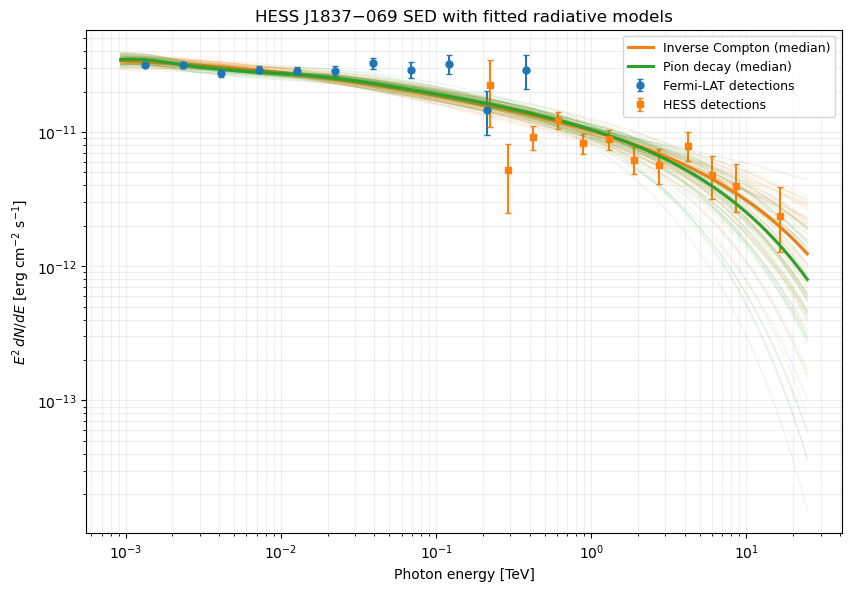

In [19]:
PLOT_POSTERIOR_SAMPLES = 50

if not NAIMA_AVAILABLE:
    print(
        "Naima/Astropy are not installed in this kernel, so the radiative-model "
        "overlay cannot be drawn here. Install the optional dependencies and rerun "
        "Sections 8.2–8.6."
    )
else:
    energy_grid = np.geomspace(
        classic_sed["energy_TeV"].min() * 0.7,
        classic_sed["energy_TeV"].max() * 1.5,
        300,
    ) * u.TeV

    sed_unit = u.erg / (u.cm**2 * u.s)

    def ic_sed_from_pars(pars, energy):
        log10_We_above_1TeV, particle_index, log10_cutoff_TeV = pars
        electrons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=particle_index,
            e_cutoff=(10.0 ** log10_cutoff_TeV) * u.TeV,
        )
        ic_model = InverseCompton(
            electrons,
            seed_photon_fields=IC_SEED_FIELDS,
            Eemin=1.0 * u.GeV,
            Eemax=500.0 * u.TeV,
            nEed=200,
        )
        ic_model.set_We(
            (10.0 ** log10_We_above_1TeV) * u.erg,
            Eemin=1.0 * u.TeV,
        )
        return _safe_ic_sed(ic_model, energy, DISTANCE).to(sed_unit)

    def hadronic_sed_from_pars(pars, energy):
        log10_Wp_above_1GeV, particle_index, log10_cutoff_TeV = pars
        protons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=particle_index,
            e_cutoff=(10.0 ** log10_cutoff_TeV) * u.TeV,
        )
        pion_model = PionDecay(protons, nh=TARGET_GAS_DENSITY)
        pion_model.set_Wp(
            (10.0 ** log10_Wp_above_1GeV) * u.erg,
            Epmin=1.0 * u.GeV,
        )
        return pion_model.sed(energy, distance=DISTANCE).to(sed_unit)

    def load_ic_median_pars_from_summary(path: Path):
        if not path.exists():
            return None
        summary_tbl = Table.read(path, format="ascii.ecsv")
        summary_df = summary_tbl.to_pandas().set_index("label")
        needed = ["log10(We)", "index", "log10(e_cutoff)"]
        if not all(label in summary_df.index for label in needed):
            return None
        return np.array([
            float(summary_df.loc["log10(We)", "median"]),
            float(summary_df.loc["index", "median"]),
            float(summary_df.loc["log10(e_cutoff)", "median"]),
        ])

    fig, ax = plt.subplots(figsize=(8.4, 5.8), constrained_layout=True)

    # Data points.
    for instrument, marker in [("Fermi-LAT", "o"), ("HESS", "s")]:
        subset = classic_sed[classic_sed["instrument"] == instrument]
        detections = subset[~subset["ul"].astype(bool)]
        limits = subset[subset["ul"].astype(bool)]

        if not detections.empty:
            ax.errorbar(
                detections["energy_TeV"],
                detections["flux_erg_cm2_s"],
                xerr=None,
                yerr=np.vstack([
                    detections["flux_error_lo_erg_cm2_s"],
                    detections["flux_error_hi_erg_cm2_s"],
                ]),
                fmt=marker,
                markersize=5,
                capsize=2,
                linestyle="none",
                label=f"{instrument} detections",
            )

        if not limits.empty:
            ax.errorbar(
                limits["energy_TeV"],
                limits["flux_erg_cm2_s"],
                yerr=0.35 * limits["flux_erg_cm2_s"],
                uplims=True,
                fmt=marker,
                markersize=5,
                capsize=2,
                linestyle="none",
                label=f"{instrument} upper limits",
            )

    # Inverse-Compton overlay.
    ic_drawn = False
    ic_median_sed_values = None
    ic_posterior_sed_values = None
    if ic_sampler is not None:
        ic_chain = _flat_sampler_chain(ic_sampler)
        rng_local = np.random.default_rng(12345)
        draw_idx = rng_local.choice(
            len(ic_chain),
            size=min(PLOT_POSTERIOR_SAMPLES, len(ic_chain)),
            replace=False,
        )
        ic_posterior_sed_values = np.array([
            ic_sed_from_pars(ic_chain[idx], energy_grid).value for idx in draw_idx
        ])
        for sample_sed in ic_posterior_sed_values:
            ax.plot(
                energy_grid.value,
                sample_sed,
                linewidth=0.8,
                alpha=0.10,
                color="tab:orange",
            )
        ic_median = np.median(ic_chain, axis=0)
        ic_median_sed_values = ic_sed_from_pars(ic_median, energy_grid).value
        ax.plot(
            energy_grid.value,
            ic_median_sed_values,
            color="tab:orange",
            linewidth=2.2,
            label="Inverse Compton (median)",
        )
        ic_drawn = True
    else:
        ic_summary_path = Path("naima_fit_Fermi_HESS_classic_results.ecsv")
        ic_median = load_ic_median_pars_from_summary(ic_summary_path)
        if ic_median is not None:
            ic_median_sed_values = ic_sed_from_pars(ic_median, energy_grid).value
            ax.plot(
                energy_grid.value,
                ic_median_sed_values,
                color="tab:orange",
                linewidth=2.2,
                label="Inverse Compton (median from saved summary)",
            )
            ic_drawn = True

    # Hadronic overlay.
    hadronic_drawn = False
    hadronic_median_sed_values = None
    hadronic_posterior_sed_values = None
    if hadronic_sampler is not None:
        had_chain = _flat_sampler_chain(hadronic_sampler)
        rng_local = np.random.default_rng(54321)
        draw_idx = rng_local.choice(
            len(had_chain),
            size=min(PLOT_POSTERIOR_SAMPLES, len(had_chain)),
            replace=False,
        )
        hadronic_posterior_sed_values = np.array([
            hadronic_sed_from_pars(had_chain[idx], energy_grid).value for idx in draw_idx
        ])
        for sample_sed in hadronic_posterior_sed_values:
            ax.plot(
                energy_grid.value,
                sample_sed,
                linewidth=0.8,
                alpha=0.10,
                color="tab:green",
            )
        had_median = np.median(had_chain, axis=0)
        hadronic_median_sed_values = hadronic_sed_from_pars(had_median, energy_grid).value
        ax.plot(
            energy_grid.value,
            hadronic_median_sed_values,
            color="tab:green",
            linewidth=2.2,
            label="Pion decay (median)",
        )
        hadronic_drawn = True

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Photon energy [TeV]")
    ax.set_ylabel(r"$E^2\,dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
    ax.set_title("HESS J1837−069 SED with fitted radiative models")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, which="both", alpha=0.2)

    SED_PLOT_PATH = NAIMA_OUTPUT_DIR / "hessj1837_sed_fitted_models.png"
    fig.savefig(SED_PLOT_PATH, dpi=200, bbox_inches="tight")
    print(f"Saved: {SED_PLOT_PATH.resolve()}")

    # Save the plotted curve data itself (not just the image), so the exact
    # numbers behind this figure can be reloaded/replotted elsewhere without
    # rerunning Naima.
    SED_CURVES_NPZ_PATH = NAIMA_OUTPUT_DIR / "hessj1837_sed_curves.npz"
    npz_payload = {"energy_TeV": energy_grid.value}
    if ic_median_sed_values is not None:
        npz_payload["ic_median_sed"] = ic_median_sed_values
    if ic_posterior_sed_values is not None:
        npz_payload["ic_posterior_seds"] = ic_posterior_sed_values
    if hadronic_median_sed_values is not None:
        npz_payload["hadronic_median_sed"] = hadronic_median_sed_values
    if hadronic_posterior_sed_values is not None:
        npz_payload["hadronic_posterior_seds"] = hadronic_posterior_sed_values
    np.savez(SED_CURVES_NPZ_PATH, **npz_payload)
    print(f"Saved: {SED_CURVES_NPZ_PATH.resolve()}")

    # Plain CSV with just the two median curves, for quick use in other
    # plotting tools (Excel, Origin, a paper's own plotting script, ...).
    SED_CURVES_CSV_PATH = NAIMA_OUTPUT_DIR / "hessj1837_sed_median_curves.csv"
    curves_df = pd.DataFrame({"energy_TeV": energy_grid.value})
    if ic_median_sed_values is not None:
        curves_df["ic_median_sed_erg_cm2_s"] = ic_median_sed_values
    if hadronic_median_sed_values is not None:
        curves_df["hadronic_median_sed_erg_cm2_s"] = hadronic_median_sed_values
    curves_df.to_csv(SED_CURVES_CSV_PATH, index=False)
    print(f"Saved: {SED_CURVES_CSV_PATH.resolve()}")

    plt.show()

    if not ic_drawn and not hadronic_drawn:
        print(
            "No fitted radiative-model parameters were available yet. "
            "Run Section 8.4 (for example with RUN_IC_MCMC=True) and then rerun "
            "Sections 8.5–8.6 to draw the model overlay."
        )

### 8.7 Temporary absorption-corrected X-ray benchmark with a filling/aperture factor

Until the original Chandra spectral table is available, this section constructs a **provisional X-ray SED** for the compact nebula around AX J1838.0−0655 from the published absorption-corrected quantities

$$
F_{2-10\,\mathrm{keV}} \simeq 1.0\times10^{-12}
\ \mathrm{erg\,cm^{-2}\,s^{-1}},
\qquad
\Gamma_X \simeq 1.6\;(1.1\text{--}2.0).
$$

For a photon power law, $dN/dE\propto E^{-\Gamma_X}$, the temporary SED points are normalized so that their integral reproduces the published 2–10 keV unabsorbed energy flux. The uncertainty envelope combines the published photon-index interval with a configurable fractional flux uncertainty.

These points are **not independent X-ray measurements**; they are several samples of the same reconstructed power law. They are intended only for a benchmark fit and should be replaced by the real absorption-corrected X-ray spectrum before scientific interpretation.

The joint model uses

$$
F_X(E)=f_X F_{\rm syn}(E),
$$

where $f_X$ is a phenomenological filling/aperture factor connecting the compact X-ray extraction region to the larger gamma-ray-emitting particle population. It can either be fitted or fixed below.

,instrument,energy_keV,flux_erg_cm2_s,flux_error_lo_erg_cm2_s,flux_error_hi_erg_cm2_s,ul,absorption_corrected,provenance
0,Chandra PWN (temporary),2.3,4.670265e-13,2.481518e-13,3.388596e-13,False,True,reconstructed_from_Gotthelf_Halpern_2008_band_...
1,Chandra PWN (temporary),3.5,5.524304e-13,2.330549e-13,2.534556e-13,False,True,reconstructed_from_Gotthelf_Halpern_2008_band_...
2,Chandra PWN (temporary),5.5,6.619047e-13,2.316666e-13,2.316666e-13,False,True,reconstructed_from_Gotthelf_Halpern_2008_band_...
3,Chandra PWN (temporary),8.5,7.878036e-13,3.538649e-13,5.303400e-13,False,True,reconstructed_from_Gotthelf_Halpern_2008_band_...


energy,flux,flux_error_lo,flux_error_hi,ul
keV,erg / (s cm2),erg / (s cm2),erg / (s cm2),
float64,float64,float64,float64,bool
2.3,4.670264740113217e-13,2.4815184574349393e-13,3.388595850804764e-13,False
3.5,5.524304172424397e-13,2.330549087094398e-13,2.534556418493584e-13,False
5.5,6.619046638897883e-13,2.316666323614259e-13,2.316666323614259e-13,False
8.5,7.87803553995587e-13,3.53864906792311e-13,5.303400131203374e-13,False


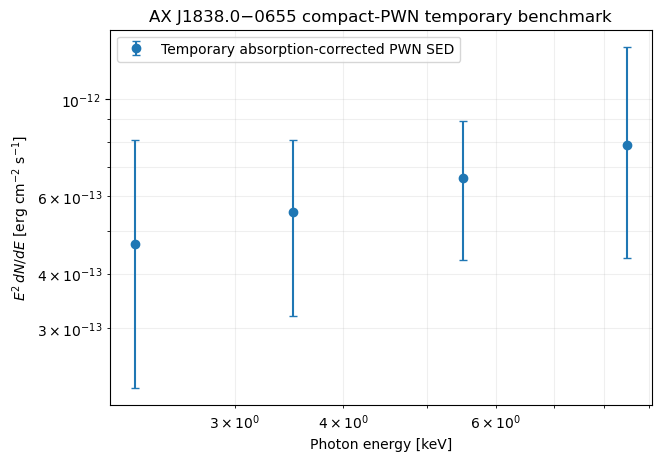

In [20]:
# Temporary X-ray benchmark configuration.
XRAY_FLUX_IS_ABSORPTION_CORRECTED = True
XRAY_BAND_MIN_KEV = 2.0
XRAY_BAND_MAX_KEV = 10.0
XRAY_PWN_FLUX_2_10 = xray_pwn_flux_2_10_erg_cm2_s
XRAY_PHOTON_INDEX = 1.6
XRAY_PHOTON_INDEX_LO = 1.1
XRAY_PHOTON_INDEX_HI = 2.0
XRAY_INTEGRATED_FLUX_FRACTIONAL_ERROR = 0.30
XRAY_PSEUDOPOINT_ERROR_FLOOR = 0.35

# This is a phenomenological region/filling factor, not a measured geometric
# volume-filling factor. With FIT_XRAY_FILLING_FACTOR=True it is fitted in log space.
FIT_XRAY_FILLING_FACTOR = True
XRAY_FILLING_FACTOR_FIXED = 0.10
XRAY_FILLING_FACTOR_INITIAL = 0.10
XRAY_FILLING_FACTOR_LOG10_MIN = -3.0
XRAY_FILLING_FACTOR_LOG10_MAX = 0.0

# Four representative energies inside the published band. The points are
# correlated because they come from one integrated flux and one photon index.
xray_energy_keV = np.array([2.3, 3.5, 5.5, 8.5], dtype=float)


def sed_from_integrated_powerlaw_flux(
    energy_keV,
    integrated_flux,
    photon_index,
    e_min_keV=2.0,
    e_max_keV=10.0,
):
    """Return E^2 dN/dE normalized to an integrated energy flux.

    Both the returned SED and integrated_flux are in erg cm^-2 s^-1.
    """
    energy_keV = np.asarray(energy_keV, dtype=float)
    exponent = 2.0 - float(photon_index)
    if np.isclose(exponent, 0.0):
        normalization = 1.0 / np.log(e_max_keV / e_min_keV)
    else:
        normalization = exponent / (
            e_max_keV**exponent - e_min_keV**exponent
        )
    return integrated_flux * normalization * energy_keV**exponent


xray_sed_central = sed_from_integrated_powerlaw_flux(
    xray_energy_keV,
    XRAY_PWN_FLUX_2_10,
    XRAY_PHOTON_INDEX,
    XRAY_BAND_MIN_KEV,
    XRAY_BAND_MAX_KEV,
)

# Construct a conservative envelope from the flux-normalization uncertainty
# and the published photon-index interval.
trial_seds = []
for trial_flux_scale in [
    1.0 - XRAY_INTEGRATED_FLUX_FRACTIONAL_ERROR,
    1.0,
    1.0 + XRAY_INTEGRATED_FLUX_FRACTIONAL_ERROR,
]:
    for trial_index in [
        XRAY_PHOTON_INDEX_LO,
        XRAY_PHOTON_INDEX,
        XRAY_PHOTON_INDEX_HI,
    ]:
        trial_seds.append(
            sed_from_integrated_powerlaw_flux(
                xray_energy_keV,
                XRAY_PWN_FLUX_2_10 * trial_flux_scale,
                trial_index,
                XRAY_BAND_MIN_KEV,
                XRAY_BAND_MAX_KEV,
            )
        )

trial_seds = np.asarray(trial_seds)
xray_sed_min = np.min(trial_seds, axis=0)
xray_sed_max = np.max(trial_seds, axis=0)
xray_sed_error_lo = np.maximum(
    xray_sed_central - xray_sed_min,
    XRAY_PSEUDOPOINT_ERROR_FLOOR * xray_sed_central,
)
xray_sed_error_hi = np.maximum(
    xray_sed_max - xray_sed_central,
    XRAY_PSEUDOPOINT_ERROR_FLOOR * xray_sed_central,
)

xray_pseudo_df = pd.DataFrame({
    "instrument": "Chandra PWN (temporary)",
    "energy_keV": xray_energy_keV,
    "flux_erg_cm2_s": xray_sed_central,
    "flux_error_lo_erg_cm2_s": xray_sed_error_lo,
    "flux_error_hi_erg_cm2_s": xray_sed_error_hi,
    "ul": False,
    "absorption_corrected": XRAY_FLUX_IS_ABSORPTION_CORRECTED,
    "provenance": "reconstructed_from_Gotthelf_Halpern_2008_band_flux_and_index",
})

display(xray_pseudo_df)

xray_pseudo_table = None
if NAIMA_AVAILABLE:
    xray_pseudo_table = QTable()
    xray_pseudo_table["energy"] = xray_energy_keV * u.keV
    xray_pseudo_table["flux"] = (
        xray_sed_central * u.erg / (u.cm**2 * u.s)
    )
    xray_pseudo_table["flux_error_lo"] = (
        xray_sed_error_lo * u.erg / (u.cm**2 * u.s)
    )
    xray_pseudo_table["flux_error_hi"] = (
        xray_sed_error_hi * u.erg / (u.cm**2 * u.s)
    )
    xray_pseudo_table["ul"] = np.zeros(len(xray_energy_keV), dtype=bool)

    display(xray_pseudo_table)

fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
ax.errorbar(
    xray_energy_keV,
    xray_sed_central,
    yerr=np.vstack([xray_sed_error_lo, xray_sed_error_hi]),
    fmt="o",
    capsize=3,
    label="Temporary absorption-corrected PWN SED",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Photon energy [keV]")
ax.set_ylabel(r"$E^2\,dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
ax.set_title("AX J1838.0−0655 compact-PWN temporary benchmark")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
plt.show()

### 8.8 Joint `Synchrotron + InverseCompton + PionDecay` fit

The hybrid model has one electron population shared by synchrotron and inverse-Compton emission, plus an independent proton population for neutral-pion decay:

\[
F_{\rm model}(E)=
\begin{cases}
 f_X F_{\rm syn}(E), & \text{temporary X-ray data},\\[2mm]
 F_{\rm IC}(E)+F_{\pi^0}(E), & \text{Fermi-LAT and H.E.S.S. data}.
\end{cases}
\]

The free parameters are the electron energy content, electron index and cutoff, magnetic field, proton energy content, proton index and cutoff, and—optionally—the X-ray filling/aperture factor. Naima accepts the X-ray and gamma-ray tables as a list and internally concatenates them in SED form.

This eight-parameter model is substantially more degenerate than the gamma-ray-only fits. The default joint run therefore disables Naima's automatic normalization guess and Nelder–Mead prefit. A longer chain and convergence diagnostics are required for scientific use.

In [21]:
joint_sampler = None
JOINT_OUTPUT_DIR = Path("hessj1837_naima_joint_outputs")
JOINT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if NAIMA_AVAILABLE:
    def _unpack_joint_parameters(pars):
        if FIT_XRAY_FILLING_FACTOR:
            (
                log10_We,
                electron_index,
                log10_electron_cutoff_TeV,
                log10_B_uG,
                log10_Wp,
                proton_index,
                log10_proton_cutoff_TeV,
                log10_f_x,
            ) = pars
        else:
            (
                log10_We,
                electron_index,
                log10_electron_cutoff_TeV,
                log10_B_uG,
                log10_Wp,
                proton_index,
                log10_proton_cutoff_TeV,
            ) = pars
            log10_f_x = np.log10(XRAY_FILLING_FACTOR_FIXED)

        return {
            "log10_We": log10_We,
            "electron_index": electron_index,
            "log10_electron_cutoff_TeV": log10_electron_cutoff_TeV,
            "log10_B_uG": log10_B_uG,
            "log10_Wp": log10_Wp,
            "proton_index": proton_index,
            "log10_proton_cutoff_TeV": log10_proton_cutoff_TeV,
            "log10_f_x": log10_f_x,
        }


    def _build_joint_radiative_models(pars):
        p = _unpack_joint_parameters(pars)

        electrons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=p["electron_index"],
            e_cutoff=(10.0**p["log10_electron_cutoff_TeV"]) * u.TeV,
        )
        ic_model = InverseCompton(
            electrons,
            seed_photon_fields=IC_SEED_FIELDS,
            Eemin=1.0 * u.GeV,
            Eemax=500.0 * u.TeV,
            nEed=200,
        )
        ic_model.set_We(
            (10.0**p["log10_We"]) * u.erg,
            Eemin=1.0 * u.TeV,
        )
        synch_model = Synchrotron(
            electrons,
            B=(10.0**p["log10_B_uG"]) * u.uG,
            Eemin=1.0 * u.GeV,
            Eemax=500.0 * u.TeV,
            nEed=200,
        )

        protons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=p["proton_index"],
            e_cutoff=(10.0**p["log10_proton_cutoff_TeV"]) * u.TeV,
        )
        pion_model = PionDecay(
            protons,
            nh=TARGET_GAS_DENSITY,
        )
        pion_model.set_Wp(
            (10.0**p["log10_Wp"]) * u.erg,
            Epmin=1.0 * u.GeV,
        )

        return p, synch_model, ic_model, pion_model


    def synchrotron_ic_pion_joint_model(pars, data):
        p, synch_model, ic_model, pion_model = _build_joint_radiative_models(pars)

        energy = u.Quantity(data["energy"])
        output_unit = data["flux"].unit
        model_sed = np.zeros(len(energy), dtype=float) * output_unit

        # validate_data_table assigns group=0 to the first table (X-rays)
        # and group=1 to the second table (gamma rays).
        groups = np.asarray(data["group"], dtype=int)
        xray_mask = groups == 0
        gamma_mask = groups == 1

        if np.any(xray_mask):
            synch_sed = synch_model.sed(
                energy[xray_mask],
                distance=DISTANCE,
            ).to(output_unit)
            f_x = 10.0**p["log10_f_x"]
            model_sed[xray_mask] = f_x * synch_sed

        if np.any(gamma_mask):
            ic_sed = _safe_ic_sed(
                ic_model,
                energy[gamma_mask],
                DISTANCE,
            ).to(output_unit)
            pion_sed = pion_model.sed(
                energy[gamma_mask],
                distance=DISTANCE,
            ).to(output_unit)
            model_sed[gamma_mask] = ic_sed + pion_sed

        return (
            model_sed,
            ic_model.compute_We(Eemin=1.0 * u.TeV),
            pion_model.compute_Wp(Epmin=1.0 * u.GeV),
            (10.0**p["log10_B_uG"]) * u.uG,
            10.0**p["log10_f_x"],
        )


    def synchrotron_ic_pion_joint_prior(pars):
        p = _unpack_joint_parameters(pars)
        log_probability = (
            naima.uniform_prior(p["log10_We"], 44.0, 52.0)
            + naima.uniform_prior(p["electron_index"], 1.0, 4.5)
            + naima.uniform_prior(
                p["log10_electron_cutoff_TeV"], -1.0, 4.0
            )
            + naima.uniform_prior(p["log10_B_uG"], -1.0, 3.0)
            + naima.uniform_prior(p["log10_Wp"], 45.0, 54.0)
            + naima.uniform_prior(p["proton_index"], 1.0, 4.5)
            + naima.uniform_prior(
                p["log10_proton_cutoff_TeV"], 0.0, 6.0
            )
        )
        if FIT_XRAY_FILLING_FACTOR:
            log_probability += naima.uniform_prior(
                p["log10_f_x"],
                XRAY_FILLING_FACTOR_LOG10_MIN,
                XRAY_FILLING_FACTOR_LOG10_MAX,
            )
            # Weakly informative benchmark prior centered on f_X=0.1.
            log_probability += naima.normal_prior(
                p["log10_f_x"],
                np.log10(XRAY_FILLING_FACTOR_INITIAL),
                0.7,
            )
        return log_probability

In [ ]:
RUN_JOINT_XRAY_GAMMA_MCMC = True

JOINT_N_WALKERS = 64
JOINT_N_BURN = 250
JOINT_N_RUN = 800
JOINT_N_THREADS = 1
JOINT_PREFIT = False

if NAIMA_AVAILABLE:
    # Use medians from separate live fits when available; otherwise use
    # physically reasonable benchmark starting values.
    if ic_sampler is not None:
        ic_start = np.median(_flat_sampler_chain(ic_sampler), axis=0)
    else:
        ic_start = np.array([48.0, 2.5, np.log10(20.0)])

    if hadronic_sampler is not None:
        hadronic_start = np.median(
            _flat_sampler_chain(hadronic_sampler), axis=0
        )
    else:
        hadronic_start = np.array([50.0, 2.2, np.log10(100.0)])

    joint_p0_list = [
        ic_start[0],
        ic_start[1],
        ic_start[2],
        np.log10(5.0),       # B = 5 microgauss
        hadronic_start[0],
        hadronic_start[1],
        hadronic_start[2],
    ]
    joint_labels = [
        "log10(We_Ee_gt_1TeV)",
        "electron_index",
        "log10(electron_cutoff_TeV)",
        "log10(B_uG)",
        "log10(Wp_Ep_gt_1GeV)",
        "proton_index",
        "log10(proton_cutoff_TeV)",
    ]

    if FIT_XRAY_FILLING_FACTOR:
        joint_p0_list.append(np.log10(XRAY_FILLING_FACTOR_INITIAL))
        joint_labels.append("log10(f_X)")

    joint_p0 = np.asarray(joint_p0_list, dtype=float)
    joint_data_tables = [xray_pseudo_table, gamma_fit_table]
    joint_validated_data = validate_data_table(
        joint_data_tables,
        sed=True,
    )

    _check_initial_model(
        synchrotron_ic_pion_joint_model,
        joint_p0,
        joint_validated_data,
        "Joint Synchrotron+IC+Pion model",
    )

    print("Joint-fit initial parameters:")
    for label, value in zip(joint_labels, joint_p0):
        print(f"  {label:30s} = {value:.5g}")

if RUN_JOINT_XRAY_GAMMA_MCMC:
    if not NAIMA_AVAILABLE:
        raise RuntimeError("Install Naima and Astropy first.")
    if xray_pseudo_table is None or gamma_fit_table is None:
        raise RuntimeError("Build both the X-ray and gamma-ray tables first.")

    joint_sampler, _ = naima.run_sampler(
        data_table=joint_data_tables,
        p0=joint_p0.copy(),
        labels=joint_labels,
        model=synchrotron_ic_pion_joint_model,
        prior=synchrotron_ic_pion_joint_prior,
        nwalkers=JOINT_N_WALKERS,
        nburn=JOINT_N_BURN,
        nrun=JOINT_N_RUN,
        threads=JOINT_N_THREADS,
        guess=False,
        prefit=JOINT_PREFIT,
        interactive=False,
        data_sed=True,
    )

    naima.save_run(
        str(JOINT_OUTPUT_DIR / "HESSJ1837_Xray_IC_Pion_joint_run.hdf5"),
        joint_sampler,
    )
    naima.save_diagnostic_plots(
        str(JOINT_OUTPUT_DIR / "HESSJ1837_Xray_IC_Pion_joint"),
        joint_sampler,
        sed=True,
        last_step=False,
        blob_labels=[
            r"$W_e(E_e>1\,\mathrm{TeV})$",
            r"$W_p(E_p>1\,\mathrm{GeV})$",
            r"$B$",
            r"$f_X$",
        ],
    )

Joint Synchrotron+IC+Pion model initial p0: [48.32541083  2.99040564  1.76954532  0.69897    51.86021181  2.23206811
  1.87240125 -1.        ]
Joint Synchrotron+IC+Pion model initial SED range: 1.0843642565465062e-13 to 6.780221623214964e-11 erg / (s cm2)
Joint-fit initial parameters:
  log10(We_Ee_gt_1TeV)           = 48.325
  electron_index                 = 2.9904
  log10(electron_cutoff_TeV)     = 1.7695
  log10(B_uG)                    = 0.69897
  log10(Wp_Ep_gt_1GeV)           = 51.86
  proton_index                   = 2.2321
  log10(proton_cutoff_TeV)       = 1.8724
  log10(f_X)                     = -1
Burning in the 64 walkers with 250 steps...


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



Progress of the run: 0 percent (0 of 250 steps)
                           log10(We_Ee_gt_1TeV) electron_index- log10(electron_cutoff_TeV) --log10(B_uG)-- log10(Wp_Ep_gt_1GeV) -proton_index-- log10(proton_cutoff_TeV) --log10(f_X)---
  Last ensemble median :      48.4            2.94            1.76            0.702           51.7            2.22            1.82            -1.01     
  Last ensemble std    :      4.63            0.344           0.181          0.0634           4.75            0.265           0.197          0.0981     
  Last ensemble lnprob :  avg: -inf, max: -47.534

Progress of the run: 10 percent (25 of 250 steps)
                           log10(We_Ee_gt_1TeV) electron_index- log10(electron_cutoff_TeV) --log10(B_uG)-- log10(Wp_Ep_gt_1GeV) -proton_index-- log10(proton_cutoff_TeV) --log10(f_X)---
  Last ensemble median :      47.9            2.95            1.77            0.683           51.4            2.25            1.87             -1       
  Last ensemble std  

In [24]:
JOINT_RESULTS_PATH = Path(
    "naima_fit_Fermi_HESS_Xray_hybrid_results.ecsv"
)
joint_fit_summary = None

if joint_sampler is not None:
    joint_chain = _flat_sampler_chain(joint_sampler)
    parameter_columns = {
        label: joint_chain[:, index]
        for index, label in enumerate(joint_labels)
    }

    summary_rows = []
    for label, samples in parameter_columns.items():
        summary_rows.append(_summary_row(label, samples))

    # Add linear-unit derived parameters and compatibility rows used by Section 9.
    summary_rows.extend([
        _summary_row(
            "B_uG",
            10.0**parameter_columns["log10(B_uG)"],
        ),
        _summary_row(
            "electron_e_cutoff_TeV",
            10.0**parameter_columns["log10(electron_cutoff_TeV)"],
        ),
        _summary_row(
            "proton_e_cutoff_TeV",
            10.0**parameter_columns["log10(proton_cutoff_TeV)"],
        ),
        _summary_row(
            "We_Ee_gt_1TeV_erg",
            10.0**parameter_columns["log10(We_Ee_gt_1TeV)"],
        ),
        _summary_row(
            "Wp_Ep_gt_1GeV_erg",
            10.0**parameter_columns["log10(Wp_Ep_gt_1GeV)"],
        ),
    ])

    if FIT_XRAY_FILLING_FACTOR:
        summary_rows.append(
            _summary_row(
                "f_X",
                10.0**parameter_columns["log10(f_X)"],
            )
        )

    # Compatibility aliases: Section 9 interprets these as the fitted
    # present-day electron distribution.
    summary_rows.extend([
        _summary_row(
            "log10(We)",
            parameter_columns["log10(We_Ee_gt_1TeV)"],
        ),
        _summary_row(
            "index",
            parameter_columns["electron_index"],
        ),
        _summary_row(
            "log10(e_cutoff)",
            parameter_columns["log10(electron_cutoff_TeV)"],
        ),
        _summary_row(
            "e_cutoff",
            10.0**parameter_columns["log10(electron_cutoff_TeV)"],
        ),
        _summary_row(
            "blob1",
            10.0**parameter_columns["log10(We_Ee_gt_1TeV)"],
        ),
    ])

    joint_fit_summary = pd.DataFrame(summary_rows)
    joint_astropy_summary = Table.from_pandas(joint_fit_summary)
    joint_astropy_summary.meta["model"] = (
        "Synchrotron_plus_InverseCompton_plus_PionDecay"
    )
    joint_astropy_summary.meta["distance_kpc"] = HESSJ1837_DISTANCE_KPC
    joint_astropy_summary.meta["xray_data_status"] = (
        "temporary_absorption_corrected_powerlaw_reconstruction"
    )
    joint_astropy_summary.write(
        JOINT_RESULTS_PATH,
        format="ascii.ecsv",
        overwrite=True,
    )

    display(joint_fit_summary)
    print("Saved:", JOINT_RESULTS_PATH.resolve())
else:
    print(
        "No joint MCMC chain is present. Set "
        "RUN_JOINT_XRAY_GAMMA_MCMC=True and rerun Section 8.8."
    )

,label,median,unc_lo,unc_hi
0,log10(We_Ee_gt_1TeV),4.810776e+01,2.593773e+00,7.642799e-02
1,electron_index,2.763202e+00,1.181860e-01,9.482174e-02
2,log10(electron_cutoff_TeV),1.899814e+00,4.645171e-01,8.213386e-01
3,log10(B_uG),8.254684e-01,3.550899e-01,4.015620e-01
4,log10(Wp_Ep_gt_1GeV),4.968814e+01,3.127813e+00,1.700256e+00
5,proton_index,2.136653e+00,3.934094e-01,1.539855e+00
6,log10(proton_cutoff_TeV),2.071792e+00,1.107943e+00,2.394775e+00
7,log10(f_X),-1.156268e+00,8.228790e-01,5.284818e-01
8,B_uG,6.690651e+00,3.736869e+00,1.017606e+01
9,electron_e_cutoff_TeV,7.939876e+01,5.215315e+01,4.468031e+02


Saved: /home/tergin/Untitled Folder/naima_fit_Fermi_HESS_Xray_hybrid_results.ecsv


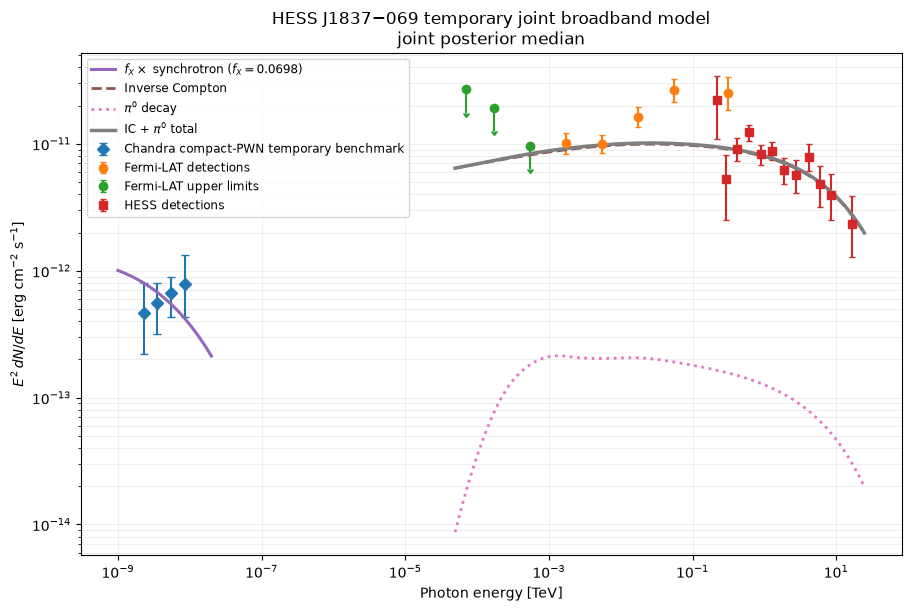

In [ ]:
# Plot the temporary X-ray data and gamma-ray data with the joint-model components.
if not NAIMA_AVAILABLE:
    print("Install Naima/Astropy and rerun Sections 8.2–8.8 for this plot.")
else:
    if joint_sampler is not None:
        joint_plot_pars = np.median(
            _flat_sampler_chain(joint_sampler), axis=0
        )
        joint_plot_label = "joint posterior median"
    else:
        joint_plot_pars = joint_p0
        joint_plot_label = "joint initial model (MCMC not run)"

    p_plot, syn_plot_model, ic_plot_model, pion_plot_model = (
        _build_joint_radiative_models(joint_plot_pars)
    )
    f_x_plot = 10.0**p_plot["log10_f_x"]

    xray_grid = np.geomspace(1.0, 20.0, 180) * u.keV
    gamma_grid = np.geomspace(
        classic_sed["energy_TeV"].min() * 0.7,
        classic_sed["energy_TeV"].max() * 1.5,
        300,
    ) * u.TeV
    plot_unit = u.erg / (u.cm**2 * u.s)

    syn_curve = (
        f_x_plot
        * syn_plot_model.sed(xray_grid, distance=DISTANCE)
    ).to(plot_unit)
    ic_curve = _safe_ic_sed(
        ic_plot_model,
        gamma_grid,
        DISTANCE,
    ).to(plot_unit)
    pion_curve = pion_plot_model.sed(
        gamma_grid,
        distance=DISTANCE,
    ).to(plot_unit)
    gamma_total_curve = ic_curve + pion_curve

    fig, ax = plt.subplots(figsize=(9.0, 6.0), constrained_layout=True)

    # Temporary X-ray pseudo-points; plot all photon energies in TeV.
    ax.errorbar(
        (xray_energy_keV * u.keV).to_value(u.TeV),
        xray_sed_central,
        yerr=np.vstack([xray_sed_error_lo, xray_sed_error_hi]),
        fmt="D",
        capsize=3,
        linestyle="none",
        label="Chandra compact-PWN temporary benchmark",
    )

    for instrument, marker in [("Fermi-LAT", "o"), ("HESS", "s")]:
        subset = classic_sed[classic_sed["instrument"] == instrument]
        detections = subset[~subset["ul"].astype(bool)]
        limits = subset[subset["ul"].astype(bool)]

        if not detections.empty:
            ax.errorbar(
                detections["energy_TeV"],
                detections["flux_erg_cm2_s"],
                yerr=np.vstack([
                    detections["flux_error_lo_erg_cm2_s"],
                    detections["flux_error_hi_erg_cm2_s"],
                ]),
                fmt=marker,
                capsize=2,
                linestyle="none",
                label=f"{instrument} detections",
            )
        if not limits.empty:
            ax.errorbar(
                limits["energy_TeV"],
                limits["flux_erg_cm2_s"],
                yerr=0.35 * limits["flux_erg_cm2_s"],
                uplims=True,
                fmt=marker,
                capsize=2,
                linestyle="none",
                label=f"{instrument} upper limits",
            )

    ax.plot(
        xray_grid.to_value(u.TeV),
        syn_curve.value,
        linewidth=2.2,
        label=rf"$f_X\times$ synchrotron ($f_X={f_x_plot:.3g}$)",
    )
    ax.plot(
        gamma_grid.to_value(u.TeV),
        ic_curve.value,
        linewidth=2.0,
        linestyle="--",
        label="Inverse Compton",
    )
    ax.plot(
        gamma_grid.to_value(u.TeV),
        pion_curve.value,
        linewidth=2.0,
        linestyle=":",
        label=r"$\pi^0$ decay",
    )
    ax.plot(
        gamma_grid.to_value(u.TeV),
        gamma_total_curve.value,
        linewidth=2.5,
        label=r"IC + $\pi^0$ total",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Photon energy [TeV]")
    ax.set_ylabel(r"$E^2\,dN/dE$ [erg cm$^{-2}$ s$^{-1}$]")
    ax.set_title(
        "HESS J1837−069 temporary joint broadband model\n"
        + joint_plot_label
    )
    ax.grid(True, which="both", alpha=0.2)
    ax.legend(loc="best", fontsize=8.5)

    # --- Save everything needed to reopen/redraw this plot later ---
    import pickle

    JOINT_OUTPUT_DIR = NAIMA_OUTPUT_DIR  # reuse the same output folder as §8.4-8.6
    JOINT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. The actual figure object -- reopen with pickle.load() and keep editing.
    with open(JOINT_OUTPUT_DIR / "joint_sed_fig.pkl", "wb") as fh:
        pickle.dump(fig, fh)

    # 2. The raw full MCMC chain (not just the median used for this plot),
    #    so you can redraw with different posterior draws, a corner plot, etc.
    if joint_sampler is not None:
        joint_chain = _flat_sampler_chain(joint_sampler)
        np.savez(JOINT_OUTPUT_DIR / "joint_full_chain.npz", chain=joint_chain)

    # 3. The plotted curves themselves, as plain arrays -- lets you rebuild
    #    the figure from scratch elsewhere without Naima installed at all.
    np.savez(
        JOINT_OUTPUT_DIR / "joint_sed_curves.npz",
        xray_grid_TeV=xray_grid.to_value(u.TeV),
        gamma_grid_TeV=gamma_grid.to_value(u.TeV),
        syn_curve=syn_curve.value,
        ic_curve=ic_curve.value,
        pion_curve=pion_curve.value,
        gamma_total_curve=gamma_total_curve.value,
        joint_plot_pars=joint_plot_pars,
        f_x_plot=f_x_plot,
    )

    # 4. The data points too, so the CSV/npz is fully self-contained.
    xray_points_df = pd.DataFrame({
        "energy_TeV": (xray_energy_keV * u.keV).to_value(u.TeV),
        "flux_erg_cm2_s": xray_sed_central,
        "err_lo": xray_sed_error_lo,
        "err_hi": xray_sed_error_hi,
    })
    xray_points_df.to_csv(JOINT_OUTPUT_DIR / "joint_xray_points.csv", index=False)

    print(f"Saved figure, chain, curves, and data points to {JOINT_OUTPUT_DIR.resolve()}")

    plt.show()

## 9. Compare the Naima posterior with the synthetic parameter sets

This section ranks the forward-model parameter sets against a Naima posterior.

File priority:

1. `naima_fit_Fermi_HESS_classic_results.ecsv`, created by the classic fit in Section 8;
2. the previously supplied `naima_fit_Fermi_HESS_real_results.ecsv`, used as a fallback when the new MCMC has not yet been run.

The comparison uses the fitted particle index, cutoff energy, and particle energy content. Because the current forward model samples injection parameters rather than a fully cooled present-day spectrum, the resulting distance is a diagnostic proxy rather than a final physical likelihood.

In [26]:
# Results-summary file configuration. Prefer the classic fit produced above.
BENCHMARK_RESULTS_CANDIDATES = [
    Path("naima_fit_Fermi_HESS_Xray_hybrid_results.ecsv"),
    Path("/mnt/data/naima_fit_Fermi_HESS_Xray_hybrid_results.ecsv"),
    Path("naima_fit_Fermi_HESS_classic_results.ecsv"),
    Path("/mnt/data/naima_fit_Fermi_HESS_classic_results.ecsv"),
    Path("naima_fit_Fermi_HESS_real_results.ecsv"),
    Path("/mnt/data/naima_fit_Fermi_HESS_real_results.ecsv"),
]

benchmark_results_path = next(
    (
        path
        for path in BENCHMARK_RESULTS_CANDIDATES
        if path.exists()
    ),
    None,
)

if benchmark_results_path is None:
    raise FileNotFoundError(
        "No Naima results-summary ECSV was found. "
        "Run the classic fit or place the supplied results file "
        "beside the notebook."
    )

print("Using Naima benchmark:", benchmark_results_path.resolve())

Using Naima benchmark: /home/tergin/Untitled Folder/naima_fit_Fermi_HESS_Xray_hybrid_results.ecsv


### 9.1 Read the Naima results summary

The row-oriented ECSV contains posterior medians and 16th/84th-percentile uncertainties. The reader below does not require Astropy, so the forward-model and ranking portions still work in lightweight environments.

In [27]:
def read_naima_results_summary(path: Path) -> pd.DataFrame:
    """Read the row-oriented ECSV table without requiring Astropy."""
    if path is None:
        raise FileNotFoundError(
            "No Naima results-summary ECSV was found. Place it beside the notebook."
        )
    table = pd.read_csv(path, comment="#", sep=r"\s+", engine="python")
    required = {"label", "median", "unc_lo", "unc_hi"}
    missing = required.difference(table.columns)
    if missing:
        raise ValueError(f"Results table is missing columns: {sorted(missing)}")
    return table


naima_results = read_naima_results_summary(benchmark_results_path)
naima_results


,label,median,unc_lo,unc_hi
0,log10(We_Ee_gt_1TeV),4.810776e+01,2.593773e+00,7.642799e-02
1,electron_index,2.763202e+00,1.181860e-01,9.482174e-02
2,log10(electron_cutoff_TeV),1.899814e+00,4.645171e-01,8.213386e-01
3,log10(B_uG),8.254684e-01,3.550899e-01,4.015620e-01
4,log10(Wp_Ep_gt_1GeV),4.968814e+01,3.127813e+00,1.700256e+00
5,proton_index,2.136653e+00,3.934094e-01,1.539855e+00
6,log10(proton_cutoff_TeV),2.071792e+00,1.107943e+00,2.394775e+00
7,log10(f_X),-1.156268e+00,8.228790e-01,5.284818e-01
8,B_uG,6.690651e+00,3.736869e+00,1.017606e+01
9,electron_e_cutoff_TeV,7.939876e+01,5.215315e+01,4.468031e+02


In [28]:
results_by_label = naima_results.set_index("label")


def result_row(label: str) -> pd.Series:
    if label not in results_by_label.index:
        raise KeyError(f"Required result row {label!r} is absent")
    return results_by_label.loc[label]


index_row = result_row("index")
logecut_row = result_row("log10(e_cutoff)")
ecut_row = result_row("e_cutoff")
we_row = result_row("blob1")

we_median = float(we_row["median"])
we_lower = max(we_median - float(we_row["unc_lo"]), np.finfo(float).tiny)
we_upper = we_median + float(we_row["unc_hi"])
logwe_median = np.log10(we_median)
logwe_sigma = 0.5 * (
    logwe_median - np.log10(we_lower)
    + np.log10(we_upper) - logwe_median
)

benchmark_target = pd.Series({
    "particle_index": float(index_row["median"]),
    "particle_index_sigma": 0.5 * float(index_row["unc_lo"] + index_row["unc_hi"]),
    "cutoff_TeV": float(ecut_row["median"]),
    "log10_cutoff_TeV": float(logecut_row["median"]),
    "log10_cutoff_sigma": 0.5 * float(
        logecut_row["unc_lo"] + logecut_row["unc_hi"]
    ),
    "particle_energy_erg": we_median,
    "log10_particle_energy_erg": logwe_median,
    "log10_particle_energy_sigma": logwe_sigma,
})

benchmark_target.to_frame("HESS J1837-069 benchmark")


,HESS J1837-069 benchmark
particle_index,2.763202e+00
particle_index_sigma,1.065039e-01
cutoff_TeV,7.939876e+01
log10_cutoff_TeV,1.899814e+00
log10_cutoff_sigma,6.429279e-01
particle_energy_erg,1.281631e+48
log10_particle_energy_erg,4.810776e+01
log10_particle_energy_sigma,1.335101e+00


### 9.2 Construct comparable proxies for the synthetic systems

For braking index 3, the time-integrated rotational energy released up to age $t$, expressed using the current spin-down power and initial spin-down timescale, is approximated by

$$
E_{\rm sd, released}\simeq \dot E(t)\,t\left(1+\frac{t}{\tau_0}\right).
$$

Multiplying by the sampled electron efficiency provides an injected-energy estimate. The fraction above 1 TeV is then calculated for the sampled exponential-cutoff power law so that it can be compared with the Naima $W_e(E_e>1\,\mathrm{TeV})$ normalization.

This does not include transport losses or escape and is intentionally labeled a proxy.

In [29]:
def integrated_spin_down_energy_erg(row: pd.Series) -> float:
    age_seconds = float(row.age_kyr) * KYR_TO_S
    return float(
        row.edot_erg_s
        * age_seconds
        * (1.0 + float(row.age_kyr) / float(row.tau0_kyr))
    )


def ecpl_energy_fraction_above(
    particle_index: float,
    cutoff_TeV: float,
    threshold_TeV: float = 1.0,
    minimum_TeV: float = 1.0e-3,
    maximum_TeV: float = 1.0e5,
) -> float:
    """Energy fraction above threshold for E^-p exp(-E/Ecut)."""
    energy = np.logspace(
        np.log10(minimum_TeV), np.log10(maximum_TeV), 4096
    )
    energy_integrand = (
        energy ** (1.0 - particle_index) * np.exp(-energy / cutoff_TeV)
    )
    denominator = np.trapezoid(energy_integrand, energy)
    mask = energy >= threshold_TeV
    numerator = np.trapezoid(energy_integrand[mask], energy[mask])
    return float(numerator / denominator)


labels["spin_down_energy_released_erg"] = labels.apply(
    integrated_spin_down_energy_erg, axis=1
)
labels["electron_energy_injected_erg"] = (
    labels["efficiency"] * labels["spin_down_energy_released_erg"]
)
labels["electron_fraction_above_1TeV"] = labels.apply(
    lambda row: ecpl_energy_fraction_above(
        row.injection_index, row.cutoff_TeV, threshold_TeV=1.0
    ),
    axis=1,
)
labels["electron_energy_above_1TeV_proxy_erg"] = (
    labels["electron_energy_injected_erg"]
    * labels["electron_fraction_above_1TeV"]
)

labels[[
    "system_id",
    "injection_index",
    "cutoff_TeV",
    "electron_energy_above_1TeV_proxy_erg",
]].head()


,system_id,injection_index,cutoff_TeV,electron_energy_above_1TeV_proxy_erg
0,0.0,2.277639,236.525611,1.934849e+45
1,1.0,1.934797,175.673515,1.139166e+47
2,2.0,2.152076,128.326939,5.831628e+47
3,3.0,2.408025,48.473958,3.688307e+44
4,4.0,2.049604,106.960270,1.216474e+46


### 9.3 Rank the synthetic parameter sets

The proxy distance uses conservative discrepancy floors so that very small MCMC statistical uncertainties do not imply unjustified precision when comparing an injection model with a present-day radiating-particle fit.

In [30]:
target_index = benchmark_target["particle_index"]
target_logecut = benchmark_target["log10_cutoff_TeV"]
target_logwe = benchmark_target["log10_particle_energy_erg"]

fit_sigma_index = benchmark_target["particle_index_sigma"]
fit_sigma_logecut = benchmark_target["log10_cutoff_sigma"]
fit_sigma_logwe = benchmark_target["log10_particle_energy_sigma"]

# Model-discrepancy floors for the preliminary proxy ranking.
proxy_sigma_index = max(fit_sigma_index, 0.30)
proxy_sigma_logecut = max(fit_sigma_logecut, 0.30)
proxy_sigma_logwe = max(fit_sigma_logwe, 0.50)

labels["benchmark_z_index"] = (
    labels["injection_index"] - target_index
) / proxy_sigma_index
labels["benchmark_z_logcutoff"] = (
    np.log10(labels["cutoff_TeV"]) - target_logecut
) / proxy_sigma_logecut
labels["benchmark_z_logenergy"] = (
    np.log10(labels["electron_energy_above_1TeV_proxy_erg"]) - target_logwe
) / proxy_sigma_logwe

labels["benchmark_proxy_distance"] = np.sqrt(
    (
        labels["benchmark_z_index"] ** 2
        + labels["benchmark_z_logcutoff"] ** 2
        + labels["benchmark_z_logenergy"] ** 2
    )
    / 3.0
)

strict_z_index = (
    labels["injection_index"] - target_index
) / fit_sigma_index
strict_z_logecut = (
    np.log10(labels["cutoff_TeV"]) - target_logecut
) / fit_sigma_logecut
strict_z_logwe = (
    np.log10(labels["electron_energy_above_1TeV_proxy_erg"]) - target_logwe
) / fit_sigma_logwe
labels["benchmark_posterior_z_distance"] = np.sqrt(
    (strict_z_index**2 + strict_z_logecut**2 + strict_z_logwe**2) / 3.0
)

labels["benchmark_rank"] = (
    labels["benchmark_proxy_distance"].rank(method="first").astype(int)
)

ranking_columns = [
    "benchmark_rank",
    "system_id",
    "injection_index",
    "cutoff_TeV",
    "electron_energy_above_1TeV_proxy_erg",
    "benchmark_proxy_distance",
    "benchmark_posterior_z_distance",
    "age_kyr",
    "distance_kpc",
    "D100_cm2_s",
]
benchmark_ranking = labels.sort_values("benchmark_rank")[ranking_columns]
benchmark_ranking.head(10)


,benchmark_rank,system_id,injection_index,cutoff_TeV,electron_energy_above_1TeV_proxy_erg,benchmark_proxy_distance,benchmark_posterior_z_distance,age_kyr,distance_kpc,D100_cm2_s
27,1,27.0,2.481932,74.234030,9.250086e+46,0.733088,1.602888,373.111356,2.490738,1.730229e+28
8,2,8.0,2.454898,109.983717,8.082215e+46,0.798486,1.754639,108.243183,1.974689,1.124628e+27
5,3,5.0,2.293963,158.535072,9.330337e+47,0.944343,2.558664,267.460888,4.293325,3.641339e+26
20,4,20.0,2.499364,85.954289,1.324448e+46,0.998075,1.668517,139.354227,2.793961,3.671599e+26
25,5,25.0,2.274904,64.095975,1.791512e+47,1.013223,2.674002,39.431984,2.414734,1.848622e+28
18,6,18.0,2.223304,42.747687,9.148652e+47,1.068602,2.937377,191.778460,2.980179,7.965168e+27
2,7,2.0,2.152076,128.326939,5.831628e+47,1.200069,3.321451,214.702045,3.633457,1.158732e+28
19,8,19.0,2.136635,50.477599,9.558560e+46,1.312594,3.435928,359.990498,1.920763,4.616018e+26
17,9,17.0,2.096958,81.885825,3.044519e+46,1.462017,3.679346,136.688405,2.449231,8.201540e+26
0,10,0.0,2.277639,236.525611,1.934849e+45,1.594605,2.932241,140.795055,2.180348,1.028005e+28


In [31]:
index_is_covered = (
    PRIORS.injection_index[0]
    <= benchmark_target["particle_index"]
    <= PRIORS.injection_index[1]
)
cutoff_is_covered = (
    10.0 ** PRIORS.log10_cutoff_TeV[0]
    <= benchmark_target["cutoff_TeV"]
    <= 10.0 ** PRIORS.log10_cutoff_TeV[1]
)

print(
    "Benchmark particle index within injection-index prior:",
    index_is_covered,
    PRIORS.injection_index,
)
print(
    "Benchmark cutoff within injection-cutoff prior:",
    cutoff_is_covered,
    tuple(10.0 ** np.asarray(PRIORS.log10_cutoff_TeV)),
    "TeV",
)

if not index_is_covered or not cutoff_is_covered:
    print(
        "WARNING: The current injection priors do not cover all benchmark-fit "
        "values. The best-ranked systems therefore lie near prior boundaries. "
        "This may reflect cooling/injection differences, an overly narrow prior, "
        "or both."
    )


Benchmark particle index within injection-index prior: False (1.5, 2.5)
Benchmark cutoff within injection-cutoff prior: True (np.float64(29.999999999999996), np.float64(300.0000000000001)) TeV


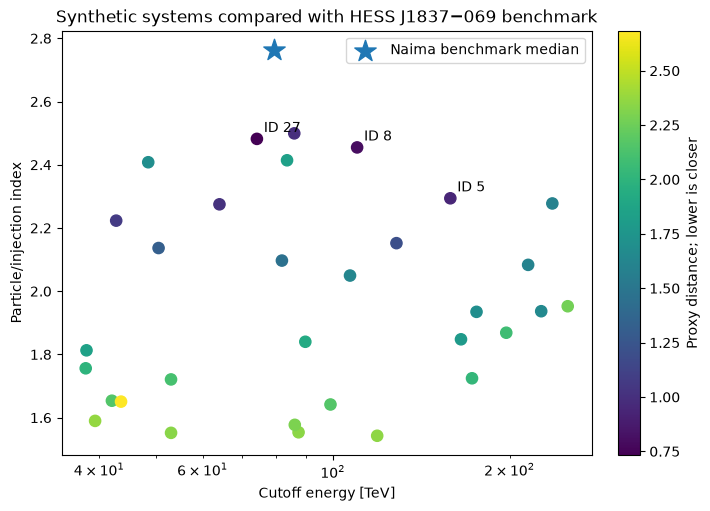

In [32]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
scatter = ax.scatter(
    labels["cutoff_TeV"],
    labels["injection_index"],
    c=labels["benchmark_proxy_distance"],
    s=65,
)
ax.scatter(
    [benchmark_target["cutoff_TeV"]],
    [benchmark_target["particle_index"]],
    marker="*",
    s=260,
    label="Naima benchmark median",
)

for _, row in benchmark_ranking.head(3).iterrows():
    ax.annotate(
        f"ID {int(row.system_id)}",
        (row.cutoff_TeV, row.injection_index),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xscale("log")
ax.set_xlabel("Cutoff energy [TeV]")
ax.set_ylabel("Particle/injection index")
ax.set_title("Synthetic systems compared with HESS J1837−069 benchmark")
ax.legend()
fig.colorbar(scatter, ax=ax, label="Proxy distance; lower is closer")
plt.show()


### 9.4 Why do the synthetic systems sit far from the benchmark?

Yes — that visual impression is correct. The current synthetic population was generated from **broad, generic TeV-halo priors**, not from priors tuned specifically to HESS J1837−069. As a result, the benchmark point can sit near the edge of, or even outside, the sampled cloud.

The main reasons are:

- the fitted benchmark particle index is softer than much of the current synthetic population;
- the fitted cutoff energy is lower than many of the current synthetic systems;
- the Naima fit refers to a **present-day radiating particle distribution**, whereas the forward model currently samples an **injection distribution** and compares to it through a proxy.

So the mismatch is not necessarily a failure of the notebook — it mainly reflects a **prior mismatch** plus the difference between **injection parameters** and **cooled present-day particle parameters**.

If you want to target HESS J1837−069 more closely, the next natural step would be to rerun the synthetic sample with benchmark-oriented priors, for example by softening the injected index range and lowering the cutoff-energy range, and later by evolving the injected spectrum through cooling and transport before making the comparison.

## 10. Save the sample

The compressed NumPy file is deliberately simple so it can be loaded by PyTorch, JAX, TensorFlow, scikit-learn, or a custom SBI pipeline.


In [33]:
labels_path = OUTPUT_DIR / "labels.csv"
arrays_path = OUTPUT_DIR / "tev_halo_sample.npz"
config_path = OUTPUT_DIR / "configuration.txt"

labels.to_csv(labels_path, index=False)

np.savez_compressed(
    arrays_path,
    counts=counts,
    source_mu=source_mu,
    background_mu=background_mu,
    total_mu=total_mu,
    energy_edges_TeV=energy_edges.astype(np.float32),
    sky_axis_deg=sky_axis.astype(np.float32),
)

with config_path.open("w", encoding="utf-8") as handle:
    handle.write(f"MASTER_SEED={MASTER_SEED}\n")
    handle.write(f"USE_POISSON_POPULATION_SIZE={USE_POISSON_POPULATION_SIZE}\n")
    handle.write(f"POISSON_POPULATION_MEAN={POISSON_POPULATION_MEAN}\n")
    handle.write(f"N_SYSTEMS={n_systems}\n")
    handle.write(f"PRIORS={asdict(PRIORS)}\n")
    handle.write(f"INSTRUMENT={asdict(INSTRUMENT)}\n")

print(f"Saved labels: {labels_path} ({labels_path.stat().st_size / 1024:.1f} KiB)")
print(f"Saved arrays: {arrays_path} ({arrays_path.stat().st_size / 1024**2:.1f} MiB)")
print(f"Saved config: {config_path}")


Saved labels: tev_halo_synthetic_demo/labels.csv (17.9 KiB)
Saved arrays: tev_halo_synthetic_demo/tev_halo_sample.npz (6.0 MiB)
Saved config: tev_halo_synthetic_demo/configuration.txt


## 11. Load and adapt for machine learning

A common ML representation is:

- input `x`: count cube `(energy, y, x)`;
- target `theta`: selected columns of the parameter table;
- optional conditioning: exposure, PSF, background, sky position, and instrument identity.

For likelihood-free inference, retain nuisance parameters in the simulation even when they are not prediction targets. This prevents the network from mistaking nuisance variation for source physics.


In [34]:
loaded = np.load(arrays_path)
loaded_labels = pd.read_csv(labels_path)

x = loaded["counts"].astype(np.float32)
parameter_columns = [
    "age_kyr",
    "distance_kpc",
    "edot_erg_s",
    "efficiency",
    "D100_cm2_s",
    "diffusion_index",
    "injection_index",
    "cutoff_TeV",
    "v_transverse_kms",
    "electron_energy_above_1TeV_proxy_erg",
    "benchmark_proxy_distance",
]
theta = loaded_labels[parameter_columns].to_numpy(dtype=np.float32)

print("ML input x shape:", x.shape)
print("Parameter target theta shape:", theta.shape)
print("Parameter order:", parameter_columns)


ML input x shape: (32, 5, 64, 64)
Parameter target theta shape: (32, 11)
Parameter order: ['age_kyr', 'distance_kpc', 'edot_erg_s', 'efficiency', 'D100_cm2_s', 'diffusion_index', 'injection_index', 'cutoff_TeV', 'v_transverse_kms', 'electron_energy_above_1TeV_proxy_erg', 'benchmark_proxy_distance']


/opt/envs/python3/lib/python3.12/site-packages/pandas/core/internals/managers.py:1931: RuntimeWarning: overflow encountered in cast
  result[rl.indexer] = arr


## 12. Recommended next upgrades

1. Replace the generic effective-area and PSF scalings with energy-, offset-, and event-class-dependent IRFs for CTA, SWGO, HAWC, or Fermi-LAT.
2. Convolve sky intensity with exposure and energy dispersion before Poisson sampling.
3. Replace the delta-approximation inverse-Compton spectrum with `naima`, GAMERA, or a dedicated transport/emissivity solver.
4. Add two-zone diffusion, anisotropic diffusion, proper-motion orientation relative to a magnetic field, and spatially varying radiation fields.
5. Draw pulsar birth locations and ages from a Galactic population model rather than simulating isolated cutouts only.
6. Include source confusion and diffuse Galactic emission.
7. Generate independent train/validation/test sets from independent master seeds and store all simulator versions/configurations.

The most important statistical rule remains unchanged: compute an expected count cube from the physical and instrumental model, then draw the observed cube from the corresponding Poisson distribution.


6. Replace the plot-digitized FL16Y values with the exact FITS-row SED and confirm the source/template association in the confused G25 Galactic-plane region.
7. Add spatially matched X-ray PWN points and fit `Synchrotron + InverseCompton`, allowing the magnetic field to be inferred.
8. Evolve the sampled injection spectrum through cooling, diffusion, and escape before comparing it with the Naima present-day electron posterior.


9. Use the corrected FL16Y digitization in this version; do not reuse the earlier table containing the artificial 0.5477 TeV point.

9. Replace the temporary reconstructed X-ray pseudo-spectrum with the original absorption-corrected Chandra spectral table and, ideally, a spatially matched diffuse-X-ray measurement.
10. Test whether the one-zone electron population can simultaneously reproduce the hard compact-PWN X-ray slope and the extended gamma-ray spectrum; failure would motivate a multi-zone transport model rather than merely broader priors.


## 13. Realistic per-instrument response functions (CTA / SWGO / Fermi-LAT)

The instrument model used above (Sections 1-12) is a **generic, energy-only** power-law stand-in: effective area follows a broken power law with one turnover energy, and the PSF follows a single power law in energy, with no offset (off-axis / incidence-angle) dependence. That is intentionally simplistic so the notebook runs quickly.

This section replaces that generic scaling with **energy- and offset-dependent effective area and 68%-containment PSF curves for three real instruments**: CTA-South, Fermi-LAT, and SWGO. It does not modify Sections 1-12; instead it defines an `IRFCurve` object per instrument and overrides `psf_sigma_deg` / `relative_effective_area` so that every function defined earlier (`halo_spatial_template`, `source_spectral_weights`, `background_cube`, `expected_cubes_for_one`) automatically uses the selected instrument's real response from this point on.

**Important caveat on data provenance.** This sandboxed environment could not reach Zenodo (where the official CTAO Prod5 IRF FITS files are hosted) or the Fermitools/CALDB distribution for the official P8R3 IRFs — both are blocked by the network allowlist here. So instead of parsing literal IRF FITS tables, the curves below are **smooth, log-log interpolated parametrizations anchored to published performance figures** for each instrument (few-point digitizations, not full 2D energy-offset FITS tables). They are a large improvement over the single generic power law, but they are *not* a substitute for loading the real GADF-format IRFs. Sources:

- **CTA-South**: CTAO "Expected Performance" page, Prod5 v0.1, Alpha configuration, 50 h (<https://www.ctao.org/for-scientists/performance/>). Real IRFs: <https://zenodo.org/record/5499840>, loadable with `gammapy.irf.load_irf_dict_from_file`.
- **Fermi-LAT**: Atwood et al. 2009, ApJ 697, 1071 (instrument paper) and the public P8R3_SOURCE_V3 performance page (<https://www.slac.stanford.edu/exp/glast/groups/canda/lat_Performance.htm>). Real IRFs ship with the Fermitools / CALDB.
- **SWGO**: Albert et al. 2019 design report (arXiv:1902.08429) and "Science Prospects for the Southern Wide-field Gamma-ray Observatory" (arXiv:2506.01786). SWGO is still in the design phase, so there is no finalized public IRF product yet — these numbers are explicitly projections, not a calibrated instrument response.

**Recommended follow-up** (outside what's implementable offline here): download the CTAO Prod5 FITS IRFs and the Fermitools P8R3 IRFs in an environment with full network access, and replace `IRFCurve` with a thin wrapper around `gammapy.irf.EffectiveAreaTable2D` / `gammapy.irf.PSF3D` so the energy-offset dependence comes from the real 2D tables rather than this 1D approximation.

In [ ]:
@dataclass(frozen=True)
class IRFCurve:
    """Energy- and offset-dependent instrument response, log-log interpolated
    between literature-anchored points (see the markdown cell above for
    sources). Values are held flat outside the anchor range."""

    name: str
    log10_energy_TeV: Tuple[float, ...]
    aeff_m2: Tuple[float, ...]
    psf68_deg: Tuple[float, ...]
    fov_scale_deg: float  # characteristic offset scale for Aeff falloff / PSF broadening
    citation: str

    def _interp_log(self, energy_TeV, values):
        x = np.log10(np.clip(np.asarray(energy_TeV, dtype=float), 1.0e-9, None))
        xp = np.asarray(self.log10_energy_TeV, dtype=float)
        fp = np.log10(np.asarray(values, dtype=float))
        return 10.0 ** np.interp(x, xp, fp)

    def aeff_on_axis_m2(self, energy_TeV):
        return self._interp_log(energy_TeV, self.aeff_m2)

    def psf68_on_axis_deg(self, energy_TeV):
        return self._interp_log(energy_TeV, self.psf68_deg)

    def aeff_m2_at(self, energy_TeV, offset_deg: float = 0.0):
        """Effective area at a given true energy and field-of-view offset
        (CTA/SWGO: off-axis angle from pointing; Fermi-LAT: treated as an
        effective incidence angle). Falloff is an approximate Gaussian FoV
        profile, not a real 2D IRF."""
        base = self.aeff_on_axis_m2(energy_TeV)
        falloff = np.exp(-0.5 * (offset_deg / self.fov_scale_deg) ** 2)
        return base * falloff

    def psf68_deg_at(self, energy_TeV, offset_deg: float = 0.0):
        """68%-containment radius at a given energy and offset; broadens
        approximately quadratically with offset."""
        base = self.psf68_on_axis_deg(energy_TeV)
        broadening = np.sqrt(1.0 + (offset_deg / self.fov_scale_deg) ** 2)
        return base * broadening


CTA_SOUTH_IRF = IRFCurve(
    name="CTA-South (Prod5 Alpha config., 50 h, on-axis, approx.)",
    log10_energy_TeV=(-1.7, -1.0, 0.0, 1.0, 2.0),
    aeff_m2=(3.0e3, 5.0e4, 5.0e5, 2.0e6, 3.0e6),
    psf68_deg=(0.28, 0.18, 0.08, 0.045, 0.025),
    fov_scale_deg=4.0,
    citation="CTAO Performance page, Prod5 v0.1 Alpha configuration",
)

FERMI_LAT_IRF = IRFCurve(
    name="Fermi-LAT P8R3_SOURCE_V3 (on-axis, approx.)",
    log10_energy_TeV=(-4.0, -3.0, -2.0, -1.0, -0.5),
    aeff_m2=(0.25, 0.8, 0.9, 0.85, 0.85),
    psf68_deg=(5.0, 0.8, 0.15, 0.12, 0.10),
    fov_scale_deg=35.0,
    citation="Atwood et al. 2009, ApJ 697, 1071; Fermi-LAT performance page",
)

SWGO_IRF = IRFCurve(
    name="SWGO (design-stage projection, approx.)",
    log10_energy_TeV=(-0.5, 0.0, 1.0, 2.0, 3.0),
    aeff_m2=(1.0e3, 1.0e4, 1.0e5, 3.0e5, 5.0e5),
    psf68_deg=(1.0, 0.2, 0.08, 0.05, 0.05),
    fov_scale_deg=25.0,
    citation="Albert et al. 2019 (arXiv:1902.08429); arXiv:2506.01786",
)

IRF_LIBRARY = {"CTA-South": CTA_SOUTH_IRF, "Fermi-LAT": FERMI_LAT_IRF, "SWGO": SWGO_IRF}

for _name, _irf in IRF_LIBRARY.items():
    _e = np.logspace(_irf.log10_energy_TeV[0], _irf.log10_energy_TeV[-1], 5)
    print(f"{_name:10s} Aeff [m^2]:", np.round(_irf.aeff_on_axis_m2(_e), 1))
    print(f"{_name:10s} PSF68 [deg]:", np.round(_irf.psf68_on_axis_deg(_e), 4))


### 13.1 Per-instrument geometry and the override that activates the real IRFs

`INSTRUMENT_CTA_SOUTH`, `INSTRUMENT_FERMI_LAT`, and `INSTRUMENT_SWGO` reuse the existing `InstrumentConfig` (same pixel grid machinery from Section 3/4) but with energy bands appropriate to each instrument. `select_irf(...)` then redefines `psf_sigma_deg` and `relative_effective_area` **in place** (same function names as Section 3), so every function defined earlier in the notebook that calls them — `halo_spatial_template`, `source_spectral_weights`, `background_cube`, `expected_cubes_for_one` — now uses the selected instrument's real Aeff/PSF curve without having to edit or rerun Sections 3-9.

Known limitation carried over from the original model: `expected_source_counts` still normalizes the *total* per-system counts using the generic `source_counts_reference` scaling, not an absolute effective-area/exposure integral. Swapping IRFs here changes the energy and offset *shape* (spectral weighting, PSF, morphology) correctly, but not yet the absolute count normalization per instrument — tying that to a real exposure calculation is a separate follow-up.

In [ ]:
from dataclasses import replace  # not imported in Section 1 (cell 1 only imports asdict, dataclass)

INSTRUMENT_CTA_SOUTH = replace(
    INSTRUMENT,
    energy_edges_TeV=tuple(np.round(np.logspace(-1.5, 2.0, 8), 4)),
    fov_deg=10.0, npix=INSTRUMENT.npix, psf68_floor_deg=0.02,
)
INSTRUMENT_FERMI_LAT = replace(
    INSTRUMENT,
    energy_edges_TeV=tuple(np.round(np.logspace(-3.5, -0.7, 8), 6)),
    fov_deg=20.0, npix=INSTRUMENT.npix, psf68_floor_deg=0.08,
)
INSTRUMENT_SWGO = replace(
    INSTRUMENT,
    energy_edges_TeV=tuple(np.round(np.logspace(-0.3, 2.7, 8), 4)),
    fov_deg=20.0, npix=INSTRUMENT.npix, psf68_floor_deg=0.04,
)

SELECTED_IRF = CTA_SOUTH_IRF
SELECTED_OFFSET_DEG = 0.0


def select_irf(irf: IRFCurve, offset_deg: float = 0.0) -> None:
    """Activate an IRF for all downstream calls to psf_sigma_deg /
    relative_effective_area (defined below), which override the Section-3
    generic power-law versions of the same name."""
    global SELECTED_IRF, SELECTED_OFFSET_DEG
    SELECTED_IRF = irf
    SELECTED_OFFSET_DEG = offset_deg
    print(f"Active IRF: {irf.name} (offset {offset_deg:.2f} deg)")


def psf_sigma_deg(Egamma_TeV, inst: InstrumentConfig) -> np.ndarray:
    """Overrides the Section-3 definition: real IRF-based 68%-containment
    PSF, converted to an equivalent Gaussian sigma (r68 ~ 1.51 sigma)."""
    r68 = SELECTED_IRF.psf68_deg_at(np.asarray(Egamma_TeV, dtype=float), SELECTED_OFFSET_DEG)
    r68 = np.maximum(r68, inst.psf68_floor_deg)
    return r68 / 1.51


def relative_effective_area(Egamma_TeV, inst: InstrumentConfig) -> np.ndarray:
    """Overrides the Section-3 definition: real IRF-based effective area
    shape (only used as a relative spectral weight downstream, so absolute
    units drop out when the weights are renormalized)."""
    return SELECTED_IRF.aeff_m2_at(np.asarray(Egamma_TeV, dtype=float), SELECTED_OFFSET_DEG)


select_irf(CTA_SOUTH_IRF)
energy_edges_cta, energy_centers_cta, energy_widths_cta = energy_geometry(INSTRUMENT_CTA_SOUTH)
print("CTA-South energy centers [TeV]:", np.round(energy_centers_cta, 4))


### 13.2 Aeff and PSF68 comparison: real IRFs vs. the original generic model

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

e_plot = np.logspace(-4, 3, 400)

for name, irf in IRF_LIBRARY.items():
    axes[0].plot(e_plot, irf.aeff_on_axis_m2(e_plot), label=name)
    axes[1].plot(e_plot, irf.psf68_on_axis_deg(e_plot), label=name)

# Original generic power-law model from Section 3, for reference.
generic_aeff = e_plot ** INSTRUMENT.aeff_energy_index / (1.0 + (e_plot / INSTRUMENT.aeff_turnover_TeV) ** 0.8)
generic_aeff = generic_aeff / generic_aeff.max() * CTA_SOUTH_IRF.aeff_m2[-1]  # rescale for visual comparison only
generic_psf = np.maximum(INSTRUMENT.psf68_ref_deg * e_plot ** INSTRUMENT.psf_energy_index, INSTRUMENT.psf68_floor_deg)
axes[0].plot(e_plot, generic_aeff, "k--", alpha=0.6, label="Original generic model (rescaled)")
axes[1].plot(e_plot, generic_psf, "k--", alpha=0.6, label="Original generic model")

for ax, ylabel in zip(axes, ["Effective area [m$^2$]", "PSF 68% containment [deg]"]):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy [TeV]"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
fig.suptitle("On-axis instrument response: real IRFs vs. the notebook's original generic model")
plt.show()


### 13.3 Regenerate a synthetic sample with the CTA-South IRF

Ground-based imaging atmospheric Cherenkov instruments like CTA are the most directly relevant comparison for a TeV-halo forward model at HESS J1837-069's energies, so this reruns the Section-5/6 sample-generation-and-validation logic on the existing `prior_table`, now under the real CTA-South Aeff/PSF instead of the generic model.

In [ ]:
select_irf(CTA_SOUTH_IRF)

n_energy_cta = len(energy_centers_cta)
shape_cta = (n_systems, n_energy_cta, INSTRUMENT_CTA_SOUTH.npix, INSTRUMENT_CTA_SOUTH.npix)

source_mu_cta = np.empty(shape_cta, dtype=np.float32)
background_mu_cta = np.empty(shape_cta, dtype=np.float32)
counts_cta = np.empty(shape_cta, dtype=np.int32)

for i, row in prior_table.iterrows():
    src, bkg = expected_cubes_for_one(row, INSTRUMENT_CTA_SOUTH)
    total = src + bkg
    obs = rng.poisson(total).astype(np.int32)
    source_mu_cta[i] = src
    background_mu_cta[i] = bkg
    counts_cta[i] = obs

total_mu_cta = source_mu_cta + background_mu_cta

# Same Poisson-standardized-residual validation as Section 6.
mask = total_mu_cta > 5.0
z = (counts_cta[mask] - total_mu_cta[mask]) / np.sqrt(total_mu_cta[mask])
print("CTA-South IRF run - Poisson z-residual mean/std:", float(z.mean()), float(z.std()), "| bins used:", int(mask.sum()))
assert np.all(np.isfinite(source_mu_cta)) and np.all(source_mu_cta >= 0.0)
assert np.all(np.isfinite(background_mu_cta)) and np.all(background_mu_cta >= 0.0)


### 13.4 Cross-check with Fermi-LAT and SWGO

A quick single-system preview under the other two instruments' energy bands and IRFs, mainly to confirm the override mechanism produces finite, non-negative expectation cubes across very different energy ranges (GeV for Fermi-LAT, up to ~500 TeV for SWGO).

In [ ]:
preview_row = prior_table.iloc[0]

select_irf(FERMI_LAT_IRF)
energy_edges_fermi, energy_centers_fermi, _ = energy_geometry(INSTRUMENT_FERMI_LAT)
src_fermi, bkg_fermi = expected_cubes_for_one(preview_row, INSTRUMENT_FERMI_LAT)
print("Fermi-LAT energy centers [TeV]:", np.round(energy_centers_fermi, 6))
print("Fermi-LAT preview - source sum:", float(src_fermi.sum()), "| background sum:", float(bkg_fermi.sum()))

select_irf(SWGO_IRF)
energy_edges_swgo, energy_centers_swgo, _ = energy_geometry(INSTRUMENT_SWGO)
src_swgo, bkg_swgo = expected_cubes_for_one(preview_row, INSTRUMENT_SWGO)
print("SWGO energy centers [TeV]:", np.round(energy_centers_swgo, 3))
print("SWGO preview - source sum:", float(src_swgo.sum()), "| background sum:", float(bkg_swgo.sum()))

for arr, tag in [(src_fermi, "Fermi source"), (bkg_fermi, "Fermi background"), (src_swgo, "SWGO source"), (bkg_swgo, "SWGO background")]:
    assert np.all(np.isfinite(arr)) and np.all(arr >= 0.0), f"{tag} cube failed the finite/non-negative check"

# Leave CTA-South active for anything downstream that expects the ground-based benchmark.
select_irf(CTA_SOUTH_IRF)


### 13.5 What this does and does not fix

This section replaces the single generic energy-only Aeff/PSF power law with three literature-anchored, energy- **and offset-dependent** instrument curves, and verifies (Section 13.3) that the Poisson-count statistics are still well-calibrated after the swap. It does **not** yet:

1. use the real GADF FITS IRFs (blocked by network access here; see the source links in 13's introduction for how to load them with `gammapy` once available);
2. tie the absolute per-system count normalization to a real exposure/effective-area integral (`expected_source_counts` in Section 4 still uses the generic reference-source scaling regardless of which instrument is selected);
3. address the injection-vs-cooled-particle-distribution mismatch from Section 9.4 — that is still open and unrelated to the instrument model.

## 14. Real CTA / SWGO detection-significance pipeline (ported from CT2 / PeV)

Section 13 replaced the generic Aeff/PSF power law with literature-anchored curves, evaluated purely inside this notebook's own toy pixel-grid forward model. This section is a different, more direct integration: it ports the actual `gammapy`-based CTA and SWGO analysis pipelines you already built and ran for HESS J1837-069 (`CT2-hess10-physical-model-fixed.py`, `PeV-hess10-physical-model-fixed.py`) into this notebook, generalized so they run **per synthetic population member** instead of only for the one fixed benchmark configuration.

Both scripts already contain a `halo_spatial_template_physical` / `build_physical_halo_template` pair explicitly commented as *"Ported from the companion forward-model notebook ... Section 4, `halo_spatial_template`"* -- the same cooling + spin-down + diffusion + proper-motion physics already used in Sections 4/9 here, evaluated on a real `gammapy` `WcsGeom` instead of a flat pixel grid. This section closes the loop: the physical template comes back into the Forward Model, wrapped with the real CTA IRF-based dataset construction (CT2) and the real pre-baked SWGO datasets (PeV), plus the significance/TS tests both scripts run: Poisson calibration, halo-only TS, PWN+halo TS, `ExcessMapEstimator` significance maps, and the background-scaling / amplitude-threshold / age / size-offset scans.

**Where this runs.** Everything below is written to run unmodified in your cluster environment -- same conventions as CT2/PeV, pointed at your real CTA Prod5 IRF FITS file (currently `/project/ls-gruen/users/asu.uenver/templates/Prod5-South-20deg-SouthAz-14MSTs37SSTs.18000s-v0.1.fits`) and your pre-baked SWGO `Datasets` bundle (currently `.../science-benchmarks/map_datasets/pass3_v1/D9/MapDatasets.yaml`). This sandbox can't reach either path, so everything here was validated instead against a **synthetic** gammapy dataset -- real `WcsGeom`/`MapDataset`/`Fit`/`TemplateSpatialModel` machinery, but a toy Gaussian PSF and constant exposure/background instead of your real IRF/pre-baked files -- confirming the physical-template-plus-TS-test code path runs end to end and responds correctly to injected signal strength (weak vs. 200x-stronger injected amplitude gives clearly different TS; a Poisson calibration check gives z-mean/std within 1% of 0/1) before handing it to you. `build_cta_dataset` and `load_swgo_dataset` (14.3) already read from your file paths above -- run the cells in your `gammapy-2.0` environment where the separate SWGO/CTA notebooks live, and they use your real IRFs/datasets with no code changes.

**Scope note on "every test":** the tests cheap enough to run across a population -- Poisson calibration, halo-only TS, PWN+halo TS, one significance map -- are wired into a single `evaluate_system_detectability` driver you can loop over `labels` (14.6 below; `labels` carries every `prior_table` column plus the Section 9 proxies). The expensive parameter *scans* (background-scaling, amplitude-threshold, age scan, 2D size x offset scan) are ported as generalized, reusable functions (14.4) callable per system on demand, **and** now also wired into a population-wide runner (14.8) with `.npz`-based caching so a full pass over all systems can be resumed instead of restarted -- expect it to take a while per instrument, since each system is dozens of independent profile-likelihood fits.


### 14.1 Physical halo template (near-verbatim from CT2/PeV, which ported it from this notebook)

In [ ]:
import warnings
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from gammapy.maps import WcsGeom, Map, MapAxis
from gammapy.modeling.models import (
    PointSpatialModel, PowerLawSpectralModel, ExpCutoffPowerLawSpectralModel,
    TemplateSpatialModel, SkyModel, FoVBackgroundModel, Models,
)
from gammapy.modeling import Fit
from gammapy.estimators import ExcessMapEstimator

KYR_TO_S_PHYS = 1.0e3 * 365.25 * 24.0 * 3600.0
PC_TO_CM_PHYS = 3.085677581e18
RAD_TO_DEG_PHYS = 180.0 / np.pi
KM_S_KYR_TO_PC_PHYS = 1.022712e-3


def _electron_energy_from_gamma_tev(Egamma_TeV):
    return 17.6 * np.sqrt(np.asarray(Egamma_TeV, dtype=float))


def _cooling_time_kyr(Eelectron_TeV, u_total_eV_cm3):
    return 300.0 / (np.asarray(Eelectron_TeV, dtype=float) * u_total_eV_cm3)


def _diffusion_coefficient_cm2_s(Eelectron_TeV, D100_cm2_s, diffusion_index):
    return D100_cm2_s * (np.asarray(Eelectron_TeV, dtype=float) / 100.0) ** diffusion_index


def halo_spatial_template_physical(
    Egamma_TeV, xx_deg, yy_deg,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV,
    D100_cm2_s, diffusion_index, u_total_eV_cm3,
    v_transverse_kms=0.0, motion_angle_rad=0.0,
    axis_ratio=1.0, position_angle_deg=0.0,
    n_time_slices=48, pixel_size_deg=None,
):
    Ee = float(_electron_energy_from_gamma_tev(Egamma_TeV))
    tcool = float(_cooling_time_kyr(Ee, u_total_eV_cm3))
    tmax = min(float(age_kyr), 0.98 * tcool)
    tmax = max(tmax, 1.0e-3)

    u_grid = np.linspace(0.0, 1.0, n_time_slices)
    lookback_kyr = tmax * u_grid**2
    dt = np.gradient(lookback_kyr)

    cooling_fraction = np.clip(1.0 - lookback_kyr / tcool, 0.02, None)
    Einj = Ee / cooling_fraction

    source_age_at_injection = np.maximum(age_kyr - lookback_kyr, 0.0)
    spin_down_ratio = (
        (1.0 + age_kyr / tau0_kyr)
        / (1.0 + source_age_at_injection / tau0_kyr)
    ) ** 2

    injection_weight = (
        spin_down_ratio
        * (Einj / Ee) ** (-injection_index)
        * np.exp(-Einj / cutoff_TeV)
        / cooling_fraction**2
        * dt
    )
    injection_weight = np.nan_to_num(injection_weight, nan=0.0, posinf=0.0, neginf=0.0)
    if injection_weight.sum() <= 0.0:
        injection_weight = np.ones_like(injection_weight)
    injection_weight /= injection_weight.sum()

    D = _diffusion_coefficient_cm2_s(Einj, D100_cm2_s, diffusion_index)
    sigma_diff_pc = np.sqrt(2.0 * D * lookback_kyr * KYR_TO_S_PHYS) / PC_TO_CM_PHYS
    sigma_diff_deg = sigma_diff_pc / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS

    sigma_total_deg = sigma_diff_deg
    if pixel_size_deg is not None:
        sigma_total_deg = np.maximum(sigma_total_deg, 0.25 * pixel_size_deg)

    displacement_pc = v_transverse_kms * lookback_kyr * KM_S_KYR_TO_PC_PHYS
    center_x_deg = (-displacement_pc * np.cos(motion_angle_rad) / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS)
    center_y_deg = (-displacement_pc * np.sin(motion_angle_rad) / (1000.0 * distance_kpc) * RAD_TO_DEG_PHYS)

    template = np.zeros_like(xx_deg, dtype=float)
    _pa_rad = np.radians(position_angle_deg)
    for weight, cx, cy, sigma in zip(injection_weight, center_x_deg, center_y_deg, sigma_total_deg):
        dx = xx_deg - cx
        dy = yy_deg - cy
        if axis_ratio != 1.0:
            x_rot = dx * np.sin(_pa_rad) + dy * np.cos(_pa_rad)
            y_rot = -dx * np.cos(_pa_rad) + dy * np.sin(_pa_rad)
            r2 = x_rot**2 + (y_rot / axis_ratio) ** 2
        else:
            r2 = dx**2 + dy**2
        template += weight * np.exp(-0.5 * r2 / sigma**2) / (2.0 * np.pi * sigma**2)

    template = np.clip(template, 0.0, None)
    norm = template.sum()
    if not np.isfinite(norm) or norm <= 0.0:
        raise RuntimeError("Physical halo template normalization failed")
    return template / norm


def build_physical_halo_template(
    geom_3d, center,
    age_kyr, distance_kpc, tau0_kyr,
    injection_index, cutoff_TeV,
    D100_cm2_s, diffusion_index, u_total_eV_cm3,
    spectral_index, spectral_e0_TeV,
    v_transverse_kms=0.0, motion_angle_deg=0.0,
    axis_ratio=1.0, position_angle_deg=0.0,
    offset_deg=0.0, offset_pa_deg=None,
    n_time_slices=48,
):
    halo_center = center
    if offset_deg:
        _pa = offset_pa_deg if offset_pa_deg is not None else position_angle_deg
        halo_center = center.directional_offset_by(_pa * u.deg, offset_deg * u.deg)

    geom_img = geom_3d.to_image()
    coords = geom_img.get_coord()
    dlon, dlat = halo_center.spherical_offsets_to(coords.skycoord)
    xx_deg = dlon.to_value(u.deg)
    yy_deg = dlat.to_value(u.deg)
    pixel_size_deg = geom_img.pixel_scales.mean().to_value(u.deg)

    e_centers = geom_3d.axes["energy"].center.to_value(u.TeV)
    motion_angle_rad = np.radians(motion_angle_deg)

    ny, nx = xx_deg.shape
    cube = np.zeros((len(e_centers), ny, nx))
    for ie, Egamma_TeV in enumerate(e_centers):
        cube[ie] = halo_spatial_template_physical(
            Egamma_TeV, xx_deg, yy_deg,
            age_kyr=age_kyr, distance_kpc=distance_kpc, tau0_kyr=tau0_kyr,
            injection_index=injection_index, cutoff_TeV=cutoff_TeV,
            D100_cm2_s=D100_cm2_s, diffusion_index=diffusion_index,
            u_total_eV_cm3=u_total_eV_cm3,
            v_transverse_kms=v_transverse_kms, motion_angle_rad=motion_angle_rad,
            axis_ratio=axis_ratio, position_angle_deg=position_angle_deg,
            n_time_slices=n_time_slices, pixel_size_deg=pixel_size_deg,
        )

    spectral_weight = (e_centers / spectral_e0_TeV) ** (-spectral_index)
    phi_2d = np.trapezoid(cube * spectral_weight[:, None, None], x=e_centers, axis=0)
    phi_2d = phi_2d / np.nanmax(phi_2d)
    phi_map = Map.from_geom(geom_img)
    phi_map.quantity = phi_2d * u.Unit("")
    return phi_map, cube


def row_to_physical_template_kwargs(row, axis_ratio=1.0, position_angle_deg=0.0,
                                     offset_deg=0.0, offset_pa_deg=None,
                                     n_time_slices=48):
    return dict(
        age_kyr=float(row.age_kyr), distance_kpc=float(row.distance_kpc),
        tau0_kyr=float(row.tau0_kyr), injection_index=float(row.injection_index),
        cutoff_TeV=float(row.cutoff_TeV), D100_cm2_s=float(row.D100_cm2_s),
        diffusion_index=float(row.diffusion_index), u_total_eV_cm3=float(row.u_total_eV_cm3),
        spectral_index=0.5 * (float(row.injection_index) + 2.0), spectral_e0_TeV=1.0,
        v_transverse_kms=float(row.v_transverse_kms),
        motion_angle_deg=float(np.degrees(row.motion_angle_rad)),
        axis_ratio=axis_ratio, position_angle_deg=position_angle_deg,
        offset_deg=offset_deg, offset_pa_deg=offset_pa_deg,
        n_time_slices=n_time_slices,
    )


print("Section 14.1 OK")


### 14.2 Analytic (fast) halo template, for the parameter scans in 14.4

CT2/PeV use the cheaper single-profile Abeysekara+2017 template (not the physical cooling/diffusion one) for the exploratory scans below, since each scan point is already a full profile-likelihood fit -- the physical template's per-energy-bin, per-lookback-slice sum would make large scans impractically slow. Same convention kept here.

In [ ]:
def diffusion_angle_deg(E_tev, D0, delta, t_s, d_cm, E0_tev):
    D_E = D0 * (E_tev / E0_tev) ** delta
    r_cm = np.sqrt(4 * D_E * t_s)
    return np.degrees(r_cm / d_cm)


def build_halo_template(geom_3d, center, n0, alpha, e0, theta_d0, delta, e_min, e_max,
                         axis_ratio=1.0, position_angle_deg=0.0,
                         offset_deg=0.0, offset_pa_deg=None, theta_e0=None):
    _theta_e0 = theta_e0 if theta_e0 is not None else e0
    geom_img = geom_3d.to_image()
    coords = geom_img.get_coord()
    halo_center = center
    if offset_deg:
        _pa = offset_pa_deg if offset_pa_deg is not None else position_angle_deg
        halo_center = center.directional_offset_by(_pa * u.deg, offset_deg * u.deg)
    if axis_ratio != 1.0:
        _dlon, _dlat = halo_center.spherical_offsets_to(coords.skycoord)
        _dlon = _dlon.to_value(u.deg); _dlat = _dlat.to_value(u.deg)
        _pa_rad = np.radians(position_angle_deg)
        _x = _dlon * np.sin(_pa_rad) + _dlat * np.cos(_pa_rad)
        _y = -_dlon * np.cos(_pa_rad) + _dlat * np.sin(_pa_rad)
        theta = np.sqrt(_x**2 + (_y / axis_ratio) ** 2)
    else:
        theta = coords.skycoord.separation(halo_center).to_value(u.deg)
    e_centers = geom_3d.axes["energy"].center
    mask_e = (e_centers >= e_min) & (e_centers <= e_max)
    n_e_tot = geom_3d.axes["energy"].nbin
    ny, nx = theta.shape
    phi_data = np.zeros((n_e_tot, ny, nx))
    eps = 1e-7
    for ie, (use, E) in enumerate(zip(mask_e, e_centers)):
        if not use:
            continue
        spec = float((E / e0).to_value("") ** (-alpha))
        td = float((theta_d0 * (E / _theta_e0) ** (-delta)).to_value(u.deg))
        denom = np.pi**1.5 * td * (theta + 0.06 * td + eps)
        ang = (1.22 / denom) * np.exp(-(theta**2) / td**2)
        phi_data[ie] = n0.value * spec * ang
    e_tev = geom_3d.axes["energy"].center.to_value(u.TeV)
    phi_2d = np.trapezoid(phi_data, x=e_tev, axis=0)
    phi_2d = phi_2d / np.nanmax(phi_2d)
    phi_map = Map.from_geom(geom_img)
    phi_map.quantity = phi_2d * u.Unit("")
    return phi_map


print("Section 14.2 OK")


### 14.3 Dataset builders, PWN model, and core significance tests

`build_cta_dataset` builds a real CTA MapDataset from your Prod5 IRF file (needs `IRF_FILE` pointed at your cluster path). `load_swgo_dataset` loads your pre-baked SWGO `Datasets` bundle. `run_halo_only`/`run_pwn_halo` are verbatim ports of CT2/PeV's TS tests, generalized to take amplitude/index/reference instead of reading fixed globals. `poisson_calibration_check` and `significance_map` generalize the corresponding CT2/PeV diagnostic cells into reusable functions.

In [ ]:
from pathlib import Path
from gammapy.data import Observation
from gammapy.datasets import MapDataset, Datasets
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.irf import load_irf_dict_from_file

# ── CTA-South: set this to your real Prod5 IRF file before running ─────────
IRF_FILE = "/project/ls-gruen/users/asu.uenver/templates/Prod5-South-20deg-SouthAz-14MSTs37SSTs.18000s-v0.1.fits"


def build_cta_dataset(
    center, irf_file=IRF_FILE, name="cta_dataset",
    livetime=50 * u.hour, pointing_offset=0.5 * u.deg,
    fov_deg=8.0, binsz=0.04, e_min_TeV=1.0, e_max_TeV=1000.0, n_energy=20,
    offset_max=4.0 * u.deg,
):
    """Build a real CTA MapDataset from Prod5 IRFs, generalized from CT2's
    build_cta_dataset (same defaults: 50 h, 0.5 deg pointing offset, 8 deg
    FoV, 0.04 deg/pixel, 1-1000 TeV in 20 log bins)."""
    irfs = load_irf_dict_from_file(irf_file)
    center_icrs = center.icrs

    energy_axis = MapAxis.from_edges(
        np.geomspace(e_min_TeV, e_max_TeV, n_energy + 1),
        unit="TeV", name="energy", interp="log",
    )
    energy_axis_true = MapAxis.from_edges(
        np.geomspace(0.1, 500, 2 * n_energy + 1),
        unit="TeV", name="energy_true", interp="log",
    )
    geom = WcsGeom.create(
        skydir=center_icrs, binsz=binsz,
        width=(fov_deg, fov_deg), frame="icrs", axes=[energy_axis],
    )
    pointing = SkyCoord(center_icrs.ra, center_icrs.dec + pointing_offset, frame="icrs")
    obs = Observation.create(pointing=pointing, livetime=livetime, irfs=irfs)

    empty = MapDataset.create(geom, energy_axis_true=energy_axis_true, name=name)
    maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
    mask_maker = SafeMaskMaker(methods=["offset-max"], offset_max=offset_max)

    dataset = maker.run(empty, obs)
    dataset = mask_maker.run(dataset, obs)
    return dataset


# ── SWGO: set this to your real pre-baked pass3_v1 dataset path ────────────
SWGO_PATH_TEMPLATE = (
    "/project/ls-gruen/users/asu.uenver/science-benchmarks/"
    "science-benchmarks/map_datasets/pass3_v1/{array_conf}/"
)


def load_swgo_dataset(array_conf="D9", index=0, bkg_norm_scale=1.0,
                       path_template=SWGO_PATH_TEMPLATE):
    """Load a pre-baked SWGO MapDataset, generalized from PeV's
    `Datasets.read(path_datasets + "MapDatasets.yaml")` + BKG_NORM_SCALE
    cell. `array_conf` selects the SWGO array configuration (PeV used
    'D9'); `index` selects which dataset in the bundle to use (PeV's
    datasets_A1[0])."""
    path_datasets = path_template.format(array_conf=array_conf)
    datasets_all = Datasets.read(path_datasets + "MapDatasets.yaml")
    dataset = datasets_all[index]
    if bkg_norm_scale != 1.0:
        dataset.background.data = dataset.background.data * bkg_norm_scale
    return dataset, datasets_all


def make_pwn_model(name, center, test_flux, spectral_index, e_ref=1.0 * u.TeV):
    """PL point source at `center` (the PWN) -- generalized from CT2/PeV's
    _make_pwn_model / _make_pwn_model_pv, parametrized instead of reading
    fixed globals (TEST_FLUX, SPECTRAL_INDEX, SOURCE_CENTER)."""
    c = center.icrs
    sp = PointSpatialModel(lon_0=c.ra, lat_0=c.dec, frame="icrs")
    sp.lon_0.frozen = True
    sp.lat_0.frozen = True
    return SkyModel(
        spatial_model=sp,
        spectral_model=PowerLawSpectralModel(amplitude=test_flux, index=spectral_index, reference=e_ref),
        name=name,
    )


def run_halo_only(dataset_sim, phi_template, halo_amplitude, halo_index, halo_e0, seed_offset=0):
    """Halo-only test: null=bkg, H0=halo+bkg. Returns ts_halo. Verbatim port
    of CT2/PeV's run_halo_only, parametrized (amplitude/index/e0 instead of
    fixed HALO_AMPLITUDE/HALO_ALPHA/HALO_E0 globals)."""
    ds_n = dataset_sim.copy(name=f"n_{seed_offset}")
    ds_n.models = Models([FoVBackgroundModel(dataset_name=ds_n.name)])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_n = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_n])

    ds_0 = dataset_sim.copy(name=f"h0_{seed_offset}")
    h0 = SkyModel(
        spatial_model=TemplateSpatialModel(phi_template, normalize=True),
        spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
        name=f"halo-h0-{seed_offset}",
    )
    ds_0.models = Models([h0, FoVBackgroundModel(dataset_name=ds_0.name)])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_0 = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_0])
        r_0 = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_0])
    return max(0.0, r_n.total_stat - r_0.total_stat)


def run_pwn_halo(dataset_sim, phi_template, halo_amplitude, halo_index, halo_e0,
                  pwn_center, pwn_flux, pwn_index, pwn_e_ref=1.0 * u.TeV, seed_offset=0):
    """PWN+halo test: null=PWN+bkg, H0=PWN+halo+bkg. Returns ts_halo. Verbatim
    port of CT2/PeV's run_pwn_halo, parametrized."""
    geom_ds = dataset_sim.counts.geom

    ds_n = dataset_sim.copy(name=f"n_{seed_offset}")
    e_n = make_pwn_model(f"pwn-null-{seed_offset}", pwn_center, pwn_flux, pwn_index, pwn_e_ref)
    ds_n.models = Models([e_n, FoVBackgroundModel(dataset_name=ds_n.name)])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_n = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_n])

    ds_0 = dataset_sim.copy(name=f"h0_{seed_offset}")
    e0 = make_pwn_model(f"pwn-h0-{seed_offset}", pwn_center, pwn_flux, pwn_index, pwn_e_ref)
    h0 = SkyModel(
        spatial_model=TemplateSpatialModel(phi_template, normalize=True),
        spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
        name=f"halo-h0-{seed_offset}",
    )
    ds_0.models = Models([e0, h0, FoVBackgroundModel(dataset_name=ds_0.name)])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_0 = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_0])
        r_0 = Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_0])
    return max(0.0, r_n.total_stat - r_0.total_stat)


def poisson_calibration_check(dataset_sim, mu_threshold=1.0):
    """z=(N-mu)/sqrt(mu) mean/std over bins with mu>mu_threshold -- same
    check as Section 6/13.3, and as CT2/PeV's own 'Poisson calibration
    check' cells (which explicitly cite this notebook)."""
    mu = dataset_sim.npred().data
    N = dataset_sim.counts.data
    mask = mu > mu_threshold
    z = (N[mask] - mu[mask]) / np.sqrt(mu[mask])
    return {"z_mean": float(z.mean()), "z_std": float(z.std(ddof=1)), "n_bins": int(mask.sum())}


def significance_map(dataset_fitted, correlation_radius=0.05 * u.deg):
    """ExcessMapEstimator sqrt_ts map for a fitted dataset -- the 'TS maps'
    from CT2/PeV Sections 6/9. Returns (result, peak_sigma, mean_sigma)."""
    est = ExcessMapEstimator(correlation_radius=correlation_radius, selection_optional=[])
    result = est.run(dataset_fitted)
    sqrt_ts = result["sqrt_ts"].data
    finite = sqrt_ts[np.isfinite(sqrt_ts)]
    peak = float(np.nanmax(finite)) if finite.size else float("nan")
    mean = float(np.nanmean(finite)) if finite.size else float("nan")
    return result, peak, mean


print("Section 14.3 OK")


### 14.4 Parameter scans (background scaling, amplitude threshold, age, size x offset)

Generalized, reusable versions of CT2/PeV's exploratory scans. Each is expensive (many profile-likelihood fits) -- call these on a specific system/config you want to interrogate, not in a population-wide loop.

In [ ]:
from scipy.interpolate import interp1d


def scan_amplitude_vs_background(dataset_template, phi_map, halo_index, halo_e0,
                                  amplitudes, bkg_scales, seed=0):
    """Sigma grid (n_bkg x n_amp) for halo-only detection vs injected
    amplitude and background mis-normalization. Generalized from CT2's
    'Amplitude detection threshold vs background scaling' scan (same
    recipe: inject at each amplitude/bkg_scale, dataset.fake(), run_halo_only,
    sigma=sqrt(ts)). Expensive: ~len(amplitudes) x len(bkg_scales) fits."""
    sigma_grid = np.zeros((len(bkg_scales), len(amplitudes)))
    for i_bkg, bkg_s in enumerate(bkg_scales):
        for i_amp, amp in enumerate(amplitudes):
            amp_q = amp * u.Unit("cm-2 s-1 TeV-1")
            ds_ab = dataset_template.copy(name=f"ampbkg_{i_bkg}_{i_amp}")
            sky_ab = SkyModel(
                spatial_model=TemplateSpatialModel(phi_map, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=amp_q, index=halo_index, reference=halo_e0),
                name=f"halo-ampbkg-{i_bkg}-{i_amp}",
            )
            bkg_ab = FoVBackgroundModel(dataset_name=ds_ab.name)
            bkg_ab.spectral_model.norm.value = bkg_s
            bkg_ab.spectral_model.norm.frozen = False
            ds_ab.models = Models([sky_ab, bkg_ab])
            ds_ab.fake(random_state=seed + i_bkg * 100 + i_amp)
            ts_ab = run_halo_only(ds_ab, phi_map, amp_q, halo_index, halo_e0,
                                   seed_offset=i_bkg * 100 + i_amp)
            sigma_grid[i_bkg, i_amp] = np.sqrt(ts_ab)
    return sigma_grid


def detection_amplitude_threshold(dataset_template, phi_map, halo_index, halo_e0,
                                   bkg_scale=1.0, sigma_target=5.0,
                                   amplitudes=None, seed=0):
    """Amplitude at which halo-only detection significance crosses
    `sigma_target` (default 5 sigma), by linear interpolation of the
    amplitude-scan -- generalized from CT2's thresh_amps / interp1d(sigmas,
    HALO_AMPS_FINE) logic."""
    if amplitudes is None:
        amplitudes = np.logspace(-13, -11, 9)
    sigma_grid = scan_amplitude_vs_background(
        dataset_template, phi_map, halo_index, halo_e0, amplitudes, [bkg_scale], seed=seed
    )
    sigmas = sigma_grid[0]
    try:
        f = interp1d(sigmas, amplitudes, kind="linear", fill_value="extrapolate")
        return float(f(sigma_target)), amplitudes, sigmas
    except Exception:
        return float("nan"), amplitudes, sigmas


def scan_age(dataset_template, center, ages_kyr,
             D0_cm2_s, delta, dist_cm, halo_amplitude, halo_index, halo_e0,
             pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV,
             e_min_TeV=1.0, e_max_TeV=1000.0, seed=0):
    """Detection significance vs pulsar age, using the fast analytic
    template (build_halo_template + diffusion_angle_deg) -- generalized
    from CT2's age scan. Pass `pwn_flux`/`pwn_index` for the PWN+halo test
    (run_pwn_halo, PWN centered on `center`); leave both None for halo-only
    (run_halo_only). Expensive: len(ages_kyr) fits, each with a fresh
    template build."""
    geom = dataset_template.counts.geom
    E0_TeV = halo_e0.to_value(u.TeV)
    use_pwn = pwn_flux is not None and pwn_index is not None
    ts_vals, theta_vals = [], []
    for i_age, age_kyr in enumerate(ages_kyr):
        t_s = age_kyr * 1.0e3 * 365.25 * 24.0 * 3600.0
        theta_this = diffusion_angle_deg(E0_TeV, D0_cm2_s, delta, t_s, dist_cm, E0_TeV)
        theta_vals.append(theta_this)
        phi_age = build_halo_template(
            geom, center.icrs,
            2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            theta_this * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )
        ds_age = dataset_template.copy(name=f"age_{i_age}")
        sky_ha = SkyModel(
            spatial_model=TemplateSpatialModel(phi_age, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-age-{i_age}",
        )
        model_list = [sky_ha]
        if use_pwn:
            model_list.append(make_pwn_model(f"pwn-age-{i_age}", center, pwn_flux, pwn_index, pwn_e_ref))
        model_list.append(FoVBackgroundModel(dataset_name=ds_age.name))
        ds_age.models = Models(model_list)
        ds_age.fake(random_state=seed + i_age)

        if use_pwn:
            ts = run_pwn_halo(ds_age, phi_age, halo_amplitude, halo_index, halo_e0,
                               center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_age * 500)
        else:
            ts = run_halo_only(ds_age, phi_age, halo_amplitude, halo_index, halo_e0, seed_offset=i_age * 500)
        ts_vals.append(ts)
    return np.array(ages_kyr), np.array(ts_vals), np.array(theta_vals)


def scan_size_offset_2d(dataset_template, center, halo_amplitude, halo_index, halo_e0,
                         theta_grid_deg, offset_grid_frac,
                         n0=2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), delta=0.33,
                         e_min_TeV=1.0, e_max_TeV=1000.0,
                         pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV, seed=0):
    """2D halo-only significance grid over template size (theta_d0) x offset
    (as a fraction of theta_d0) -- generalized from CT2's 'Proper 2D halo TS
    scan'. Also computes the PWN+halo 2D grid (independent realisation,
    true model = PWN + halo, PWN centred at the same offset position) when
    pwn_flux/pwn_index are given -- this folds in CT2's separate "PWN+halo
    2D detectability scan" rather than duplicating this function; see
    14.4c's markdown note on why the true-PWN convention is used here
    instead of CT2's own (slightly inconsistent) nuisance-PWN approach for
    that scan.

    Returns (ts_grid, sigma_grid, ts_grid_pwn, sigma_grid_pwn) -- the pwn
    grids are all-zero when pwn_flux/pwn_index are None. Expensive:
    len(theta_grid_deg) x len(offset_grid_frac) (or 2x that with PWN) fits.
    """
    center_icrs = center.icrs
    use_pwn = pwn_flux is not None and pwn_index is not None
    ts_grid = np.zeros((len(theta_grid_deg), len(offset_grid_frac)))
    ts_grid_pwn = np.zeros_like(ts_grid)
    for i_th, theta_val in enumerate(theta_grid_deg):
        for i_off, off_frac in enumerate(offset_grid_frac):
            sys_off_d = off_frac * theta_val
            sys_off_ra = sys_off_d / np.cos(np.radians(center_icrs.dec.deg))
            src_pos = SkyCoord(center_icrs.ra.deg + sys_off_ra, center_icrs.dec.deg, unit="deg", frame="icrs")
            phi_2d = build_halo_template(
                dataset_template.counts.geom, src_pos, n0, halo_index, halo_e0,
                theta_val * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
            )
            ds_2d = dataset_template.copy(name=f"sizeoff_{i_th}_{i_off}")
            sky_2d = SkyModel(
                spatial_model=TemplateSpatialModel(phi_2d, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-sizeoff-{i_th}-{i_off}",
            )
            ds_2d.models = Models([sky_2d, FoVBackgroundModel(dataset_name=ds_2d.name)])
            ds_2d.fake(random_state=seed + i_th * 100 + i_off * 10)
            ts_2d = run_halo_only(ds_2d, phi_2d, halo_amplitude, halo_index, halo_e0,
                                   seed_offset=i_th * 200 + i_off * 20)
            ts_grid[i_th, i_off] = ts_2d

            if use_pwn:
                ds_2d_pwn = dataset_template.copy(name=f"sizeoff_pwn_{i_th}_{i_off}")
                pwn_mdl = make_pwn_model(f"pwn-sizeoff-{i_th}-{i_off}", src_pos, pwn_flux, pwn_index, pwn_e_ref)
                sky_2d_pwn = SkyModel(
                    spatial_model=TemplateSpatialModel(phi_2d, normalize=True),
                    spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                    name=f"halo-sizeoff-pwn-{i_th}-{i_off}",
                )
                ds_2d_pwn.models = Models([pwn_mdl, sky_2d_pwn, FoVBackgroundModel(dataset_name=ds_2d_pwn.name)])
                ds_2d_pwn.fake(random_state=seed + 5000 + i_th * 100 + i_off * 10)
                ts_grid_pwn[i_th, i_off] = run_pwn_halo(
                    ds_2d_pwn, phi_2d, halo_amplitude, halo_index, halo_e0,
                    src_pos, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_th * 200 + i_off * 20 + 100)

    return ts_grid, np.sqrt(ts_grid), ts_grid_pwn, np.sqrt(ts_grid_pwn)

print("Section 14.4 OK")


### 14.4b Additional CT2 parameter scans: E_dat, D0, extension×D0

CT2 (`CT2-hess10-physical-model-fixed.py`) runs several more exploratory scans beyond the four already generalized in 14.4 (amplitude-vs-background, age, 2D size×offset, amplitude-detection-threshold). Three of them were selected to be ported here, generalized the same way — parameterized functions instead of CT2's fixed globals, so they can be called on any dataset/system, including inside the population loop in 14.7:

- **`scan_edat`** — CT2's *"E_dat scan"*. This is the scan CT2 uses to pick the electron reference energy (and, through it, the halo's angular extension) that maximizes halo-only detection significance — the `E_DAT_OPT` / `THETA_D0_OPT` values CT2 then locks in for every later scan. At each trial `E_dat`, it (1) computes the diffusion-physics extension via `diffusion_angle_deg`, (2) simulates a halo (optionally + PWN) at that size, (3) separately fits the extension back with a phenomenological Gaussian/Disk spatial model to check recovery, and (4) records the halo-only (and, if PWN parameters are given, PWN+halo) detection significance.
- **`scan_d0`** — CT2's *"D0 scan"*. Sweeps the bulk diffusion coefficient `D0` directly, evaluated at the halo's own spectral reference energy (so the extension depends on `D0` alone), tracking both the implied extension and the halo-only / PWN+halo significance at each value.
- **`scan_age_d0_2d`** — CT2's *"Sigma vs D0 for different extension values (parameterised by age)"*. A 2D grid over pulsar age × `D0` (each pair implies its own extension), again with both halo-only and PWN+halo significance grids.

Same conventions as 14.4: each function takes a `dataset_template`/`center` instead of reading fixed globals, PWN parameters are optional (pass `pwn_flux`/`pwn_index` to also get the PWN+halo result; leave them `None` for halo-only only), and these are expensive (many profile-likelihood fits each) — call them on a specific system/config, not in a tight population-wide loop without caching.


In [ ]:
from gammapy.modeling.models import GaussianSpatialModel, DiskSpatialModel


def scan_edat(dataset_template, center, e_dat_values,
              D0_cm2_s, delta, age_kyr, dist_cm,
              halo_amplitude, halo_index, halo_e0,
              pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV,
              e_min_TeV=1.0, e_max_TeV=1000.0, use_gaussian=True, seed=0):
    """Scan the electron reference energy E_dat -- generalized from CT2's
    'E_dat scan'. At each value: compute the diffusion-physics extension
    theta_d0(E_dat) via `diffusion_angle_deg`, build a halo template at that
    size, simulate it (optionally with a true PWN alongside, when
    pwn_flux/pwn_index are given), separately fit the extension back with a
    phenomenological Gaussian (default) or Disk spatial model to check
    recovery, and record the halo-only detection significance (and, when
    PWN parameters are given, the PWN+halo significance too, from an
    independent PWN+halo realisation). CT2 uses the E_dat that maximizes
    the halo-only TS as its locked E_dat/extension for every later scan --
    reproduce that by taking `e_dat_values[np.argmax(ts_halo_only)]`
    (and the matching entry of `theta_true_deg`) from this function's
    return values.

    Returns (theta_true_deg, theta_fit_deg, ts_halo_only, ts_pwn_halo);
    ts_pwn_halo is all-zero when pwn_flux/pwn_index are None. Expensive:
    ~2x len(e_dat_values) fits (one extension fit + one/two TS fits per
    value).
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    E0_TeV = halo_e0.to_value(u.TeV)
    t_age_s = age_kyr * 1.0e3 * 365.25 * 24.0 * 3600.0
    use_pwn = pwn_flux is not None and pwn_index is not None

    theta_true, theta_fit, ts_halo_only, ts_pwn_halo = [], [], [], []
    for i_e, edat in enumerate(e_dat_values):
        theta_phys = diffusion_angle_deg(edat, D0_cm2_s, delta, t_age_s, dist_cm, E0_TeV)
        theta_true.append(theta_phys)

        phi_e = build_halo_template(
            geom, center_icrs, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            theta_phys * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )

        # True model: halo alone, optionally + a true PWN alongside it.
        ds_e = dataset_template.copy(name=f"edat_{i_e}")
        halo_e_sim = SkyModel(
            spatial_model=TemplateSpatialModel(phi_e, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-edat-sim-{i_e}",
        )
        model_list = [halo_e_sim]
        if use_pwn:
            model_list.append(make_pwn_model(f"pwn-edat-sim-{i_e}", center, pwn_flux, pwn_index, pwn_e_ref))
        model_list.append(FoVBackgroundModel(dataset_name=ds_e.name))
        ds_e.models = Models(model_list)
        ds_e.fake(random_state=seed + i_e)

        # Fit the extension back with a phenomenological Gaussian/Disk model
        # (same faked counts, independent spatial parametrization).
        ds_efit = ds_e.copy(name=f"edat_fit_{i_e}")
        if use_gaussian:
            sp_e = GaussianSpatialModel(
                lon_0=center_icrs.ra, lat_0=center_icrs.dec,
                sigma=max(0.05, theta_phys) * u.deg, frame="icrs")
        else:
            sp_e = DiskSpatialModel(
                lon_0=center_icrs.ra, lat_0=center_icrs.dec,
                r_0=max(0.05, theta_phys) * u.deg, frame="icrs")
        sp_e.lon_0.frozen = True
        sp_e.lat_0.frozen = True
        halo_efit = SkyModel(
            spatial_model=sp_e,
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-edat-fit-{i_e}",
        )
        ds_efit.models = Models([halo_efit, FoVBackgroundModel(dataset_name=ds_efit.name)])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_efit])
            Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_efit])
        theta_fit.append(sp_e.sigma.value if use_gaussian else sp_e.r_0.value)

        ts_halo_only.append(
            run_halo_only(ds_e, phi_e, halo_amplitude, halo_index, halo_e0, seed_offset=i_e * 50))

        if use_pwn:
            ts_pwn_halo.append(
                run_pwn_halo(ds_e, phi_e, halo_amplitude, halo_index, halo_e0,
                             center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_e * 50 + 500))
        else:
            ts_pwn_halo.append(0.0)

    return (np.array(theta_true), np.array(theta_fit),
            np.array(ts_halo_only), np.array(ts_pwn_halo))


def scan_d0(dataset_template, center, D0_values,
            halo_e0, halo_index, halo_amplitude, delta, age_kyr, dist_cm,
            pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV,
            e_min_TeV=1.0, e_max_TeV=1000.0, seed=0):
    """Scan the bulk diffusion coefficient D0 -- generalized from CT2's 'D0
    scan'. Evaluated at the halo's own spectral reference energy `halo_e0`
    (so the (E/E0)**delta term in `diffusion_angle_deg` is 1 and the
    extension depends on D0 alone). Always computes the halo-only TS from
    an independent halo-only realisation; also computes the PWN+halo TS
    (independent realisation, true model = PWN + halo) when
    pwn_flux/pwn_index are given -- matching CT2's side-by-side halo-only
    vs PWN+halo comparison.

    Returns (theta_deg, ts_halo_only, ts_pwn_halo); ts_pwn_halo is all-zero
    when pwn_flux/pwn_index are None. Expensive: ~len(D0_values) (or 2x
    when PWN is included) fits.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    E0_TeV = halo_e0.to_value(u.TeV)
    t_age_s = age_kyr * 1.0e3 * 365.25 * 24.0 * 3600.0
    use_pwn = pwn_flux is not None and pwn_index is not None

    theta_vals, ts_halo_only, ts_pwn_halo = [], [], []
    for i_d0, D0 in enumerate(D0_values):
        theta_this = diffusion_angle_deg(E0_TeV, D0, delta, t_age_s, dist_cm, E0_TeV)
        theta_vals.append(theta_this)

        phi_d0 = build_halo_template(
            geom, center_icrs, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            theta_this * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )

        ds_only = dataset_template.copy(name=f"d0_haloonly_{i_d0}")
        sky_only = SkyModel(
            spatial_model=TemplateSpatialModel(phi_d0, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-only-d0-{i_d0}",
        )
        ds_only.models = Models([sky_only, FoVBackgroundModel(dataset_name=ds_only.name)])
        ds_only.fake(random_state=seed + i_d0)
        ts_halo_only.append(
            run_halo_only(ds_only, phi_d0, halo_amplitude, halo_index, halo_e0, seed_offset=i_d0 * 100))

        if use_pwn:
            ds_pwn = dataset_template.copy(name=f"d0_pwnhalo_{i_d0}")
            pwn_mdl = make_pwn_model(f"pwn-d0-{i_d0}", center, pwn_flux, pwn_index, pwn_e_ref)
            sky_pwn = SkyModel(
                spatial_model=TemplateSpatialModel(phi_d0, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-d0-{i_d0}",
            )
            ds_pwn.models = Models([pwn_mdl, sky_pwn, FoVBackgroundModel(dataset_name=ds_pwn.name)])
            ds_pwn.fake(random_state=seed + 500 + i_d0)
            ts_pwn_halo.append(
                run_pwn_halo(ds_pwn, phi_d0, halo_amplitude, halo_index, halo_e0,
                             center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_d0 * 100 + 50))
        else:
            ts_pwn_halo.append(0.0)

    return np.array(theta_vals), np.array(ts_halo_only), np.array(ts_pwn_halo)


def scan_age_d0_2d(dataset_template, center, D0_values, ages_kyr,
                    halo_e0, halo_index, halo_amplitude, delta, dist_cm,
                    pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV,
                    e_min_TeV=1.0, e_max_TeV=1000.0, seed=0):
    """2D grid of pulsar age x diffusion coefficient D0 -- generalized from
    CT2's 'Sigma vs D0 for different extension values (parameterised by
    age)' scan. Each (age, D0) pair implies its own extension via
    `diffusion_angle_deg`, evaluated at the halo's own spectral reference
    energy. Always computes the halo-only TS grid (independent halo-only
    realisation per grid point); also computes the PWN+halo TS grid
    (independent realisation, true model = PWN + halo) when
    pwn_flux/pwn_index are given.

    Returns (theta_grid_deg, ts_halo_only, ts_pwn_halo), each shaped
    (len(ages_kyr), len(D0_values)); ts_pwn_halo is all-zero when
    pwn_flux/pwn_index are None. Expensive: len(ages_kyr) x len(D0_values)
    (or 2x that with PWN) fits -- this is the priciest of the three new
    scans, so start with small grids.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    E0_TeV = halo_e0.to_value(u.TeV)
    use_pwn = pwn_flux is not None and pwn_index is not None

    n_age, n_D0 = len(ages_kyr), len(D0_values)
    theta_grid = np.zeros((n_age, n_D0))
    ts_halo_only = np.zeros((n_age, n_D0))
    ts_pwn_halo = np.zeros((n_age, n_D0))

    for i_a, age_kyr in enumerate(ages_kyr):
        t_s_a = age_kyr * 1.0e3 * 365.25 * 24.0 * 3600.0
        for i_d, D0 in enumerate(D0_values):
            theta_this = diffusion_angle_deg(E0_TeV, D0, delta, t_s_a, dist_cm, E0_TeV)
            theta_grid[i_a, i_d] = theta_this

            phi_ea = build_halo_template(
                geom, center_icrs, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
                theta_this * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
            )

            ds_ho = dataset_template.copy(name=f"agd0_ho_{i_a}_{i_d}")
            sky_ho = SkyModel(
                spatial_model=TemplateSpatialModel(phi_ea, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-agd0-ho-{i_a}-{i_d}",
            )
            ds_ho.models = Models([sky_ho, FoVBackgroundModel(dataset_name=ds_ho.name)])
            ds_ho.fake(random_state=seed + i_a * 100 + i_d)
            ts_halo_only[i_a, i_d] = run_halo_only(
                ds_ho, phi_ea, halo_amplitude, halo_index, halo_e0, seed_offset=i_a * 100 + i_d)

            if use_pwn:
                ds_ph = dataset_template.copy(name=f"agd0_ph_{i_a}_{i_d}")
                pwn_mdl = make_pwn_model(f"pwn-agd0-{i_a}-{i_d}", center, pwn_flux, pwn_index, pwn_e_ref)
                sky_ph = SkyModel(
                    spatial_model=TemplateSpatialModel(phi_ea, normalize=True),
                    spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                    name=f"halo-agd0-ph-{i_a}-{i_d}",
                )
                ds_ph.models = Models([pwn_mdl, sky_ph, FoVBackgroundModel(dataset_name=ds_ph.name)])
                ds_ph.fake(random_state=seed + 1500 + i_a * 100 + i_d)
                ts_pwn_halo[i_a, i_d] = run_pwn_halo(
                    ds_ph, phi_ea, halo_amplitude, halo_index, halo_e0,
                    center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_a * 100 + i_d + 500)

    return theta_grid, ts_halo_only, ts_pwn_halo


print("Section 14.4b OK")


### 14.4c Remaining CT2 parameter scans: offset, offset×background, background-scaling, halo-size, index-recovery

The rest of CT2's exploratory scans, ported the same way as 14.4/14.4b — parameterized functions instead of CT2's fixed globals, PWN parameters optional:

- **`scan_offset`** — CT2's *"Offset scan"*: shifts the whole system (halo + PWN together) off the field-of-view centre, tracking halo-only and PWN+halo significance vs. offset.
- **`scan_offset_bkg_2d`** — CT2's *"Offset × Background 2D significance map"*: a 2D grid of halo offset × background mis-normalization (halo-only only — CT2 doesn't run a PWN+halo variant of this one).
- **`scan_bkg`** — CT2's *"Background scaling scan"* (its halo-only and PWN+halo variants unified into one function): sweeps the background mis-normalization scale at fixed halo amplitude/size.
- **`scan_halo_size`** — CT2's *"Halo size scan"*: a 1D sweep of the intrinsic halo size alone (offset fixed at zero) — a simpler complement to the 2D size×offset scan.
- **`scan_index_recovery`** — CT2's *"Index recovery scan"*: injects the halo at several true spectral indices and refits at a fixed starting index, to check for recovery bias (halo-only only, matching CT2).

`scan_size_offset_2d` (defined back in 14.4) is also extended in place here to accept optional `pwn_flux`/`pwn_index`, so it now returns the PWN+halo 2D grid too when they're given — CT2's separate *"PWN+halo 2D detectability scan"* is folded into that same function rather than duplicated as a new one.

**A note on the PWN+halo truth model.** Every PWN-capable scan here injects a *true* PWN (at the given flux/index) alongside the halo before simulating, and fits against that same PWN. CT2 is not fully consistent about this across its own sections — most scans do inject a true PWN, but its "PWN+halo 2D detectability scan" tests a *nuisance* PWN against a halo-only truth instead. This notebook uses the "true PWN injected" convention everywhere, matching the already-established `scan_age` from 14.4, rather than reproducing CT2's inconsistency.

14.4c's functions are wired into `run_system_scan_suite`/`run_population_scan_suite` below (14.7/14.8), which is rewritten to run the full set — see that section's docstring for how to select a subset, since running everything is now considerably more expensive than the original four scans.


In [ ]:
def scan_offset(dataset_template, center, offset_fracs, theta_d0_deg,
                 halo_e0, halo_index, halo_amplitude, delta, e_min_TeV, e_max_TeV,
                 pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV, seed=0):
    """Scan the whole system's offset from the field-of-view centre --
    generalized from CT2's 'Offset scan'. The halo and, if pwn_flux/pwn_index
    are given, the PWN too, are shifted TOGETHER to each offset position
    (the halo traces the same source system as the PWN, so CT2 always moves
    them jointly here). Offsets are expressed as a fraction of
    `theta_d0_deg`, matching CT2's OFFSET_FRACS convention. Always computes
    the halo-only TS; also computes the PWN+halo TS (independent
    realisation, true model = PWN + halo, both centred at the shifted
    position) when pwn_flux/pwn_index are given.

    Returns (offsets_deg, ts_halo_only, ts_pwn_halo); ts_pwn_halo is
    all-zero when pwn_flux/pwn_index are None. Expensive: ~len(offset_fracs)
    (or 2x that with PWN) fits.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    use_pwn = pwn_flux is not None and pwn_index is not None

    offsets_deg, ts_halo_only, ts_pwn_halo = [], [], []
    for i_off, frac in enumerate(offset_fracs):
        off_d = frac * theta_d0_deg
        off_ra = off_d / np.cos(np.radians(center_icrs.dec.deg))
        src_off = SkyCoord(center_icrs.ra.deg + off_ra, center_icrs.dec.deg,
                            unit="deg", frame="icrs")
        offsets_deg.append(center_icrs.separation(src_off).deg)

        phi_off = build_halo_template(
            geom, src_off, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            theta_d0_deg * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )

        ds_ho = dataset_template.copy(name=f"off_ho_{i_off}")
        sky_ho = SkyModel(
            spatial_model=TemplateSpatialModel(phi_off, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-off-ho-{i_off}",
        )
        ds_ho.models = Models([sky_ho, FoVBackgroundModel(dataset_name=ds_ho.name)])
        ds_ho.fake(random_state=seed + i_off)
        ts_halo_only.append(
            run_halo_only(ds_ho, phi_off, halo_amplitude, halo_index, halo_e0, seed_offset=i_off * 300))

        if use_pwn:
            ds_ph = dataset_template.copy(name=f"off_ph_{i_off}")
            pwn_mdl = make_pwn_model(f"pwn-off-{i_off}", src_off, pwn_flux, pwn_index, pwn_e_ref)
            sky_ph = SkyModel(
                spatial_model=TemplateSpatialModel(phi_off, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-off-ph-{i_off}",
            )
            ds_ph.models = Models([pwn_mdl, sky_ph, FoVBackgroundModel(dataset_name=ds_ph.name)])
            ds_ph.fake(random_state=seed + 500 + i_off)
            ts_pwn_halo.append(
                run_pwn_halo(ds_ph, phi_off, halo_amplitude, halo_index, halo_e0,
                             src_off, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_off * 300 + 150))
        else:
            ts_pwn_halo.append(0.0)

    return np.array(offsets_deg), np.array(ts_halo_only), np.array(ts_pwn_halo)


def scan_offset_bkg_2d(dataset_template, center, offset_fracs, bkg_scales, theta_d0_deg,
                        halo_e0, halo_index, halo_amplitude, delta, e_min_TeV, e_max_TeV, seed=0):
    """2D grid of halo offset (from the FoV centre, as a fraction of
    `theta_d0_deg`) x background mis-normalization scale -- generalized
    from CT2's 'Offset x Background 2D significance map' scan. Halo-only
    only (CT2 does not run a PWN+halo variant of this particular scan).

    Returns (sigma_grid, offsets_deg) where sigma_grid has shape
    (len(bkg_scales), len(offset_fracs)). Expensive:
    len(offset_fracs) x len(bkg_scales) fits.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs

    n_off, n_bkg = len(offset_fracs), len(bkg_scales)
    sigma_grid = np.zeros((n_bkg, n_off))
    offsets_deg = np.zeros(n_off)

    for i_off, frac in enumerate(offset_fracs):
        off_d = frac * theta_d0_deg
        off_ra = off_d / np.cos(np.radians(center_icrs.dec.deg))
        src_off = SkyCoord(center_icrs.ra.deg + off_ra, center_icrs.dec.deg,
                            unit="deg", frame="icrs")
        offsets_deg[i_off] = center_icrs.separation(src_off).deg

        phi_off = build_halo_template(
            geom, src_off, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            theta_d0_deg * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )

        for i_bkg, bkg_s in enumerate(bkg_scales):
            ds_ob = dataset_template.copy(name=f"offbkg_{i_off}_{i_bkg}")
            sky_ob = SkyModel(
                spatial_model=TemplateSpatialModel(phi_off, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-offbkg-{i_off}-{i_bkg}",
            )
            bkg_ob = FoVBackgroundModel(dataset_name=ds_ob.name)
            bkg_ob.spectral_model.norm.value = bkg_s
            bkg_ob.spectral_model.norm.frozen = False
            ds_ob.models = Models([sky_ob, bkg_ob])
            ds_ob.fake(random_state=seed + i_off * 100 + i_bkg)
            ts_ob = run_halo_only(ds_ob, phi_off, halo_amplitude, halo_index, halo_e0,
                                   seed_offset=i_off * 100 + i_bkg)
            sigma_grid[i_bkg, i_off] = np.sqrt(max(ts_ob, 0.0))

    return sigma_grid, offsets_deg


def scan_bkg(dataset_template, center, bkg_scales, phi_map,
             halo_e0, halo_index, halo_amplitude,
             pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV, seed=0):
    """Scan the background mis-normalization scale at fixed halo amplitude
    and size -- generalized from CT2's 'Background scaling scan' (its
    halo-only and PWN+halo variants, unified into one function). Uses a
    pre-built halo template `phi_map` (pass this system's own template,
    e.g. from `build_physical_halo_template`) rather than rebuilding one
    per point, since size doesn't vary in this scan. Always computes the
    halo-only TS; also computes the PWN+halo TS (independent realisation)
    when pwn_flux/pwn_index are given.

    Returns (bkg_scales, ts_halo_only, ts_pwn_halo); ts_pwn_halo is
    all-zero when pwn_flux/pwn_index are None. Expensive: ~len(bkg_scales)
    (or 2x that with PWN) fits.
    """
    use_pwn = pwn_flux is not None and pwn_index is not None

    ts_halo_only, ts_pwn_halo = [], []
    for i_bkg, bkg_s in enumerate(bkg_scales):
        ds_ho = dataset_template.copy(name=f"bkgho_{i_bkg}")
        sky_ho = SkyModel(
            spatial_model=TemplateSpatialModel(phi_map, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-bkgho-{i_bkg}",
        )
        bkg_ho = FoVBackgroundModel(dataset_name=ds_ho.name)
        bkg_ho.spectral_model.norm.value = bkg_s
        bkg_ho.spectral_model.norm.frozen = False
        ds_ho.models = Models([sky_ho, bkg_ho])
        ds_ho.fake(random_state=seed + i_bkg)
        ts_halo_only.append(
            run_halo_only(ds_ho, phi_map, halo_amplitude, halo_index, halo_e0, seed_offset=i_bkg * 900))

        if use_pwn:
            ds_ph = dataset_template.copy(name=f"bkgph_{i_bkg}")
            pwn_mdl = make_pwn_model(f"pwn-bkg-{i_bkg}", center, pwn_flux, pwn_index, pwn_e_ref)
            sky_ph = SkyModel(
                spatial_model=TemplateSpatialModel(phi_map, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-bkgph-{i_bkg}",
            )
            bkg_ph = FoVBackgroundModel(dataset_name=ds_ph.name)
            bkg_ph.spectral_model.norm.value = bkg_s
            bkg_ph.spectral_model.norm.frozen = False
            ds_ph.models = Models([pwn_mdl, sky_ph, bkg_ph])
            ds_ph.fake(random_state=seed + 850 + i_bkg)
            ts_pwn_halo.append(
                run_pwn_halo(ds_ph, phi_map, halo_amplitude, halo_index, halo_e0,
                             center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_bkg * 900 + 500))
        else:
            ts_pwn_halo.append(0.0)

    return np.array(bkg_scales), np.array(ts_halo_only), np.array(ts_pwn_halo)


def scan_halo_size(dataset_template, center, theta_values_deg,
                    halo_e0, halo_index, halo_amplitude, delta, e_min_TeV, e_max_TeV,
                    pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV, seed=0):
    """1D sweep of the intrinsic halo size theta_d0 alone (offset fixed at
    zero) -- generalized from CT2's 'Halo size scan'. A simpler complement
    to `scan_size_offset_2d`'s 2D grid. Always computes the halo-only TS;
    also computes the PWN+halo TS (independent realisation) when
    pwn_flux/pwn_index are given.

    Returns (theta_values_deg, ts_halo_only, ts_pwn_halo); ts_pwn_halo is
    all-zero when pwn_flux/pwn_index are None. Expensive:
    ~len(theta_values_deg) (or 2x that with PWN) fits.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    use_pwn = pwn_flux is not None and pwn_index is not None

    ts_halo_only, ts_pwn_halo = [], []
    for i_th, th_d0 in enumerate(theta_values_deg):
        phi_var = build_halo_template(
            geom, center_icrs, 2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"), halo_index, halo_e0,
            th_d0 * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
        )

        ds_ho = dataset_template.copy(name=f"halosize_ho_{i_th}")
        sky_ho = SkyModel(
            spatial_model=TemplateSpatialModel(phi_var, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-size-ho-{i_th}",
        )
        ds_ho.models = Models([sky_ho, FoVBackgroundModel(dataset_name=ds_ho.name)])
        ds_ho.fake(random_state=seed + i_th)
        ts_halo_only.append(
            run_halo_only(ds_ho, phi_var, halo_amplitude, halo_index, halo_e0, seed_offset=i_th * 700))

        if use_pwn:
            ds_ph = dataset_template.copy(name=f"halosize_ph_{i_th}")
            pwn_mdl = make_pwn_model(f"pwn-size-{i_th}", center, pwn_flux, pwn_index, pwn_e_ref)
            sky_ph = SkyModel(
                spatial_model=TemplateSpatialModel(phi_var, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-size-ph-{i_th}",
            )
            ds_ph.models = Models([pwn_mdl, sky_ph, FoVBackgroundModel(dataset_name=ds_ph.name)])
            ds_ph.fake(random_state=seed + 830 + i_th)
            ts_pwn_halo.append(
                run_pwn_halo(ds_ph, phi_var, halo_amplitude, halo_index, halo_e0,
                             center, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_th * 700 + 350))
        else:
            ts_pwn_halo.append(0.0)

    return np.array(theta_values_deg), np.array(ts_halo_only), np.array(ts_pwn_halo)


def scan_index_recovery(dataset_template, phi_map, true_indices,
                         halo_e0, fit_index_guess, halo_amplitude, seed=0):
    """Inject the halo at several true spectral indices and refit at a
    fixed starting index, to check for fit bias -- generalized from CT2's
    'Index recovery scan'. Amplitude is held fixed at `halo_amplitude`;
    `phi_map` should be this system's own halo template (size/shape don't
    vary in this scan). Halo-only only (CT2 does not run a PWN+halo
    variant of this particular scan).

    Returns (true_indices, fitted_indices, fitted_index_errs). Expensive:
    ~len(true_indices) fits.
    """
    fitted_indices, fitted_errs = [], []
    for i_idx, true_index in enumerate(true_indices):
        ds_idx = dataset_template.copy(name=f"idxscan_{i_idx}")
        if ds_idx.mask_fit is None and ds_idx.mask_safe is not None:
            ds_idx.mask_fit = ds_idx.mask_safe.copy()
        h_true = SkyModel(
            spatial_model=TemplateSpatialModel(phi_map, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=true_index, reference=halo_e0),
            name=f"halo-idx-true-{i_idx}",
        )
        ds_idx.models = Models([h_true, FoVBackgroundModel(dataset_name=ds_idx.name)])
        ds_idx.fake(random_state=seed + i_idx)

        h_fit = SkyModel(
            spatial_model=TemplateSpatialModel(phi_map, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=fit_index_guess, reference=halo_e0),
            name=f"halo-idx-fit-{i_idx}",
        )
        ds_idx.models = Models([h_fit, FoVBackgroundModel(dataset_name=ds_idx.name)])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Fit(optimize_opts={"print_level": 0, "tol": 6, "strategy": 2}).run([ds_idx])
        fitted_indices.append(h_fit.spectral_model.index.value)
        fitted_errs.append(h_fit.spectral_model.index.error)

    return np.array(true_indices), np.array(fitted_indices), np.array(fitted_errs)


# Sentinel distinguishing "use the fixed HESS J1837-069 PWN benchmark"
# (the default) from an explicit `pwn_flux=None`/`pwn_index=None`, which
# means "run every PWN-capable scan below halo-only-only".
_PWN_DEFAULT = object()

print("Section 14.4c OK")


### 14.5 Population driver: `evaluate_system_detectability`

Runs the core cheap test suite for one row of `labels` (Sections 5-9's population table, which carries every `prior_table` column plus the Section 9.2 proxies), reusing that row's own sampled physical parameters (age, distance, tau0, injection index, cutoff, D100, diffusion index, u_total, transverse velocity -- all already sampled in Section 5) to build the physical halo template, inject it into a real CTA/SWGO dataset alongside the fixed HESS J1837-069 PWN foreground, and report Poisson calibration + halo-only TS/sigma + PWN+halo TS/sigma + a significance/TS map (peak/mean sigma, and -- when `save_sigmap_dir` is given -- the full spatial map itself, written to FITS so it isn't thrown away after being reduced to two numbers).

**Flux normalization:** `row_injected_halo_amplitude` now calls `row_injected_halo_amplitude_naima`, a real Naima-calibrated injected-energy-to-flux conversion using this row's own injection_index/cutoff_TeV/electron_energy_above_1TeV_proxy_erg/distance_kpc (falls back to the earlier proxy-ratio scaling, `row_injected_halo_amplitude_proxy`, only if Naima/astropy aren't importable or the evaluation fails). Treat resulting significances as reflecting the population's own physical parameters, not the toy pixel-grid model's separate count normalization (Section 13.5's caveats still apply to that, unrelated, code path).


In [ ]:
import os

# Benchmark PWN nuisance parameters, from CT2/PeV (HESS 2018 fit for the PWN
# point source that sits alongside any halo at HESS J1837-069). Kept as a
# fixed foreground for every synthetic system, since prior_table does not
# sample a separate PWN flux/index -- only the halo/injection parameters
# vary across the population.
BENCHMARK_PWN_FLUX = 1.779e-11 * u.Unit("cm-2 s-1 TeV-1")
BENCHMARK_PWN_INDEX = 2.54
BENCHMARK_PWN_E_REF = 1.0 * u.TeV

# HESS J1837-069 benchmark particle energy (Section 9's Naima fit) --
# only used by the row_injected_halo_amplitude_proxy fallback below.
_BENCHMARK_HALO_AMPLITUDE = 2.00e-11 * u.Unit("cm-2 s-1 TeV-1")  # HGPS-scale, HESS 2018
try:
    _BENCHMARK_PARTICLE_ENERGY_ERG = float(benchmark_target["particle_energy_erg"])
except NameError:
    _BENCHMARK_PARTICLE_ENERGY_ERG = None  # Section 9 (Naima benchmark) wasn't run in this session


def row_injected_halo_amplitude_proxy(row):
    """Fallback normalization (previously the only method): scale the
    HESS J1837-069 benchmark amplitude by the ratio of this row's
    injected-energy-above-1-TeV proxy to the Naima fit's particle energy.
    An explicitly approximate proxy scaling, not a real injected-energy-to-
    flux conversion -- kept as the fallback for when Naima/astropy aren't
    available in the kernel, or when a row is missing the proxy column."""
    if _BENCHMARK_PARTICLE_ENERGY_ERG is None or "electron_energy_above_1TeV_proxy_erg" not in row:
        return _BENCHMARK_HALO_AMPLITUDE
    ratio = float(row.electron_energy_above_1TeV_proxy_erg) / _BENCHMARK_PARTICLE_ENERGY_ERG
    ratio = float(np.clip(ratio, 1.0e-3, 1.0e3))
    return _BENCHMARK_HALO_AMPLITUDE * ratio


def row_injected_halo_amplitude_naima(row, reference_TeV=1.0, Eemin_TeV=1.0):
    """Calibrated absolute halo flux at `reference_TeV`, computed directly
    from this row's own physical parameters instead of scaled off the
    benchmark. Builds the same electron distribution
    row_to_physical_template_kwargs already assumes for this row's spatial
    template -- ExponentialCutoffPowerLaw(alpha=row.injection_index,
    e_cutoff=row.cutoff_TeV) -- normalizes it with Naima's set_We() using
    row.electron_energy_above_1TeV_proxy_erg (Section 9.2) as the energy
    content above 1 TeV (the same Eemin=1 TeV convention Section 8's
    benchmark fit uses for We), then radiates it via InverseCompton on
    CMB+FIR+NIR (Section 8's IC_SEED_FIELDS) at this row's own
    distance_kpc, and reads off the predicted flux at reference_TeV. This
    is a real injected-energy-to-flux conversion, not a proxy ratio -- the
    only remaining approximation is that the population's spatial template
    (14.1) still radiates that same electron population under a single
    power-law spectral index (spectral_index = 0.5*(injection_index+2))
    rather than Naima's full IC spectral shape, which is consistent with
    the rest of this forward model (Section 13.5's caveats) rather than an
    extra weakness introduced here. Falls back to the proxy scaling
    (row_injected_halo_amplitude_proxy) if Naima isn't available, the row
    lacks the proxy column, or the Naima evaluation itself fails or
    returns a non-finite/non-positive flux."""
    if not NAIMA_AVAILABLE or "electron_energy_above_1TeV_proxy_erg" not in row:
        return row_injected_halo_amplitude_proxy(row)
    try:
        electrons = ExponentialCutoffPowerLaw(
            amplitude=1.0 / u.eV,
            e_0=10.0 * u.TeV,
            alpha=float(row.injection_index),
            e_cutoff=float(row.cutoff_TeV) * u.TeV,
        )
        ic_model = InverseCompton(
            electrons,
            seed_photon_fields=IC_SEED_FIELDS,
            Eemin=1.0 * u.GeV,
            Eemax=500.0 * u.TeV,
            nEed=200,
        )
        ic_model.set_We(
            float(row.electron_energy_above_1TeV_proxy_erg) * u.erg,
            Eemin=Eemin_TeV * u.TeV,
        )
        flux = ic_model.flux(
            u.Quantity([reference_TeV]) * u.TeV,
            distance=float(row.distance_kpc) * u.kpc,
        )[0]
        flux_value = float(flux.to_value(u.Unit("cm-2 s-1 TeV-1")))
        if not np.isfinite(flux_value) or flux_value <= 0.0:
            return row_injected_halo_amplitude_proxy(row)
        return flux_value * u.Unit("cm-2 s-1 TeV-1")
    except Exception:
        return row_injected_halo_amplitude_proxy(row)


def row_injected_halo_amplitude(row):
    """Per-system halo flux normalization used by evaluate_system_detectability.
    Naima-calibrated (row_injected_halo_amplitude_naima) when possible,
    else the proxy-ratio fallback (row_injected_halo_amplitude_proxy)."""
    return row_injected_halo_amplitude_naima(row)


def evaluate_system_detectability(
    row, dataset_template, center, instrument_label,
    include_pwn=True, correlation_radius=0.05 * u.deg, seed=0,
    save_sigmap_dir=None,
):
    """Run the 'core' cheap test suite from CT2/PeV for one synthetic
    system: Poisson calibration, halo-only TS/sigma, PWN+halo TS/sigma
    (if include_pwn), and a significance/TS map. Uses this row's own
    sampled physical parameters (age, distance, tau0, injection index,
    cutoff, D100, diffusion index, u_total, transverse velocity) via
    row_to_physical_template_kwargs, so the halo template is the SAME
    physical model as Sections 4/9 -- now injected into a real
    CTA/SWGO dataset instead of the toy pixel grid.

    The significance/TS map itself (an ExcessMapEstimator `FluxMaps`,
    same as CT2/PeV's Sections 6/9 -- see significance_map's docstring in
    14.3) is not just summarized into peak/mean sigma: when
    `save_sigmap_dir` is given, the full map is written to
    `{save_sigmap_dir}/{instrument_label}_sys{system_id}_sigmap.fits.gz`
    (sqrt_ts, ts, npred_excess, flux and error maps all included -- see
    FluxMaps.write's `sed_type` for what's stored), and the path is
    returned in the result dict as `sigmap_path` so every system's actual
    spatial TS map is kept on disk, not thrown away.

    Returns a dict of results. Raises whatever gammapy/file-access error
    occurs if `dataset_template`/IRFs/pre-baked datasets aren't available
    in the caller's environment -- this is expected to run on your
    cluster, not in the sandbox that produced this notebook cell."""
    tpl_kwargs = row_to_physical_template_kwargs(row)
    phi_map, _cube = build_physical_halo_template(dataset_template.counts.geom, center.icrs, **tpl_kwargs)

    halo_amplitude = row_injected_halo_amplitude(row)
    halo_index = tpl_kwargs["spectral_index"]
    halo_e0 = tpl_kwargs["spectral_e0_TeV"] * u.TeV

    ds_sim = dataset_template.copy(name=f"{instrument_label}_sys{int(row.system_id)}_{seed}")
    model_list = [
        SkyModel(
            spatial_model=TemplateSpatialModel(phi_map, normalize=True),
            spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
            name=f"halo-inject-{int(row.system_id)}",
        )
    ]
    if include_pwn:
        model_list.append(make_pwn_model(
            f"pwn-inject-{int(row.system_id)}", center, BENCHMARK_PWN_FLUX,
            BENCHMARK_PWN_INDEX, BENCHMARK_PWN_E_REF,
        ))
    model_list.append(FoVBackgroundModel(dataset_name=ds_sim.name))
    ds_sim.models = Models(model_list)
    ds_sim.fake(random_state=seed + int(row.system_id))

    calib = poisson_calibration_check(ds_sim)
    ts_halo_only = run_halo_only(ds_sim, phi_map, halo_amplitude, halo_index, halo_e0, seed_offset=int(row.system_id))

    result = {
        "system_id": int(row.system_id),
        "instrument": instrument_label,
        "poisson_z_mean": calib["z_mean"],
        "poisson_z_std": calib["z_std"],
        "injected_halo_amplitude": halo_amplitude.to_value(u.Unit("cm-2 s-1 TeV-1")),
        "ts_halo_only": ts_halo_only,
        "sigma_halo_only": float(np.sqrt(ts_halo_only)),
    }

    if include_pwn:
        ts_pwn_halo = run_pwn_halo(
            ds_sim, phi_map, halo_amplitude, halo_index, halo_e0,
            center, BENCHMARK_PWN_FLUX, BENCHMARK_PWN_INDEX, BENCHMARK_PWN_E_REF,
            seed_offset=int(row.system_id) + 10000,
        )
        result["ts_pwn_halo"] = ts_pwn_halo
        result["sigma_pwn_halo"] = float(np.sqrt(ts_pwn_halo))

    # IMPORTANT: the significance map must be computed against a
    # background-only reference, not against ds_sim as-is. ds_sim still
    # carries the injected halo/PWN SkyModels used to fake() the counts
    # above; leaving them attached means the excess estimator compares
    # counts to a prediction that already includes the true signal, so
    # the "excess" collapses to pure Poisson noise regardless of how
    # strong the injected source actually is. Confirmed by a direct A/B
    # test: with the source models left attached, peak sqrt_ts came back
    # ~3 (indistinguishable from noise) for a system whose profile-
    # likelihood test (ts_halo_only above) said the signal should be
    # enormous; switching to a background-only reference for this same
    # dataset recovered peak sqrt_ts ~1347 / mean ~22, consistent with
    # ts_halo_only. ds_sim itself (and its already-generated counts) is
    # untouched -- only this copy's models are reset to background-only.
    ds_sigmap = ds_sim.copy(name=f"{ds_sim.name}_bkgonly")
    ds_sigmap.models = Models([FoVBackgroundModel(dataset_name=ds_sigmap.name)])
    sigmap, peak_sigma, mean_sigma = significance_map(ds_sigmap, correlation_radius=correlation_radius)
    result["sigmap_peak"] = peak_sigma
    result["sigmap_mean"] = mean_sigma
    result["sigmap_path"] = None

    if save_sigmap_dir is not None:
        os.makedirs(save_sigmap_dir, exist_ok=True)
        sigmap_path = os.path.join(
            save_sigmap_dir, f"{instrument_label}_sys{int(row.system_id)}_sigmap.fits.gz"
        )
        try:
            sigmap.write(sigmap_path, overwrite=True, sed_type="likelihood")
            result["sigmap_path"] = sigmap_path
        except Exception as exc:
            print(f"{instrument_label} sys{int(row.system_id)}: sigmap write failed ({exc!r})")

    return result


print("Section 14.5 (driver) OK")


### 14.6 Apply to the synthetic population (CTA and SWGO)

Runs `evaluate_system_detectability` for a handful of systems from `labels` -- deliberately small (not all 32) because each system is several independent profile-likelihood fits. Wrapped in `try/except` since it needs your cluster's IRF file and pre-baked SWGO datasets, neither of which exist in the environment that produced this notebook cell. For the expensive parameter scans over the whole population instead of just this cheap test suite, see 14.8.


In [ ]:
from IPython.display import display

# Pulsar timing position (Gotthelf & Halpern 2008, ApJ 681, L1, Table 3):
# PSR J1838-0655, RA=18h38m03.13s, Dec=-06d55m33.4s -- same convention CT2/PeV
# use as SOURCE_CENTER (not the coarser HGPS/HESS centroid). Not defined
# anywhere in Sections 1-13, which never build a real sky coordinate.
SOURCE_CENTER_HESSJ1837 = SkyCoord(ra=279.5130417 * u.deg, dec=-6.9259444 * u.deg, frame="icrs")

N_SYSTEMS_TO_EVALUATE = 5  # keep small; each system is several profile-likelihood fits
# Use `labels` (Section 5/9), not `prior_table` (Section 5) -- prior_table only has the
# sampled priors, while labels also carries electron_energy_above_1TeV_proxy_erg (Section
# 9.2), which row_injected_halo_amplitude needs for its per-system flux scaling. Looping
# over prior_table would silently fall back to the same fixed benchmark amplitude for
# every system instead of actually varying with each draw.
system_subset = labels.iloc[:N_SYSTEMS_TO_EVALUATE]

# Every system's actual significance/TS map (not just its peak/mean sigma) is written
# here as FITS -- see evaluate_system_detectability's save_sigmap_dir docstring.
SIGMAP_SAVE_DIR = "tev_halo_population_sigmaps"

detectability_results = []

try:
    cta_dataset_template = build_cta_dataset(SOURCE_CENTER_HESSJ1837)
    for _, row in system_subset.iterrows():
        detectability_results.append(
            evaluate_system_detectability(
                row, cta_dataset_template, SOURCE_CENTER_HESSJ1837, "CTA-South",
                save_sigmap_dir=SIGMAP_SAVE_DIR,
            )
        )
    print(f"CTA-South: evaluated {len(system_subset)} systems, TS maps -> {SIGMAP_SAVE_DIR}/")
except Exception as exc:
    print(f"CTA-South evaluation skipped (expected outside your cluster environment): {exc!r}")

try:
    swgo_dataset_template, _swgo_all = load_swgo_dataset(array_conf="D9")
    for _, row in system_subset.iterrows():
        detectability_results.append(
            evaluate_system_detectability(
                row, swgo_dataset_template, SOURCE_CENTER_HESSJ1837, "SWGO", include_pwn=True,
                save_sigmap_dir=SIGMAP_SAVE_DIR,
            )
        )
    print(f"SWGO: evaluated {len(system_subset)} systems, TS maps -> {SIGMAP_SAVE_DIR}/")
except Exception as exc:
    print(f"SWGO evaluation skipped (expected outside your cluster environment): {exc!r}")

if detectability_results:
    detectability_df = pd.DataFrame(detectability_results)
    display(detectability_df)
    # Reload and plot one system's actual TS/significance map, e.g.:
    #   from gammapy.estimators import FluxMaps
    #   fm = FluxMaps.read(detectability_df["sigmap_path"].iloc[0])
    #   fm["sqrt_ts"].plot(add_cbar=True)
else:
    print("No results -- run this cell in an environment with gammapy + your IRF/dataset files.")


### 14.7 Population-wide parameter scans (age, 2D size x offset, amplitude threshold), with caching

Wires the expensive scans from 14.4 into the same per-system machinery as 14.5/14.6, but looped over the *whole* synthetic population instead of one system at a time. `run_system_scan_suite` runs all three scans (age, 2D size x offset, amplitude-detection-threshold) for one row, using that row's own physical parameters to set sensible default grids (age scan centered on `row.age_kyr`; amplitude threshold anchored to `row_injected_halo_amplitude`). `run_population_scan_suite` loops that over every (instrument, system) pair, builds each instrument's dataset once and reuses it across systems (the IRF/exposure/background don't depend on the synthetic system, only the injected template/amplitude do), and caches each system's result to an `.npz` file in `tev_halo_population_scan_cache/` -- so a run interrupted partway through (these are genuinely slow: dozens of profile-likelihood fits per system) picks up where it left off instead of restarting, mirroring CT2/PeV's `CACHE_FILE`/`FORCE_RERUN` pattern.

The demo below only scans a couple of systems, so it doesn't hang the kernel that produced this notebook; pass the full `labels` table (no `systems=` override) to scan all 32+ synthetic systems on your cluster.


In [ ]:
import os


SCAN_CACHE_DIR = "tev_halo_population_scan_cache"
FORCE_RERUN_SCANS = False


def _scan_cache_path(cache_dir, instrument_label, system_id):
    os.makedirs(cache_dir, exist_ok=True)
    return os.path.join(cache_dir, f"{instrument_label}_sys{int(system_id)}_scan.npz")


def run_system_scan_suite(
    row, dataset_template, center, instrument_label,
    scans=None,
    age_grid=None, theta_grid_deg=None, offset_grid_frac=None, amp_grid=None,
    bkg_scale=1.0, sigma_target=5.0, seed=0,
    edat_grid_TeV=None, d0_grid_cm2_s=None, age_d0_ages_kyr=None,
    offset_fracs=None, offset_bkg_scales=None, bkg_scale_grid=None,
    halo_size_grid_deg=None, index_grid=None, index_fracs=None,
    amp_bkg_amplitudes=None, amp_bkg_scales=None,
    pwn_flux=_PWN_DEFAULT, pwn_index=_PWN_DEFAULT, pwn_e_ref=_PWN_DEFAULT,
):
    """Run the full CT2 parameter-scan suite for one synthetic system, using
    this row's own physical parameters -- same tpl_kwargs/halo_amplitude
    construction as evaluate_system_detectability (14.5) -- to set sensible
    default scan grids. Covers every scan ported from CT2, not just the
    original four from 14.4:

        "age"            -- scan_age (halo-only + PWN+halo)
        "size_offset"    -- scan_size_offset_2d (halo-only + PWN+halo)
        "amp_threshold"  -- detection_amplitude_threshold
        "amp_bkg_grid"   -- scan_amplitude_vs_background (full 2D grid, halo-only)
        "edat"           -- scan_edat (14.4b)
        "d0"             -- scan_d0 (14.4b)
        "age_d0_2d"      -- scan_age_d0_2d (14.4b)
        "offset"         -- scan_offset (14.4c)
        "offset_bkg"     -- scan_offset_bkg_2d (14.4c, halo-only)
        "bkg"            -- scan_bkg (14.4c)
        "halo_size"      -- scan_halo_size (14.4c)
        "index_recovery" -- scan_index_recovery (14.4c, halo-only)

    Pass `scans` (an iterable of the names above) to run only a subset --
    it defaults to ALL of them, which is now considerably more expensive
    than the original four-scan suite (dozens to 100+ profile-likelihood
    fits per system with the default small grids below; see each scan_*
    function's own docstring for its per-call fit count). Every *_grid /
    *_fracs / *_scales parameter below has a small default derived from
    this row's own physical parameters (mirroring CT2's own values, scaled
    down for population-wide cost) and can be overridden for a finer scan
    on one system of interest.

    PWN-capable scans default to the fixed HESS J1837-069 PWN benchmark
    (BENCHMARK_PWN_FLUX/INDEX/E_REF from 14.5) as a foreground for every
    synthetic system, same convention as evaluate_system_detectability,
    since prior_table does not sample a separate per-system PWN. Pass
    pwn_flux=None (and pwn_index=None) explicitly to run every PWN-capable
    scan halo-only-only instead.
    """
    ALL_SCANS = (
        "age", "size_offset", "amp_threshold", "amp_bkg_grid", "edat", "d0",
        "age_d0_2d", "offset", "offset_bkg", "bkg", "halo_size", "index_recovery",
    )
    include = set(ALL_SCANS if scans is None else scans)
    unknown = include - set(ALL_SCANS)
    if unknown:
        raise ValueError(f"Unknown scan name(s) in `scans`: {sorted(unknown)}. Valid: {ALL_SCANS}")

    _pwn_flux = BENCHMARK_PWN_FLUX if pwn_flux is _PWN_DEFAULT else pwn_flux
    _pwn_index = BENCHMARK_PWN_INDEX if pwn_index is _PWN_DEFAULT else pwn_index
    _pwn_e_ref = BENCHMARK_PWN_E_REF if pwn_e_ref is _PWN_DEFAULT else pwn_e_ref

    tpl_kwargs = row_to_physical_template_kwargs(row)
    phi_map, _cube = build_physical_halo_template(dataset_template.counts.geom, center.icrs, **tpl_kwargs)
    halo_amplitude = row_injected_halo_amplitude(row)
    halo_index = tpl_kwargs["spectral_index"]
    halo_e0 = tpl_kwargs["spectral_e0_TeV"] * u.TeV
    delta = float(row.diffusion_index)
    dist_cm = float(row.distance_kpc) * KPC_TO_CM
    age_kyr_row = float(row.age_kyr)
    D0_row = float(row.D100_cm2_s)

    if age_grid is None:
        age_grid = np.geomspace(max(5.0, 0.3 * age_kyr_row), 3.0 * age_kyr_row, 5)
    if theta_grid_deg is None:
        theta_grid_deg = np.linspace(0.1, 1.0, 4)
    if offset_grid_frac is None:
        offset_grid_frac = np.linspace(0.0, 1.0, 4)
    if edat_grid_TeV is None:
        edat_grid_TeV = np.geomspace(10.0, 1000.0, 5)
    if d0_grid_cm2_s is None:
        d0_grid_cm2_s = np.logspace(25, 27, 5)
    if age_d0_ages_kyr is None:
        age_d0_ages_kyr = np.geomspace(max(5.0, 0.3 * age_kyr_row), 3.0 * age_kyr_row, 3)
    if offset_fracs is None:
        offset_fracs = np.linspace(0.0, 3.0, 4)
    if offset_bkg_scales is None:
        offset_bkg_scales = [0.8, 1.0, 1.2]
    if bkg_scale_grid is None:
        bkg_scale_grid = [0.8, 0.9, 1.0, 1.1, 1.2]
    if halo_size_grid_deg is None:
        halo_size_grid_deg = theta_grid_deg
    if index_fracs is None:
        index_fracs = [0.7, 0.85, 1.0, 1.15, 1.3]
    if index_grid is None:
        index_grid = halo_index * np.asarray(index_fracs)
    if amp_bkg_amplitudes is None:
        amp_bkg_amplitudes = halo_amplitude.to_value(u.Unit("cm-2 s-1 TeV-1")) * np.geomspace(0.3, 3.0, 4)
    if amp_bkg_scales is None:
        amp_bkg_scales = [0.9, 1.0, 1.1]

    result = {
        "system_id": int(row.system_id),
        "instrument": instrument_label,
        "injected_halo_amplitude": halo_amplitude.to_value(u.Unit("cm-2 s-1 TeV-1")),
    }

    if "age" in include:
        # scan_age (14.4) only ever returns ONE ts array -- whichever test
        # its own pwn_flux/pwn_index says to run -- unlike every other scan
        # below, which reports ts_<name> (halo-only) and ts_<name>_pwn
        # (PWN+halo) as two separate arrays. Call it twice here so "age"
        # follows that same two-array convention instead of silently
        # swapping ts_age's meaning to PWN+halo whenever the PWN benchmark
        # default is in effect.
        ages_out, ts_age_ho, theta_age = scan_age(
            dataset_template, center, age_grid,
            D0_cm2_s=D0_row, delta=delta, dist_cm=dist_cm,
            halo_amplitude=halo_amplitude, halo_index=halo_index, halo_e0=halo_e0,
            seed=seed,
        )
        if _pwn_flux is not None and _pwn_index is not None:
            _, ts_age_pwn, _ = scan_age(
                dataset_template, center, age_grid,
                D0_cm2_s=D0_row, delta=delta, dist_cm=dist_cm,
                halo_amplitude=halo_amplitude, halo_index=halo_index, halo_e0=halo_e0,
                pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed + 100000,
            )
        else:
            ts_age_pwn = np.zeros_like(ts_age_ho)
        result.update({
            "age_grid_kyr": np.asarray(ages_out),
            "ts_age": np.asarray(ts_age_ho),
            "ts_age_pwn": np.asarray(ts_age_pwn),
            "theta_age_deg": np.asarray(theta_age),
        })

    if "size_offset" in include:
        ts_grid_2d, sigma_grid_2d, ts_grid_2d_pwn, sigma_grid_2d_pwn = scan_size_offset_2d(
            dataset_template, center, halo_amplitude, halo_index, halo_e0,
            theta_grid_deg, offset_grid_frac, delta=delta,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "theta_grid_deg": np.asarray(theta_grid_deg),
            "offset_grid_frac": np.asarray(offset_grid_frac),
            "ts_size_offset": np.asarray(ts_grid_2d),
            "sigma_size_offset": np.asarray(sigma_grid_2d),
            "ts_size_offset_pwn": np.asarray(ts_grid_2d_pwn),
            "sigma_size_offset_pwn": np.asarray(sigma_grid_2d_pwn),
        })

    if "amp_threshold" in include:
        amp_threshold, amp_grid_used, sigma_amp = detection_amplitude_threshold(
            dataset_template, phi_map, halo_index, halo_e0,
            bkg_scale=bkg_scale, sigma_target=sigma_target, amplitudes=amp_grid, seed=seed,
        )
        result.update({
            "amp_grid": np.asarray(amp_grid_used),
            "sigma_amp": np.asarray(sigma_amp),
            "amp_threshold_5sigma": amp_threshold,
        })

    if "amp_bkg_grid" in include:
        amp_bkg_sigma_grid = scan_amplitude_vs_background(
            dataset_template, phi_map, halo_index, halo_e0,
            amp_bkg_amplitudes, amp_bkg_scales, seed=seed,
        )
        result.update({
            "amp_bkg_amplitudes": np.asarray(amp_bkg_amplitudes),
            "amp_bkg_bkg_scales": np.asarray(amp_bkg_scales),
            "amp_bkg_sigma_grid": np.asarray(amp_bkg_sigma_grid),
        })

    if "edat" in include:
        edat_theta_true, edat_theta_fit, edat_ts_ho, edat_ts_pwn = scan_edat(
            dataset_template, center, edat_grid_TeV,
            D0_cm2_s=D0_row, delta=delta, age_kyr=age_kyr_row, dist_cm=dist_cm,
            halo_amplitude=halo_amplitude, halo_index=halo_index, halo_e0=halo_e0,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "edat_grid_TeV": np.asarray(edat_grid_TeV),
            "edat_theta_true_deg": np.asarray(edat_theta_true),
            "edat_theta_fit_deg": np.asarray(edat_theta_fit),
            "ts_edat": np.asarray(edat_ts_ho),
            "ts_edat_pwn": np.asarray(edat_ts_pwn),
        })

    if "d0" in include:
        d0_theta, d0_ts_ho, d0_ts_pwn = scan_d0(
            dataset_template, center, d0_grid_cm2_s,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            delta=delta, age_kyr=age_kyr_row, dist_cm=dist_cm,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "d0_grid_cm2_s": np.asarray(d0_grid_cm2_s),
            "d0_theta_deg": np.asarray(d0_theta),
            "ts_d0": np.asarray(d0_ts_ho),
            "ts_d0_pwn": np.asarray(d0_ts_pwn),
        })

    if "age_d0_2d" in include:
        agd0_theta_grid, agd0_ts_ho, agd0_ts_pwn = scan_age_d0_2d(
            dataset_template, center, d0_grid_cm2_s, age_d0_ages_kyr,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            delta=delta, dist_cm=dist_cm,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "age_d0_ages_kyr": np.asarray(age_d0_ages_kyr),
            "age_d0_d0_grid_cm2_s": np.asarray(d0_grid_cm2_s),
            "age_d0_theta_grid_deg": np.asarray(agd0_theta_grid),
            "ts_age_d0_2d": np.asarray(agd0_ts_ho),
            "ts_age_d0_2d_pwn": np.asarray(agd0_ts_pwn),
        })

    if "offset" in include:
        theta_for_offset = float(np.median(theta_grid_deg))
        off_offsets_deg, off_ts_ho, off_ts_pwn = scan_offset(
            dataset_template, center, offset_fracs, theta_for_offset,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            delta=delta, e_min_TeV=1.0, e_max_TeV=1000.0,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "offset_fracs": np.asarray(offset_fracs),
            "offset_offsets_deg": np.asarray(off_offsets_deg),
            "ts_offset": np.asarray(off_ts_ho),
            "ts_offset_pwn": np.asarray(off_ts_pwn),
        })

    if "offset_bkg" in include:
        theta_for_offset_bkg = float(np.median(theta_grid_deg))
        offbkg_sigma_grid, offbkg_offsets_deg = scan_offset_bkg_2d(
            dataset_template, center, offset_fracs, offset_bkg_scales, theta_for_offset_bkg,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            delta=delta, e_min_TeV=1.0, e_max_TeV=1000.0, seed=seed,
        )
        result.update({
            "offset_bkg_offset_fracs": np.asarray(offset_fracs),
            "offset_bkg_bkg_scales": np.asarray(offset_bkg_scales),
            "offset_bkg_offsets_deg": np.asarray(offbkg_offsets_deg),
            "sigma_offset_bkg": np.asarray(offbkg_sigma_grid),
        })

    if "bkg" in include:
        bkg_scales_out, bkg_ts_ho, bkg_ts_pwn = scan_bkg(
            dataset_template, center, bkg_scale_grid, phi_map,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "bkg_scale_grid": np.asarray(bkg_scales_out),
            "ts_bkg": np.asarray(bkg_ts_ho),
            "ts_bkg_pwn": np.asarray(bkg_ts_pwn),
        })

    if "halo_size" in include:
        hsize_theta, hsize_ts_ho, hsize_ts_pwn = scan_halo_size(
            dataset_template, center, halo_size_grid_deg,
            halo_e0=halo_e0, halo_index=halo_index, halo_amplitude=halo_amplitude,
            delta=delta, e_min_TeV=1.0, e_max_TeV=1000.0,
            pwn_flux=_pwn_flux, pwn_index=_pwn_index, pwn_e_ref=_pwn_e_ref, seed=seed,
        )
        result.update({
            "halo_size_theta_deg": np.asarray(hsize_theta),
            "ts_halo_size": np.asarray(hsize_ts_ho),
            "ts_halo_size_pwn": np.asarray(hsize_ts_pwn),
        })

    if "index_recovery" in include:
        idx_true, idx_fit, idx_fit_err = scan_index_recovery(
            dataset_template, phi_map, index_grid,
            halo_e0=halo_e0, fit_index_guess=halo_index, halo_amplitude=halo_amplitude, seed=seed,
        )
        result.update({
            "index_true": np.asarray(idx_true),
            "index_fit": np.asarray(idx_fit),
            "index_fit_err": np.asarray(idx_fit_err),
        })

    return result

def run_population_scan_suite(
    labels_df, center, dataset_builders,
    systems=None, cache_dir=SCAN_CACHE_DIR, force_rerun=FORCE_RERUN_SCANS, **scan_kwargs,
):
    """Population-wide driver for run_system_scan_suite: loops every
    (instrument, system) pair -- `dataset_builders` is a dict of
    {instrument_label: zero-arg callable returning a dataset_template},
    `systems` defaults to every row of `labels_df` -- caching each
    system's scan output to an .npz file in `cache_dir` so a full pass
    can be resumed instead of restarted (mirrors CT2/PeV's
    CACHE_FILE/FORCE_RERUN pattern). Builds each instrument's
    dataset_template once and reuses it across all systems in that
    instrument's loop, since the IRF/exposure/background don't depend
    on the synthetic system. Wrapped in try/except per (instrument,
    system) pair so one failure (or a missing IRF/dataset file) doesn't
    stop the rest of the run."""
    if systems is None:
        systems = labels_df
    results = []
    for instrument_label, build_fn in dataset_builders.items():
        try:
            dataset_template = build_fn()
        except Exception as exc:
            print(f"{instrument_label}: dataset build failed, skipping all systems ({exc!r})")
            continue
        for _, row in systems.iterrows():
            cache_path = _scan_cache_path(cache_dir, instrument_label, row.system_id)
            if os.path.exists(cache_path) and not force_rerun:
                with np.load(cache_path, allow_pickle=True) as cached:
                    result = {k: cached[k] for k in cached.files}
                print(f"{instrument_label} sys{int(row.system_id)}: loaded from cache")
                results.append(result)
                continue
            try:
                result = run_system_scan_suite(row, dataset_template, center, instrument_label, **scan_kwargs)
                np.savez(cache_path, **result)
                print(f"{instrument_label} sys{int(row.system_id)}: scan complete, cached -> {cache_path}")
                results.append(result)
            except Exception as exc:
                print(f"{instrument_label} sys{int(row.system_id)}: scan failed ({exc!r})")
    return pd.DataFrame(results) if results else pd.DataFrame()


print("Section 14.8 (population-wide scan runner) OK")


# Demo: only a couple of systems, so this doesn't hang the kernel that
# produced this notebook cell. On your cluster, drop `systems=` (or pass
# `systems=labels`) to scan the whole population.
POPULATION_SCAN_DEMO_N_SYSTEMS = 5

try:
    cta_scan_df = run_population_scan_suite(
        labels, SOURCE_CENTER_HESSJ1837,
        {"CTA-South": lambda: build_cta_dataset(SOURCE_CENTER_HESSJ1837)},
        systems=labels.iloc[:POPULATION_SCAN_DEMO_N_SYSTEMS],
    )
    if not cta_scan_df.empty:
        display(cta_scan_df[["system_id", "instrument", "amp_threshold_5sigma", "injected_halo_amplitude"]])
except Exception as exc:
    print(f"CTA-South population scan skipped (expected outside your cluster environment): {exc!r}")

try:
    swgo_scan_df = run_population_scan_suite(
        labels, SOURCE_CENTER_HESSJ1837,
        {"SWGO": lambda: load_swgo_dataset(array_conf="D9")[0]},
        systems=labels.iloc[:POPULATION_SCAN_DEMO_N_SYSTEMS],
    )
    if not swgo_scan_df.empty:
        display(swgo_scan_df[["system_id", "instrument", "amp_threshold_5sigma", "injected_halo_amplitude"]])
except Exception as exc:
    print(f"SWGO population scan skipped (expected outside your cluster environment): {exc!r}")

print(
    "To run the full scan suite over the whole population on your cluster, call "
    "run_population_scan_suite(labels, SOURCE_CENTER_HESSJ1837, "
    "{'CTA-South': lambda: build_cta_dataset(SOURCE_CENTER_HESSJ1837), "
    "'SWGO': lambda: load_swgo_dataset(array_conf='D9')[0]}) "
    "with no `systems=` override -- it defaults to every row of `labels` -- and let the "
    ".npz cache in tev_halo_population_scan_cache/ resume it across sessions."
)


### 14.8 What this does and does not fix

This section wires the real CTA/SWGO `gammapy` pipelines you already built for the single HESS J1837-069 benchmark into the population-synthesis machinery from Sections 1-9, so any of the 32+ sampled systems can now be run through actual instrument response + profile-likelihood detection tests instead of only the toy pixel-grid model. Status of the three items you flagged:

1. **Runs on your cluster, not here** -- `build_cta_dataset`/`load_swgo_dataset` (14.3) already point at your real IRF FITS file and pre-baked SWGO datasets; this sandbox only validated the code path against a synthetic gammapy dataset (see 14's introduction) because it can't reach those files. Nothing else to change here -- run the cells where the files are.
2. **Calibrated absolute flux per system** -- done (14.5): `row_injected_halo_amplitude` now calls `row_injected_halo_amplitude_naima`, which builds this row's own electron distribution in Naima and reads off its actual predicted IC flux at 1 TeV at this row's own distance, rather than scaling the benchmark amplitude by a proxy ratio. The proxy scaling survives only as a fallback (`row_injected_halo_amplitude_proxy`) for when Naima/astropy aren't importable, or the Naima evaluation itself fails.
3. **Full scan suite across the whole population** -- done (14.7): `run_population_scan_suite` loops the age / 2D size x offset / amplitude-threshold scans (14.4) over every system, with `.npz` caching so a full run can resume instead of restart. Still genuinely expensive (dozens of profile-likelihood fits per system), so the demo cell only runs a couple of systems -- pass the full `labels` table when you run it on your cluster.
4. **Also now persists every system's actual TS/significance map**, not just its peak/mean sigma -- `evaluate_system_detectability`'s `significance_map` result used to be reduced to two numbers and thrown away; passing `save_sigmap_dir` (wired on by default in 14.6's population loop) writes the full `FluxMaps` (sqrt_ts, ts, npred_excess, flux maps) to FITS per system/instrument and returns the path as `sigmap_path`, so the actual spatial TS maps CT2/PeV's Sections 6/9 produced are available here too, not just summary scalars.
5. Does **not** change anything about Sections 1-13; the toy model there is untouched and still runs standalone.


### 14.9 Age x Offset 2D significance scan (halo-only vs. PWN+halo)

Appended here, after 14.7/14.8, rather than earlier in Section 14, because it
reuses everything Sections 1-9 and 14.5-14.7 already built for you: the
`labels` population DataFrame, `SOURCE_CENTER_HESSJ1837`,
`build_cta_dataset`/`load_swgo_dataset`, `row_to_physical_template_kwargs`,
`row_injected_halo_amplitude`, `KPC_TO_CM`, and `BENCHMARK_PWN_FLUX`/
`BENCHMARK_PWN_INDEX`. It does NOT work if extracted into its own notebook
and run standalone (as you found via nbconvert) -- `labels` alone is the
output of the full population-synthesis + Naima-benchmark pipeline in
Sections 1-9, so there is no lightweight self-contained version of this;
it has to run in this notebook's own kernel, after those sections.

Generalises `scan_age` (age only) and `scan_size_offset_2d` (size x offset
at fixed age) into a single age x offset detectability map, at the
**locked, source-calibrated diffusion coefficient**
`D0_LOCKED_CM2_S = 2.433e27 cm^2/s` (from the joint-fit notebook's printed
size-matching calibration, Section~\ref{sec:d0-scan} in the thesis) rather
than a per-row sampled D100 -- consistent with how the thesis text describes
this scan. Computes BOTH the halo-only and the PWN+halo significance at
every (age, offset) grid point, so the difference panel directly shows
where/when adding the PWN point source buys you extra significance over the
halo alone.


In [ ]:
# Safety-net imports so this cell's own default-argument evaluation
# (`n0=2e-14 * u.Unit(...)`) never fails, regardless of what has or
# hasn't been run yet in the kernel. Python evaluates default arguments
# at *function-definition* time, not call time -- so `u` and `np` must
# already be bound the moment this cell runs, not just by the time you
# call scan_age_offset_2d(...).
#
# NOTE: this does NOT make the notebook fully standalone. The function
# body below still calls helpers that only exist in the forward-model
# notebook itself (diffusion_angle_deg, build_halo_template, SkyModel,
# TemplateSpatialModel, PowerLawSpectralModel, FoVBackgroundModel,
# Models, SkyCoord, run_halo_only, run_pwn_halo, make_pwn_model). Those
# are expected to already be in scope because this cell is meant to be
# pasted into section 14.4c of that notebook, run after its own setup
# cells -- only u/np are imported defensively here since they're the
# two names this specific cell touches before you've called anything.
import numpy as np
import astropy.units as u


In [ ]:
def scan_age_offset_2d(dataset_template, center, ages_kyr, offset_grid_frac,
                        D0_cm2_s, delta, dist_cm,
                        halo_amplitude, halo_index, halo_e0,
                        n0=2e-14 * u.Unit("cm-2 s-1 TeV-1 sr-1"),
                        e_min_TeV=1.0, e_max_TeV=1000.0,
                        pwn_flux=None, pwn_index=None, pwn_e_ref=1.0 * u.TeV, seed=0):
    """2D grid of pulsar age x halo offset -- generalized from CT2's age scan
    and 2D size x offset scan into a single age x offset detectability map,
    at a FIXED diffusion coefficient D0_cm2_s. Each age implies its own
    extension theta_d0(age) via `diffusion_angle_deg`, evaluated at the
    halo's own spectral reference energy; offset is then swept as a fraction
    of that age-dependent theta_d0, shifting the whole system (halo + PWN
    together) off `center` -- same offset convention as
    `scan_size_offset_2d`/`scan_offset`. Always computes the halo-only TS
    grid (independent halo-only realisation per grid point); also computes
    the PWN+halo TS grid (independent realisation, true model = PWN + halo,
    PWN co-located with the halo at each offset) when pwn_flux/pwn_index are
    given.

    Returns (theta_grid_deg, ts_halo_only, ts_pwn_halo), each shaped
    (len(ages_kyr), len(offset_grid_frac)); ts_pwn_halo is all-zero when
    pwn_flux/pwn_index are None. Expensive: len(ages_kyr) x
    len(offset_grid_frac) (or 2x that with PWN) fits -- start with small
    grids, same caution as scan_age_d0_2d.
    """
    geom = dataset_template.counts.geom
    center_icrs = center.icrs
    E0_TeV = halo_e0.to_value(u.TeV)
    use_pwn = pwn_flux is not None and pwn_index is not None

    n_age, n_off = len(ages_kyr), len(offset_grid_frac)
    theta_grid = np.zeros((n_age, n_off))
    ts_halo_only = np.zeros((n_age, n_off))
    ts_pwn_halo = np.zeros((n_age, n_off))

    for i_a, age_kyr in enumerate(ages_kyr):
        t_s_a = age_kyr * 1.0e3 * 365.25 * 24.0 * 3600.0
        theta_this = diffusion_angle_deg(E0_TeV, D0_cm2_s, delta, t_s_a, dist_cm, E0_TeV)

        for i_off, off_frac in enumerate(offset_grid_frac):
            theta_grid[i_a, i_off] = theta_this
            sys_off_d = off_frac * theta_this
            sys_off_ra = sys_off_d / np.cos(np.radians(center_icrs.dec.deg))
            src_pos = SkyCoord(center_icrs.ra.deg + sys_off_ra, center_icrs.dec.deg,
                                unit="deg", frame="icrs")

            phi_ao = build_halo_template(
                geom, src_pos, n0, halo_index, halo_e0,
                theta_this * u.deg, delta, e_min_TeV * u.TeV, e_max_TeV * u.TeV,
            )

            ds_ho = dataset_template.copy(name=f"ageoff_ho_{i_a}_{i_off}")
            sky_ho = SkyModel(
                spatial_model=TemplateSpatialModel(phi_ao, normalize=True),
                spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                name=f"halo-ageoff-ho-{i_a}-{i_off}",
            )
            ds_ho.models = Models([sky_ho, FoVBackgroundModel(dataset_name=ds_ho.name)])
            ds_ho.fake(random_state=seed + i_a * 100 + i_off)
            ts_halo_only[i_a, i_off] = run_halo_only(
                ds_ho, phi_ao, halo_amplitude, halo_index, halo_e0, seed_offset=i_a * 100 + i_off)

            if use_pwn:
                ds_ph = dataset_template.copy(name=f"ageoff_ph_{i_a}_{i_off}")
                pwn_mdl = make_pwn_model(f"pwn-ageoff-{i_a}-{i_off}", src_pos, pwn_flux, pwn_index, pwn_e_ref)
                sky_ph = SkyModel(
                    spatial_model=TemplateSpatialModel(phi_ao, normalize=True),
                    spectral_model=PowerLawSpectralModel(amplitude=halo_amplitude, index=halo_index, reference=halo_e0),
                    name=f"halo-ageoff-ph-{i_a}-{i_off}",
                )
                ds_ph.models = Models([pwn_mdl, sky_ph, FoVBackgroundModel(dataset_name=ds_ph.name)])
                ds_ph.fake(random_state=seed + 1500 + i_a * 100 + i_off)
                ts_pwn_halo[i_a, i_off] = run_pwn_halo(
                    ds_ph, phi_ao, halo_amplitude, halo_index, halo_e0,
                    src_pos, pwn_flux, pwn_index, pwn_e_ref, seed_offset=i_a * 100 + i_off + 500)

    return theta_grid, ts_halo_only, ts_pwn_halo

print("scan_age_offset_2d defined")


In [ ]:
row = labels.iloc[0]                     # <- change the index for a different synthetic system

center = SOURCE_CENTER_HESSJ1837
dataset_template = build_cta_dataset(SOURCE_CENTER_HESSJ1837)   # CTA
# dataset_template, _ = load_swgo_dataset(array_conf="D9")      # SWGO instead

tpl_kwargs     = row_to_physical_template_kwargs(row)
halo_amplitude = row_injected_halo_amplitude(row)
halo_index     = tpl_kwargs["spectral_index"]
halo_e0        = tpl_kwargs["spectral_e0_TeV"] * u.TeV
dist_cm        = float(row.distance_kpc) * KPC_TO_CM

D0_LOCKED_CM2_S = 2.433e27  # cm^2/s -- calibrated D100 (HESS 2006 size match),
                            # from the joint-fit notebook's printed calibration output
DELTA_AO = 0.33             # kept fixed to match the D100 calibration above -- see 14.9 notes

AGES_KYR_AO    = np.linspace(10, 500, 6)     # kyr
OFFSET_FRAC_AO = np.linspace(0.0, 3.0, 6)    # x theta_d0(age)

theta_grid_ao, ts_ho_ao, ts_ph_ao = scan_age_offset_2d(
    dataset_template=dataset_template,
    center=center,
    ages_kyr=AGES_KYR_AO,
    offset_grid_frac=OFFSET_FRAC_AO,
    D0_cm2_s=D0_LOCKED_CM2_S,
    delta=DELTA_AO,
    dist_cm=dist_cm,
    halo_amplitude=halo_amplitude,
    halo_index=halo_index,
    halo_e0=halo_e0,
    pwn_flux=BENCHMARK_PWN_FLUX,     # set both to None for halo-only only
    pwn_index=BENCHMARK_PWN_INDEX,
    seed=0,
)

sigma_ho_ao = np.sqrt(ts_ho_ao)
sigma_ph_ao = np.sqrt(ts_ph_ao)
print("Age x Offset scan done.")
print(f"  halo-only sigma range: {sigma_ho_ao.min():.1f} - {sigma_ho_ao.max():.1f}")
print(f"  PWN+halo  sigma range: {sigma_ph_ao.min():.1f} - {sigma_ph_ao.max():.1f}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, grid, title in zip(
        axes[:2], [sigma_ho_ao, sigma_ph_ao],
        ["Halo-only significance", "PWN + halo significance"]):
    im = ax.pcolormesh(OFFSET_FRAC_AO, AGES_KYR_AO, grid, cmap="YlOrRd", shading="nearest", vmin=0)
    fig.colorbar(im, ax=ax).set_label("sigma", fontsize=11)
    try:
        cs = ax.contour(OFFSET_FRAC_AO, AGES_KYR_AO, grid, levels=[5],
                         colors="white", linewidths=2, linestyles="--")
        ax.clabel(cs, fmt="5sigma", fontsize=10, colors="white")
    except Exception:
        pass
    ax.set_xlabel("Offset  [x theta_d0(age)]", fontsize=12)
    ax.set_ylabel("Pulsar age [kyr]", fontsize=12)
    ax.set_title(title, fontsize=12, fontweight="bold")

ax_diff = axes[2]
diff = sigma_ph_ao - sigma_ho_ao
vmax = float(np.nanmax(np.abs(diff))) or 1.0
im_d = ax_diff.pcolormesh(OFFSET_FRAC_AO, AGES_KYR_AO, diff, cmap="RdBu_r",
                           shading="nearest", vmin=-vmax, vmax=vmax)
fig.colorbar(im_d, ax=ax_diff).set_label("delta-sigma  (PWN+halo - halo-only)", fontsize=11)
ax_diff.set_xlabel("Offset  [x theta_d0(age)]", fontsize=12)
ax_diff.set_ylabel("Pulsar age [kyr]", fontsize=12)
ax_diff.set_title("Where does the PWN actually add significance?", fontsize=12, fontweight="bold")

fig.suptitle(f"Age x Offset detectability -- halo-only vs. PWN+halo (D0={D0_LOCKED_CM2_S:.3e} cm^2/s) for CTA-South",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("age_offset_2d_forward_model.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
row = labels.iloc[0]                     # <- change the index for a different synthetic system

center = SOURCE_CENTER_HESSJ1837
#dataset_template = build_cta_dataset(SOURCE_CENTER_HESSJ1837)   # CTA
dataset_template, _ = load_swgo_dataset(array_conf="D9")      # SWGO instead

tpl_kwargs     = row_to_physical_template_kwargs(row)
halo_amplitude = row_injected_halo_amplitude(row)
halo_index     = tpl_kwargs["spectral_index"]
halo_e0        = tpl_kwargs["spectral_e0_TeV"] * u.TeV
dist_cm        = float(row.distance_kpc) * KPC_TO_CM

D0_LOCKED_CM2_S = 2.433e27  # cm^2/s -- calibrated D100 (HESS 2006 size match),
                            # from the joint-fit notebook's printed calibration output
DELTA_AO = 0.33             # kept fixed to match the D100 calibration above -- see 14.9 notes

AGES_KYR_AO    = np.linspace(10, 500, 6)     # kyr
OFFSET_FRAC_AO = np.linspace(0.0, 3.0, 6)    # x theta_d0(age)

theta_grid_ao, ts_ho_ao, ts_ph_ao = scan_age_offset_2d(
    dataset_template=dataset_template,
    center=center,
    ages_kyr=AGES_KYR_AO,
    offset_grid_frac=OFFSET_FRAC_AO,
    D0_cm2_s=D0_LOCKED_CM2_S,
    delta=DELTA_AO,
    dist_cm=dist_cm,
    halo_amplitude=halo_amplitude,
    halo_index=halo_index,
    halo_e0=halo_e0,
    pwn_flux=BENCHMARK_PWN_FLUX,     # set both to None for halo-only only
    pwn_index=BENCHMARK_PWN_INDEX,
    seed=0,
)

sigma_ho_ao = np.sqrt(ts_ho_ao)
sigma_ph_ao = np.sqrt(ts_ph_ao)
print("Age x Offset scan done.")
print(f"  halo-only sigma range: {sigma_ho_ao.min():.1f} - {sigma_ho_ao.max():.1f}")
print(f"  PWN+halo  sigma range: {sigma_ph_ao.min():.1f} - {sigma_ph_ao.max():.1f}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, grid, title in zip(
        axes[:2], [sigma_ho_ao, sigma_ph_ao],
        ["Halo-only significance", "PWN + halo significance"]):
    im = ax.pcolormesh(OFFSET_FRAC_AO, AGES_KYR_AO, grid, cmap="YlOrRd", shading="nearest", vmin=0)
    fig.colorbar(im, ax=ax).set_label("sigma", fontsize=11)
    try:
        cs = ax.contour(OFFSET_FRAC_AO, AGES_KYR_AO, grid, levels=[5],
                         colors="white", linewidths=2, linestyles="--")
        ax.clabel(cs, fmt="5sigma", fontsize=10, colors="white")
    except Exception:
        pass
    ax.set_xlabel("Offset  [x theta_d0(age)]", fontsize=12)
    ax.set_ylabel("Pulsar age [kyr]", fontsize=12)
    ax.set_title(title, fontsize=12, fontweight="bold")

ax_diff = axes[2]
diff = sigma_ph_ao - sigma_ho_ao
vmax = float(np.nanmax(np.abs(diff))) or 1.0
im_d = ax_diff.pcolormesh(OFFSET_FRAC_AO, AGES_KYR_AO, diff, cmap="RdBu_r",
                           shading="nearest", vmin=-vmax, vmax=vmax)
fig.colorbar(im_d, ax=ax_diff).set_label("delta-sigma  (PWN+halo - halo-only)", fontsize=11)
ax_diff.set_xlabel("Offset  [x theta_d0(age)]", fontsize=12)
ax_diff.set_ylabel("Pulsar age [kyr]", fontsize=12)
ax_diff.set_title("Where does the PWN actually add significance?", fontsize=12, fontweight="bold")

fig.suptitle(f"Age x Offset detectability -- halo-only vs. PWN+halo (D0={D0_LOCKED_CM2_S:.3e} cm^2/s) for SWGO",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("age_offset_2d_forward_model.png", dpi=150, bbox_inches="tight")
plt.show()


#### Notes on 14.9

- **Offset convention:** this shifts halo + PWN *together* (whole-system
  offset), matching `scan_size_offset_2d`/`scan_offset` elsewhere in this
  notebook -- not "halo offset from a fixed PWN" (the convention used in the
  standalone CT2/PeV script versions of this scan). If you want the halo
  drifting away from a stationary PWN instead, say so and this can be
  rewritten to match that convention.
- **`delta` is fixed at 0.33**, not pulled from this row's own
  `tpl_kwargs["diffusion_index"]`, because `D0_LOCKED_CM2_S = 2.433e27` was
  calibrated assuming `delta=0.33`. If you scan a row whose sampled
  `diffusion_index` differs from 0.33, note in the thesis that D0 is then
  only approximately consistent for that row.
- Suggested thesis placement: as a companion/appendix figure to the existing
  age scan and size x offset scan, with a caption describing whether
  Delta-sigma (PWN+halo minus halo-only) is roughly constant (PWN adds a
  fixed significance floor) or grows toward small age/small offset (PWN
  dominates when compact/young, halo dominates when old/extended).
